# Description

In this notebook, we use TTD age. The analysis of trends in aou and age and the linear regression between the 2 is done in the ts space. This is for quantifying the uncertainty in the method appliy to observatino when compared to an analysis in the geographical space that is done for models.


# Import modules

In [1]:
%%time
%load_ext memory_profiler

#___________________________
# basics
import datetime
import os, glob, sys, gc
# import warnings
# warnings.filterwarnings('ignore', '.*invalid value encountered in true_divide.*', )

#___________________________
# To follow computations
from dask.diagnostics import ProgressBar
pbar = ProgressBar(minimum=10)
pbar.register()
#pbar.unregister()

#___________________________
# xarray numpy...
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
import pandas as pd
import scipy


#___________________________
# To plot
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

import cartopy.crs       as ccrs
import cartopy.feature as cfeature
import cartopy

import cmcrameri
import tol_colors

plt.figure()
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['figure.dpi'] = 150

#___________________________
# Extra
import pickle


CPU times: user 1.17 s, sys: 1.71 s, total: 2.88 s
Wall time: 3.18 s


<Figure size 432x288 with 0 Axes>

# Starters

In [2]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')

dirout = '25-11-12-compute-trends-with-TTD-age-noresm2-lm/'
if not os.path.isdir(dirout) : os.mkdir(dirout)

dirshared = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/SHARED-DATAS/'

netcdfdir = dirout+'netcdf_files/'
if not os.path.isdir(netcdfdir) : os.mkdir(netcdfdir)

sys.stdout.echo = open(dirout+'stdout.txt', 'w')
sys.stderr.echo = open(dirout+'stderr.txt', 'w')

################################
################################
2026-01-20 20:32:02.278396
################################
peak memory: 319.38 MiB, increment: 131.15 MiB
CPU times: user 56.2 ms, sys: 27.4 ms, total: 83.6 ms
Wall time: 218 ms


# Main parameters

In [3]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Main parameters')
print('################################')

cm2in = 1/2.54 # to convert from cm to inches

# Set custom font sizes
plt.rcParams['font.size'] = 8 # Default font size: 10.0
plt.rcParams['axes.titlesize'] = 8 # Default axes title font size: large
plt.rcParams['axes.labelsize'] = 6 # Default axes label font size: large
plt.rcParams['xtick.labelsize'] = 6 # Default tick labels font size: medium
plt.rcParams['ytick.labelsize'] = 6 # Default tick labels font size: medium
plt.rcParams['legend.fontsize'] = 6 # Default legend font size: medium
plt.rcParams['figure.titlesize'] = 10 # Default figure title font size: large

plt.rcParams['lines.linewidth'] = 1.
plt.rcParams['grid.linewidth'] = .5
plt.rcParams['axes.linewidth'] = .5
plt.rcParams['xtick.major.width'] = .5
plt.rcParams['xtick.minor.width'] = .5
plt.rcParams['ytick.major.width'] = .5
plt.rcParams['ytick.minor.width'] = .5

kwopends=dict(use_cftime=True, decode_times=None,
              decode_cf=True, decode_coords=True)
kwopenmfds = dict(combine='by_coords', parallel=True, 
                  use_cftime=True, decode_times=None,
                  decode_cf=True, decode_coords=True)


rename_dict = {
    "x": "i",
    "y": "j",
    "lat": "latitude", 
    "lon": "longitude",
    "nav_lat": "latitude", 
    "nav_lon": "longitude",
    'lev': 'depth', 
    'deptht': 'depth', 
    'olevel': 'depth', 
    "Depth":"depth"
}


################################
################################
2026-01-20 20:32:10.664289
# Main parameters
################################
peak memory: 319.56 MiB, increment: 134.50 MiB
CPU times: user 42.5 ms, sys: 10.4 ms, total: 52.9 ms
Wall time: 182 ms


# Define some functions

## Others

In [4]:
def check_and_delete_variable(variable_name):
    # Usage example
    # for vvv in ['data2plot', 'data2process_significant', 'data2process_with_low_significant']: 
    #     check_and_delete_variable(vvv)
    # #
    # gc.collect()    
    if variable_name in globals(): 
        del globals()[variable_name]
        print(f"{variable_name} deleted")
    elif variable_name in locals(): 
        del locals()[variable_name]
        print( f"{variable_name} deleted" )
    else:
        print( f"{variable_name} does not exist")

#

def get_esgf_dataset_filepaths(variable, sourceID, experimentID, 
                               freq='mon', grid='g*', version='latest', 
                               variant='r1i1p1f1',
                               mipera = 'CMIP6', diresgf='/mnt/reef-ns1002k-esgf/', verbose=False, **kwargs): 
    """
    Returns the filepaths of the remote netCDF files corresponding to the specified dataset of the Earth System
    Grid Federation (ESGF) data portal on NIRD.

    Parameters:
    -----------
    variable : str
        Variable to search for on ESGF data portal.
    sourceID : str
        Name of the data source on the ESGF data portal.
    experimentID : str
        Name of the experiment on the ESGF data portal.
    freq : str, optional
        Frequency of the data (default is 'mon').
    grid : str, optional
        Type of grid (default is 'g*').
    version : str, optional
        Version of the data being queried (default is 'latest').
    variant : str, optional
        Label for the variant of the data being queried (default is 'r1i1p1f1').
    mipera : str, optional
        Name of the CMIP era being queried (default is 'CMIP6').
    diresgf : str, optional
        Absolute path to the directory where the data is stored (default is '/mnt/reef-ns1002k-esgf/').
    verbose : bool, optional
        If True, prints the function name at the start and end of execution (default is False).
    **kwargs : dict, optional
        Other key-value arguments to be passed in the function.

    Returns:
    --------
    List[str]
        A list of filepaths corresponding to the specified dataset on the ESGF data portal.

    Example:
    --------
    fp_list = get_esgf_dataset_filepaths('tas', 'CanESM5', 'historical', freq='mon')

    Dependencies:
    -------------
    glob, sys
    """
    import glob, sys
    
    if verbose: print('func: get_esgf_dataset_filepaths')
    
    if experimentID in ['1pctCO2', 'piControl', 'historical', 'abrupt-4xCO2']: zwActivity='CMIP'
    elif experimentID in ['ssp126', 'ssp245', 'ssp585']: zwActivity='ScenarioMIP'
    else: sys.exit('Check experimentID, case not implemented')
    
    if sourceID in ['CESM2', 'CESM2-WACCM']: zwInstitutionID = 'NCAR'
    elif sourceID in ['ACCESS-ESM1-5']: zwInstitutionID = 'CSIRO'
    elif sourceID in ['CNRM-ESM2-1']: zwInstitutionID = 'CNRM-CERFACS'
    elif sourceID in ['CanESM5', 'CanESM5-CanOE']: zwInstitutionID = 'CCCma'
    elif sourceID in ['UKESM1-0-LL']: zwInstitutionID = 'NIMS-KMA'
    elif sourceID in ['GFDL-CM4', 'GFDL-ESM4']: zwInstitutionID = 'NOAA-GFDL'
    elif sourceID in ['IPSL-CM6A-LR', 'IPSL-CM6A-LR-INCA']: zwInstitutionID = 'IPSL'
    elif sourceID in ['MIROC-ES2L']: zwInstitutionID = 'MIROC'
    elif sourceID in ['MPI-ESM1-2-LR', 'ICON-ESM-LR']: zwInstitutionID = 'MPI-M'
    elif sourceID in ['NorESM2-LM']: zwInstitutionID = 'NCC'
    else: sys.exit('Check sourceID, case not implemented')
    
    ocean_list = ['fgco2', 'intpp', 'o2', 'thetao', 'so', 'agessc', 'po4', 'no3', 
                  'dissic', 'talk', 'cfc12', 'cfc11', 'sf6', 'msftmz']
    if variable in ocean_list: zwTableID = 'O'+freq
    elif variable in ['areacello']: zwTableID='Ofx'
    elif variable in ['psl']: zwTableID='A'+freq
    else: sys.exit('!!! WARNING !!! Check variable, case not implemented')
        
    zwdname = diresgf + mipera +'/'+ zwActivity +'/'+ \
        zwInstitutionID +'/'+ sourceID +'/'+ \
        experimentID  +'/'+ variant +'/'+ zwTableID +'/'+ \
        variable+'/'+ grid +'/'+ version +'/'
    zwfname = variable +'_'+ zwTableID +'_'+ sourceID +'_'+ \
        experimentID +'_'+ variant +'_'+ grid +'*.nc' 

    if verbose: print('endfunc')
    return glob.glob(zwdname + zwfname)
#
def nan_helper(y):
    """Helper to handle indices and logical indices of NaNs.

    Input:
        - y, 1d numpy array with possible NaNs
    Output:
        - nans, logical indices of NaNs
        - index, a function, with signature indices= index(logical_indices),
          to convert logical indices of NaNs to 'equivalent' indices
    Example:
        >>> # linear interpolation of NaNs
        >>> nans, x= nan_helper(y)
        >>> y[nans]= np.interp(x(nans), x(~nans), y[~nans])
        nb: y[~nans] values of y that are not nans
            x(~nans) indexes of y that are not nans
    """

    return np.isnan(y), lambda z: z.nonzero()[0]
#



## Preparation of data 

In [5]:
def shift_180_lon(zwda, verbose=False): 
    if verbose: print("func: shift_180_lon")
    
    try: 
        if not np.nanmin(zwda['longitude']) < -150: 
            zwda['longitude'] = (zwda['longitude'] + 180) % 360 - 180
            addtxt=str(datetime.datetime.now())+' shift_180_lon to get longitude from -180 to 180'
            try: zwda.attrs['history'] =  addtxt + ' ; '+zwda.attrs['history']
            except: zwda.attrs['history'] =  addtxt             
        #
    except: print('WARNING! longitude likely not shifted')
    return zwda
#

def rename_vars_dims_coords(ds, rename_dict, verbose=False):
    """
    Renames variables, dimensions, and coordinates in an xarray Dataset according to the provided rename dictionary.

    Parameters:
    -----------
    ds : xr.Dataset
        The xarray Dataset to be renamed.
    rename_dict : Dict[str, str]
        Dictionary containing the variable, dimension, or coordinate names to be renamed. 
        The keys represent the original names, and the values represent the new names.
    verbose : bool, optional
        If True, prints the function name at the start and end of execution (default is False).
    
    Returns:
    --------
    xr.Dataset
        A new xarray Dataset with variables, dimensions, and coordinates renamed according to the rename dictionary.
    
    Example:
    --------
    import xarray as xr
    data = {'temp': ([], [0]), 'sali': ([], [1])}
    coords = {'time': [0]}
    ds = xr.Dataset(data, coords)
    renamed_ds = rename_vars_dims_coords(ds, {'temp': 'temperature', 'sali': 'salinity'})

    Dependencies:
    -------------
    xarray
    """
    if verbose: print('func: rename_vars_dims_coords')
    for old_name, new_name in rename_dict.items():
        if (old_name in ds.variables) | (old_name in ds.dims) | (old_name in ds.coords): 
            ds = ds.rename({old_name: new_name})
        #
    if verbose: print('endfunc')
    return ds
#

def split_coords_dimensions(ds, verbose=False):
    """
    Splits the latitude, longitude, and depth dimensions and coordinates of an xarray dataset into separate variables,
    updates their names, and assigns them back to the dataset.

    Parameters:
    -----------
    ds : xr.Dataset
        The xarray Dataset to be updated.
    verbose : bool, optional
        If True, prints the function name at the start and end of execution (default is False).
    
    Returns:
    --------
    xr.Dataset
        A new xarray Dataset with the latitude, longitude, and depth dimensions and coordinates split into separate variables
        and reassigned to the original dataset.
    
    Example:
    --------
    import xarray as xr
    data = {'temp': ([0, 1, 2], [0, 1]), 'sali': ([0, 1, 2], [0, 1])}
    coords = {'latitude': [0, 1, 2], 'longitude': [0, 1], 'depth': [0, 1, 2]}
    ds = xr.Dataset(data, coords)
    updated_ds = split_coords_dimensions(ds)

    Dependencies:
    -------------
    xarray
    """
    if verbose: print('func: split_coords_dimensions')
    new_coords = {}
    new_coords2 = {}
    new_dims = {}
    dim_name_dict = dict(latitude='j', longitude='i', depth='k')
    dimschanged = []
    for name, coord in ds.coords.items():
        if name in ds.dims and name in ["latitude", "longitude", "depth"]:
            new_coords[name + "_coord"] = coord
            new_dims[name] = dim_name_dict[name]
            new_coords2[name + "_coord"] = name
            dimschanged.append(name)
    if verbose: print('endfunc')
    for name in ['k', 'j', 'i']: 
        if name in ds.coords: dimschanged.append(name)
    #
    return ds.assign_coords(new_coords).rename_dims(new_dims).drop_vars(dimschanged).rename(new_coords2)
#


## Spatial operations

In [6]:
def expand_coords(zwda, coord_name):
    """
    Expand the specified coordinate dimension to match the shape of zwda.

    Args
    ----
    zwda : xarray.DataArray
        The DataArray to extract and expand the coordinate from.
    coord_name : str
        The name of the coordinate to be expanded.

    Returns
    -------
    xarray.DataArray
        The expanded coordinate dimension.

    Examples
    --------
    dep_expanded = expand_coords(my_dataarray, 'depth')
    """
    import numpy as np
    shape = zwda.shape
    zwcoord = zwda[coord_name]
    common_dims = tuple(set(zwcoord.dims) & set(zwda.dims)) # get the common dimensions between the coordinate and zwda
    diff_dims = tuple(set(zwcoord.dims) ^ set(zwda.dims)) # get the different dimensions between the coordinate and zwda
    axis_to_expand = zwda.get_axis_num(diff_dims)
    len_of_axis_to_expand = np.ones_like(shape)
    for aaa in axis_to_expand: len_of_axis_to_expand[aaa]=shape[aaa]
    len_of_axis_to_expand = tuple(len_of_axis_to_expand)
    zw2 = np.tile(np.expand_dims(zwda[coord_name], axis=axis_to_expand), len_of_axis_to_expand)
    output = xr.zeros_like(zwda)
    output.values = zw2
    output.attrs = zwda[coord_name].attrs
    output.name = coord_name
    return output
#

def regrid(zwds, method='bilinear', dlon=1, dlat=1, verbose=False): 
    """
    Regrids the input Dataset to a grid with the specified longitude and latitude intervals using conservative regridding.

    Parameters:
    -----------
    zwds : xr.Dataset
        Dataset containing the data to regrid. Note that the Dataset must have the `zwds.cf.get_bounds` attribute.
    method : str
        Regridding method. Options are
        - 'bilinear' (default, recommended)
        - 'conservative', **need grid corner information** (recommended)
        - 'conservative_normed', **need grid corner information**
        - 'patch'
        - 'nearest_s2d'
        - 'nearest_d2s'
    dlon : float (default=1)
        Longitude interval in degrees for the output grid.
    dlat : float (default=1)
        Latitude interval in degrees for the output grid.

    Returns:
    --------
    xr.Dataset
        Regridded Dataset.

    Example:
    --------
    # Regrid a Dataset to a 1x1 degree grid
    regridded_data = regrid(zwds, dlon=1, dlat=1)

    Dependencies:
    -------------
    xesmf
    """
    if verbose: print('func: regrid')
    import xesmf as xe
    
    ds_in  = zwds.rename({'longitude':'lon', 'latitude':'lat', 'j':'y', 'i':'x'})

    zlat = ds_in.lat.values
    zlon = ds_in.lon.values
    zlatb, zlonb = compute_horizontal_bounds(zlon=zlon, zlat=zlat)
    zlatbda = xr.DataArray(data=zlatb, 
                          name='lat_b', 
                          dims=['y_b', 'x_b'],
                          coords=dict(
                              lon_b=(["y_b", "x_b"], zlonb), 
                              lat_b=(["y_b", "x_b"], zlatb)
                          ), 
                          attrs=dict(description="grid latitudnal bounds",units="degN")
                         )
    zlonbda = xr.DataArray(data=zlonb, 
                          name='lon_b', 
                          dims=['y_b', 'x_b'],
                          coords=dict(
                              lon_b=(["y_b", "x_b"], zlonb), 
                              lat_b=(["y_b", "x_b"], zlatb)
                          ), 
                          attrs=dict(description="grid longitudinal bounds",units="degN")
                         )
    ds_in = ds_in.assign_coords({'lon_b':zlonbda, 'lat_b':zlatbda})

    ds_out = xe.util.grid_global(dlon, dlat) # Here I define the output grid, in that case I want a regular 1 by 1 degree
    regridder = xe.Regridder(ds_in, ds_out, method, ignore_degenerate=True, unmapped_to_nan=True) # this the line if I do not have the weight alread
    zwds_regrided = regridder(ds_in).rename({'lon':'longitude', 'lat':'latitude', 'x':'i', 'y':'j'})
    ds_in = ds_in.rename({'lon':'longitude', 'lat':'latitude', 'x':'i', 'y':'j'})
    for kkk in zwds_regrided.variables.keys(): zwds_regrided.variables[kkk].attrs = ds_in.variables[kkk].attrs
    return zwds_regrided
#

def compute_horizontal_bounds(zlon=None, zlat=None, verbose=False): 
    """
    Returns the bounds of the grid from 2 numpy arrays giving the latitude and longitude 
    of the point in the middle of the grid-cells.

    Parameters:
    -----------
    zlon : np.ndarray
        Array of longitudes.
    zlat : np.ndarray
        Array of latitudes.

    Returns:
    --------
    Tuple of two numpy arrays: latitude bounds and longitude bounds.
    
    Example:
    --------
    # Compute horizontal bounds for a grid
    lat_b, lon_b = compute_horizontal_bounds(zlon, zlat)

    Dependecies:
    ------------
    numpy
    """
    import numpy as np
    if verbose: print('func: compute_horizontal_bounds')
    if (zlon.any()==None) | (zlat.any()==None): 
        exit('WARNING! no zlon or no zlat')
    #   

    zlatb  = 0.5*( np.roll(zlat, 1, axis=0) + zlat)
    zlatb[ 0, :] = zlat[0, :] - (zlatb[1, :] - zlat[0, :])
    zlatb1 = zlat[-1, :] + (zlat[-1, :] - zlatb[-1, :])
    zlatb = np.concatenate([zlatb, zlatb1[np.newaxis, :]], axis=0)
    zlatb = np.concatenate([zlatb, zlatb[:, -1][:, np.newaxis]], axis=1)
    
    zlonb  = 0.5*( np.roll(zlon, 1, axis=1) + zlon)
    zlonb[:, 0] = zlon[:, 0] - (zlonb[:, 1] - zlon[:, 0])
    zlonb1 = zlon[:, -1] + (zlon[:, -1] - zlonb[:, -1])
    zlonb = np.concatenate([zlonb, zlonb1[:, np.newaxis]], axis=1)
    zlonb = np.concatenate([zlonb, zlonb[-1, :][np.newaxis, :]], axis=0)

    return zlatb, zlonb
#

def vertical_interpolation(zwda, newdep, dimensions='zyx', verbose=False): 
    from scipy.interpolate import interp1d
    if verbose: print('func: vertical_interpolation')
    
    depaxis = zwda.get_axis_num('k')

    zwdep = zwda.depth
    # fff = interp1d(zwdep, zwda, axis=0, assume_sorted=True, fill_value='extrapolate')
    fff = interp1d(zwdep, zwda, axis=depaxis, assume_sorted=True, bounds_error=False, fill_value=float('nan'))
    # fff = interp1d(zwdep, zwda, axis=1, assume_sorted=True, fill_value='extrapolate')
    aaa = fff(newdep)
    if dimensions=='zyx': 
        output = xr.DataArray(data=aaa, 
                              coords={'depth':newdep, 
                                      'latitude':zwda.latitude, 
                                      'longitude':zwda.longitude}, 
                              dims=('k', 'j', 'i'), 
                              attrs=zwda.attrs, 
                              name=zwda.name)
    elif dimensions=='zy': 
        output = xr.DataArray(data=aaa, 
                              coords={'latitude':zwda.latitude, 
                                      'depth':newdep}, 
                              dims=('k', 'j'), 
                              attrs=zwda.attrs, 
                              name=zwda.name)
    #
    return output
#

def compute_vertical_average(zwda, zmin=None, zmax=None, verbose=False):
    """
    Computes the vertical average of a 3D or 4D xarray DataArray over a specified depth range.

    Parameters:
    -----------
    zwda : xr.DataArray
        3D or 4D DataArray to average.
    zmin : float
        Minimum depth in meters to average over. (Default is None)
    zmax : float
        Maximum depth in meters to average over. (Default is None)
    verbose : bool
        Print verbose output if True.

    Returns:
    --------
    xr.DataArray
        2D or 3D DataArray containing the vertical average of the input DataArray over the specified depth range.

    Example:
    --------
    avg_data = compute_vertical_average(data, zmin=0, zmax=100)

    Dependencies:
    -------------
    scipy.interpolate.interp1d
    """
    if verbose: print('func: compute_vertical_average')
    from scipy.interpolate import interp1d


    depaxis = zwda.get_axis_num('k')

    zwdep = zwda.depth
    zwdepbnds = 0.5 * (zwdep + zwdep.shift(k=1, fill_value=0))
    zwdepbnds[0] = 0
    zwDdep = zwdepbnds.shift(k=-1) - zwdepbnds
    zwDdep[-1] = 2 * (zwdep[-1] - zwdepbnds[-1])

    omask = ~(zwda.isnull())
    bathy = (omask * zwDdep).sum(dim='k')
    omaskH = ~(zwda.isnull().all(dim='k'))
    
    if (zmin is None) & (zmax is None): 
        zw2 = (zwda*zwDdep).sum(axis=depaxis)
        output = xr.where(omaskH, zw2/bathy, np.nan)
    elif (not zmin is None) & (zmax is None): 
        zw = (zwda*zwDdep).cumsum(axis=depaxis)
        fff = interp1d(zwDdep.cumsum(), zw, axis=depaxis, bounds_error=False)
        zw2 = (zwda*zwDdep).sum(axis=depaxis) - fff(zmin)
        zmin3D = zmin+bathy*0
        waterthick = xr.where(zmin3D <= bathy, bathy - zmin3D, np.nan)
        output = xr.where(omaskH, zw2/waterthick, np.nan)
    elif (zmin is None) & (not zmax is None):
        zw = (zwda*zwDdep).cumsum(axis=depaxis)
        fff = interp1d(zwDdep.cumsum(), zw, axis=depaxis, bounds_error=False)
        zw2 = fff(zmax)
        zmax3D = zmax+bathy*0
        waterthick = xr.where(zmax3D <= bathy, zmax3D, bathy)
        output = xr.where(omaskH, zw2/waterthick, np.nan)
    else:       
        zw = (zwda*zwDdep).cumsum(axis=depaxis)
        fff = interp1d(zwDdep.cumsum(), zw, axis=depaxis, bounds_error=False)
        zw2 = fff(zmax) - fff(zmin)
        zmax3D = zmax+bathy*0
        zmin3D = zmin+bathy*0
        waterthick = np.nan + bathy*0
        waterthick = xr.where((zmin3D<=bathy) & (zmax3D<=bathy), zmax3D - zmin3D, waterthick)
        waterthick = xr.where((zmin3D<=bathy) & (zmax3D>bathy) , bathy  - zmin3D, waterthick)
        output = xr.where(omaskH, zw2/waterthick, np.nan)
    #
    
    output.attrs=zwda.attrs
    return output
#

def compute_vertical_sum(zwda, zmin=None, zmax=None, verbose=False):
    """
    Computes the vertical average of a 3D or 4D xarray DataArray over a specified depth range.

    Parameters:
    -----------
    zwda : xr.DataArray
        3D or 4D DataArray to average.
    zmin : float
        Minimum depth in meters to sum over. (Default is None)
    zmax : float
        Maximum depth in meters to sum over. (Default is None)
    verbose : bool
        Print verbose output if True.

    Returns:
    --------
    xr.DataArray
        2D or 3D DataArray containing the vertical average of the input DataArray over the specified depth range.

    Example:
    --------
    avg_data = compute_vertical_average(data, zmin=0, zmax=100)

    Dependencies:
    -------------
    scipy.interpolate.interp1d
    """
    if verbose: print('func: compute_vertical_average')
    from scipy.interpolate import interp1d
    
    depaxis = zwda.get_axis_num('k')
    
    zwdep = zwda.depth
    zwdepbnds = 0.5*(zwdep + zwdep.shift(k=1, fill_value=0))
    zwdepbnds[0] = 0
    zwDdep = zwdepbnds.shift(k=-1) - zwdepbnds
    zwDdep[-1] = 2*(zwdep[-1] - zwdepbnds[-1])

    if 'year' in zwda.dims: mask = zwda.isel(year=0, drop=True).isnull().all(dim='k')
    else: mask = zwda.isnull().all(dim='k')

    if (zmin is None) & (zmax is None): 
        output = xr.where(mask==1, np.nan, (zwda*zwDdep).sum(axis=depaxis))
    elif (not zmin is None) & (zmax is None): 
        zw = (zwda*zwDdep).cumsum(axis=depaxis)
        fff = interp1d(zwDdep.cumsum(), zw, axis=depaxis, bounds_error=False)
        output = xr.DataArray((zwda*zwDdep).sum(axis=depaxis) - fff(zmin), 
                              coords=zwda.isel(k=0, drop=True).coords,
                              dims=zwda.isel(k=0, drop=True).dims,
                              attrs=zwda.isel(k=0, drop=True).attrs)
        output = output.where(mask==0)
    elif (zmin is None) & (not zmax is None):
        zw = (zwda*zwDdep).cumsum(axis=depaxis)
        fff = interp1d(zwDdep.cumsum(), zw, axis=depaxis, bounds_error=False)
        output = xr.DataArray(fff(zmax), 
                              coords=zwda.isel(k=0, drop=True).coords,
                              dims=zwda.isel(k=0, drop=True).dims,
                              attrs=zwda.isel(k=0, drop=True).attrs)
        output = output.where(mask==0)
    else:       
        zw = (zwda*zwDdep).cumsum(axis=depaxis)
        fff = interp1d(zwDdep.cumsum(), zw, axis=depaxis, bounds_error=False)
        output = xr.DataArray(fff(zmax) - fff(zmin), 
                              coords=zwda.isel(k=0, drop=True).coords,
                              dims=zwda.isel(k=0, drop=True).dims,
                              attrs=zwda.isel(k=0, drop=True).attrs)
        output = output.where(mask==0)
    #
    output.attrs=zwda.attrs
    return output
#

def zonal_avg(zwda, weights, longitudes=None, return_3Dselection=False, verbose=False): 
    """
    Compute weithed zonal average between lonmin and lonmax
    Inputs: 
        - zwda: xarray DataArray
        - weights: xarray DataArray used for weighting zonal average
        - lonmin, lonmax: floats defining longitude for avereging
        - return_3Dselection: boolean to return or not the data selected for averaging. Default is False
        - verbose: boolean controlling prints in the code
    Ouput: 
        xarray DataArray with zonal average. 
        If return_3Dselection=True, then data selected for zonal averagin are also returned
    """
    
    from scipy.interpolate import interp1d
    
    if verbose: print('func: zonal_avg')
    
    if 'k' in weights.dims: weight_for_zlat = weights.isel(k=0, drop=True)
    else: weight_for_zlat = weights
    
    if longitudes==None: 
        # compute zonal average weighted
        with xr.set_options(keep_attrs=True): 
            output = zwda.weighted(weights.fillna(0)).mean(dim='i', skipna=True)
            zwlat  = zwda['latitude'].weighted(weight_for_zlat.fillna(0)).mean(dim='i', skipna=True)
        #
    else: 
        # Select longitudes
        LONSEL = (zwda.longitude<=longitudes[1]) & (zwda.longitude>=longitudes[0])
        zw  = (zwda.T).where(LONSEL.T, np.nan).T
        zw2 = (zwda['latitude'].T).where(LONSEL.T, np.nan).T
        # compute zonal average weighted
        with xr.set_options(keep_attrs=True): 
            output = zw.weighted(weights.fillna(0)).mean(dim='i', skipna=True)
            zwlat  = zw2.weighted(weight_for_zlat.fillna(0)).mean(dim='i', skipna=True)
        #
    #
    
    #______________
    # Adjust latitude zonally average
    if zwlat.isnull().any(): # if there is nan values in zwlat, replace by the mean non weighted
        if longitudes==None: 
            zwlat = xr.where(zwlat.isnull(), 
                             zwda['latitude'].mean(dim='i', skipna=True),
                             zwlat)
        else: 
            zwlat = xr.where(zwlat.isnull(), 
                             xr.where( LONSEL.T, zwda['latitude'].T, np.nan).T.mean(dim='i', skipna=True), 
                             zwlat)
        #
    #
    if zwlat.isnull().any(): # if there is nan values in zwlat_iavg, replace by extrapolation
        aaa = zwlat.values
        t1 = np.arange(len(aaa))
        bbb = aaa[~np.isnan(aaa)]
        t2 = t1[~np.isnan(aaa)]
        f = interp1d(t2, bbb, fill_value='extrapolate')
        zwlat[np.isnan(aaa)] = f(t1[np.isnan(aaa)])
    #
        
    #______________
    # Set new latitude coordinates
    with xr.set_options(keep_attrs=True): output = output.assign_coords({'latitude':zwlat})
    if (return_3Dselection) & (longitudes!=None): 
        return output, zw
    else: return output
#

def gridArea(zlon=None, zlat=None, rd=6371000.00, verbose=False):
    """
    Compute grid_area from longitude and latitude
    Inputs: 
        - zlon: 2D numpy Array with longitude. If None (default) zlon 
        and zlat are 1deg grid
        - zlat: same as zlon but with latitude
        - rd: float with Earth radius: 6371000.00m (default)
    Output: xarray DataArray with grid cell area
    """
    # adapted from Jean Negrel: 
    # for n in range(len(lat)):
    #     for m in range(len(lon)):
    #         rlat1 = np.deg2rad(lat[n]+0.5)
    #         rlat2 = np.deg2rad(lat[n]-0.5)
    #         rlon1 = np.deg2rad(lon[m]+0.5)
    #         rlon2 = (np.deg2rad(lon[m]-0.5))
    #         drlon = rlon1 - rlon2
    #         if abs(drlon) >= (2*np.pi - abs(drlon)) :
    #             drlon = drlon+2*np.pi
    #         grid[n,m] = drlon*abs( np.sin(rlat2) - np.sin(rlat1) )
    # #print(grid.sum()-4*np.pi) # Must be as close as possible to 0
    # grid  = grid*rd*rd
    # grid = xr.DataArray(grid, coords=[lat, lon], dims=['lat', 'lon'])
    # #print(grid.sum()) # Actual Earth area: 510,065,623 km2 (source: Wikipedia)

    if verbose: print('func: gridArea')
    
    if (zlon.any()==None) | (zlat.any()==None): 
        zlon, zlat = np.meshgrid(np.arange(-179.5, 180, 1), np.arange(-89.5, 90, 1))
    #   
    
    zlat1        = 0.5*( np.roll(zlat, -1, axis=0) + zlat)
    zlat1[-1, :] = zlat[-1, :] + (zlat[-1, :] - zlat1[-2, :])
    zlat2        = 0.5*( np.roll(zlat, 1, axis=0) + zlat)
    zlat2[ 0, :] = zlat[0, :] - (zlat2[1, :] - zlat[0, :])

    zlon1        = 0.5*( np.roll(zlon, -1, axis=1) + zlon)
    zlon1[:, -1] = zlon[:, -1] + (zlon[:, -1] - zlon1[:, -2])
    zlon2        = 0.5*( np.roll(zlon, 1, axis=1) + zlon)
    zlon2[:,  0] = zlon[:, 0] - (zlon2[:, 1] - zlon[:, 0])

    zlat1_rad = np.deg2rad(zlat1)
    zlat2_rad = np.deg2rad(zlat2)
    zlon1_rad = np.deg2rad(zlon1)
    zlon2_rad = np.deg2rad(zlon2)
    
    dlon_rad = zlon1_rad - zlon2_rad
    dlon_rad = np.where( (abs(dlon_rad) >= (2*np.pi - abs(dlon_rad))), \
                        dlon_rad+2*np.pi, dlon_rad) 
    
    grid_area = rd*rd*dlon_rad*abs( np.sin(zlat2_rad) - np.sin(zlat1_rad) )
    output = xr.DataArray(data=grid_area, 
                          name='area', 
                          dims=['j', 'i'],
                          coords=dict(
                              longitude=(["j", "i"], zlon), 
                              latitude=(["j", "i"], zlat)
                          ), 
                          attrs=dict(description="Grid area",units="m2")
                         )
    if verbose: print(f"    Total grid area is {output.sum().values*1e-6:.1f}km2\
    \n    i.e. {output.sum()*1e-6/510065623*100:.1f}% of the actual Earth area (510065623km2 source: Wikipedia)\
    \n    Total grid area is {output.sum()*1e-6 - 510065623:.1f}km2 of the actual Earth area") 
    # if verbose: print("Total grid area is %.1f %% of actual Earth area: \
    # 510,065,623 km2 (source: Wikipedia)" %output.sum()*1e-6/510065623*100) 

    return output
#

def compute_vertical_bounds_thickness(zwdep1D): 
    """
    Compute vertical bounds and thicknesses 1D depth array.

    This function takes a one-dimensional series of depth values and computes
    the vertical boundaries and thicknesses for each layer.

    Parameters
    ----------
    zwdep1D : array-like
        One-dimensional array or series of depth values.

    Returns
    -------
    zwdepbnds1D : array-like
        One-dimensional array representing the vertical bounds for each layer.

    zwDdep1D : array-like
        One-dimensional array representing the thicknesses of each layer.

    Notes
    -----
    - The input is assumed to have a `shift` method, similar to a pandas Series.
    - The first vertical boundary is set explicitly to zero (surface level).
    - The thickness of the last layer is adjusted to ensure accurate representation.
    
    Example
    -------
    >>> import pandas as pd
    >>> depths = pd.Series([10, 20, 30, 40])
    >>> bounds, thicknesses = compute_vertical_bounds_(depths)
    >>> print(bounds)
    0     0.0
    1     5.0
    2    15.0
    3    25.0
    dtype: float64
    >>> print(thicknesses)
    0     5.0
    1    10.0
    2    10.0
    3    10.0
    dtype: float64
    """
    zwdepbnds1D = 0.5 * (zwdep1D + zwdep1D.shift(k=1, fill_value=0))
    zwdepbnds1D[0] = 0
    zwDdep1D = zwdepbnds1D.shift(k=-1) - zwdepbnds1D
    zwDdep1D[-1] = 2 * (zwdep1D[-1] - zwdepbnds1D[-1])
    return zwdepbnds1D, zwDdep1D
#    


## Mapping functions

In [7]:
def adjust_vmin_vmax(data, q=0.1, round_up=True):
    """
    Computes vmin and vmax based on quantiles of the data and optionally
    rounds them up to values that make sense.
    
    Args:
    - data (ndarray): 2D array of data
    - q (float, optional): quantile used to compute vmin and vmax (default: 0.1)
    - round_up (bool, optional): whether to round up vmin and vmax to "nice" values (default: True)
    
    Returns:
    - tuple: vmin and vmax values
    """
    vmin = np.nanpercentile(data, q * 100)
    vmax = np.nanpercentile(data, (1 - q) * 100)
    
    if round_up:
        
        mag = 10 ** np.floor(np.log10(vmax - vmin))
        vmin1 = np.floor(vmin / mag)
        vmax1 = np.ceil(vmax / mag)
        nb_of_mag= np.round((vmax-vmin)/mag)
        icount = 0
        while (vmax1-vmin1)/nb_of_mag > 1.2: 
            dvmin = vmin-vmin1*mag
            dvmax = vmax1*mag - vmax
            if dvmax>dvmin: vmax1=np.round(vmax1-.1, 1)    
            else: vmin1=np.round(vmin1+.1, 1) 
        #
        vmax = vmax1*mag
        vmin = vmin1*mag
    #
    
    return vmin, vmax
#
def map_whole_globe(zwdataarray, zwax=None, bcolorbar=True, zwcbLabel='', zwcbExtend='both', verbose=False, **pcmkwargs): 
    """
    Plot a global map of the input DataArray 
    Inputs: 
        - zwax are GeoAxes created with cartopy
          e.g.:
            lonlatproj = ccrs.PlateCarree()
            ccrsproj = ccrs.Robinson(central_longitude=-155)
            fig = plt.figure(figsize = (10, 10))
            ax = plt.axes(projection=ccrsproj)
            pcmkwargs = dict(transform=lonlatproj)
            map_whole_globe(zwda, ax, **pcmkwargs)
          if None (default), theyr are created within the function
        - zwcbLabel: string to set label of colorbar. Default is ''
        - zwcbExtend: 'none', 'min', 'max' or 'both' (default)
        - **pcmkwargs are kwargs pass to matplotlib pcolormesh function
    Outputs: zwax the axes and  zwpcm the pcolormesh
    
    """
    import matplotlib.pyplot as plt
    from matplotlib import cm
    from matplotlib.colors import ListedColormap

    import cartopy.crs       as ccrs
    
    if verbose: print('func: map_whole_globe')
    
    zwlonlatproj = ccrs.PlateCarree()
    
    try:
        pcmkwargs
    except NameError:
        pcmkwargs_exists = False
    else:
        pcmkwargs_exists = True
    #

    if pcmkwargs_exists: 
        original_pcmkwargs = pcmkwargs.copy()
        if not 'vmin' in pcmkwargs: pcmkwargs['vmin'] = zwdataarray.quantile(.1).values
        elif pcmkwargs['vmin'] is None: pcmkwargs['vmin'] = zwdataarray.quantile(.1).values
        if not 'vmax' in pcmkwargs: pcmkwargs['vmax'] = zwdataarray.quantile(.9).values
        elif pcmkwargs['vmax'] is None: pcmkwargs['vmax'] = zwdataarray.quantile(.9).values
        if not 'transform' in pcmkwargs: pcmkwargs['transform'] = zwlonlatproj
        if not 'cmap' in pcmkwargs: 
            if (pcmkwargs['vmin']*pcmkwargs['vmax']<0): a = cm.get_cmap('RdBu',64)
            else: a = cm.get_cmap('viridis',64)
            if zwcbExtend=='both': 
                colors = a(np.linspace(0,1,10+2))
                newcmap = ListedColormap(colors[1:-1])
                newcmap.set_over(colors[-1])
                newcmap.set_under(colors[0])
            elif zwcbExtend=='max': 
                colors = a(np.linspace(0,1,10+1))
                newcmap = ListedColormap(colors[:-1])
                newcmap.set_over(colors[-1])
                newcmap.set_under("none")
            elif zwcbExtend=='min': 
                colors = a(np.linspace(0,1,10+2))
                newcmap = ListedColormap(colors[1:])
                newcmap.set_over("none")
                newcmap.set_under(colors[0])
            else:
                colors = a(np.linspace(0,1,10+2))
                newcmap = ListedColormap(colors)
                newcmap.set_over("none")
                newcmap.set_under(colors[0])
            #
            newcmap.set_bad("none")
            pcmkwargs['cmap'] = newcmap
        #
    else:
        pcmkwargs['vmin'] = zwdataarray.quantile(.1).values
        pcmkwargs['vmax'] = zwdataarray.quantile(.9).values
        pcmkwargs={'transform':zwlonlatproj}
        if (pcmkwargs['vmin']*pcmkwargs['vmax']<0): a = cm.get_cmap('RdBu',64)
        else: a = cm.get_cmap('viridis',64)
        if zwcbExtend=='both': 
            colors = a(np.linspace(0,1,10+2))
            newcmap = ListedColormap(colors[1:-1])
            newcmap.set_over(colors[-1])
            newcmap.set_under(colors[0])
        elif zwcbExtend=='max': 
            colors = a(np.linspace(0,1,10+1))
            newcmap = ListedColormap(colors[:-1])
            newcmap.set_over(colors[-1])
            newcmap.set_under("none")
        elif zwcbExtend=='min': 
            colors = a(np.linspace(0,1,10+2))
            newcmap = ListedColormap(colors[1:])
            newcmap.set_over("none")
            newcmap.set_under(colors[0])
        else:
            colors = a(np.linspace(0,1,10+2))
            newcmap = ListedColormap(colors)
            newcmap.set_over("none")
            newcmap.set_under(colors[0])
        #
        newcmap.set_bad("none")
        pcmkwargs['cmap'] = newcmap
    #

    XXX = zwdataarray['longitude'].values
    YYY = zwdataarray['latitude'].values
    ZZZ = zwdataarray.values
    if not zwax is None: 
        zwpcm = zwax.pcolormesh(XXX, YYY, ZZZ, **pcmkwargs)
    else: 
        print("zwax is None, create zwfig and zwax")
        zwccrsproj = ccrs.Robinson(central_longitude=-155)
        zwfig = plt.figure(figsize = (10, 10))
        zwax = plt.axes(projection=zwccrsproj)
        zwpcm = zwax.pcolormesh(XXX, YYY, ZZZ, **pcmkwargs)
    #
    zwax.set_global()
    add_gridlines_coastline_and_land(zwax)
    # zwax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',edgecolor='none',facecolor='wheat'))
    # zwax.add_feature(cfeature.COASTLINE)
    # zwax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
    #                color='k', linestyle='dashed', linewidth=0.5)

    if bcolorbar: 
        zwcb = plt.colorbar(zwpcm, label=zwcbLabel, extend=zwcbExtend)
        zw = zwax.get_position()
        nx0 = zw.x1+.07*zw.width
        ny0 = zw.y0+.1*zw.height
        nhh = .8*zw.height
        nww = .1*nhh    
        zwcb.ax.set_position([nx0, ny0, nww, nhh])
        ttt=np.linspace(zwcb.vmin, zwcb.vmax, int(len(zwcb.cmap.colors)/2)+1)
        zwcb.ax.set_yticks(ttt)

    #___________
    # # restore the original kwargs before returning
    if pcmkwargs_exists:
        pcmkwargs.clear()
        pcmkwargs.update(original_pcmkwargs)
    #
    return zwax, zwpcm
#

def add_gridlines_coastline_and_land(zax, zxlocs=[-120, -60, 0, 60, 120, 180], \
                                     zylocs=[-60, -40, -20, 0, 20, 40, 60], \
                                     noticklabels=False, verbose=False): 

    import cartopy.feature as cfeature
    import matplotlib.ticker as mticker
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER, LatitudeFormatter, LongitudeFormatter
    
    if verbose: print('func: add_gridlines_coastline_and_land')
    
    # zax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',edgecolor='none',facecolor='wheat'))
    zax.add_feature(cfeature.LAND, facecolor='wheat')
    zax.add_feature(cfeature.COASTLINE, linewidth=.5)
    
    if not noticklabels: gl = zax.gridlines(draw_labels=['left', 'right'], 
                                            x_inline=False, y_inline=False,
                                            xlocs = mticker.FixedLocator(zxlocs), 
                                            xlabel_style = {'size': 'small'}, 
                                            ylocs = mticker.FixedLocator(zylocs), 
                                            ylabel_style = {'size': 'small'}, dms=True,
                                            color='k', linestyle='dashed', linewidth=0.5, alpha=.5)
    else: gl = zax.gridlines(draw_labels=False, 
                             x_inline=False, y_inline=False,
                             xlocs = mticker.FixedLocator(zxlocs), 
                             ylocs = mticker.FixedLocator(zylocs), 
                             dms=True,
                             color='k', linestyle='dashed', linewidth=0.5, alpha=.5)
    # gl = zwax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
    #                     color='k', linestyle='dashed', linewidth=0.5)
    return gl
#

def map_orthographic(zwdataarray, zoombox=(0, 0), \
                     zwax=None, zwcbLabel='', zwcbExtend='both', **pcmkwargs): 
    """
    Plot the input DataArray 
    zoombox either indicate the center [clon, clat] of the Orthographic projection (list of 2) 
        or the bounds of the projection [lonmin, lonmax, latmin, latmax]. Default is (0, 0)
    zwax are GeoAxes created with cartopy
    e.g.:
        lonlatproj = ccrs.PlateCarree()
        ccrsproj = ccrs.Orthographic(central_longitude=-20, central_latitude=-25)
        fig = plt.figure(figsize = (10, 10))
        ax = plt.axes(projection=ccrsproj)
        pcmkwargs = dict(transform=lonlatproj)
        map_whole_globe(zwda, ax, **pcmkwargs)
    if zwax = None (default), they are created within the function
    """
    print('func: map_orthographic')
    
    try:
        pcmkwargs
    except NameError:
        pcmkwargs_exists = False
    else:
        pcmkwargs_exists = True
    #


    zwlonlatproj = ccrs.PlateCarree()
    if pcmkwargs_exists: 
        if not 'transform' in pcmkwargs: pcmkwargs['transform'] = zwlonlatproj
    else: pcmkwargs={'transform':zwlonlatproj}

    XXX = zwdataarray['longitude'].values
    YYY = zwdataarray['latitude'].values
    ZZZ = zwdataarray.values
    if not zwax is None: 
        print("WARNING! zwax is given, ignoring zoombox")
        zwpcm = zwax.pcolormesh(XXX, YYY, ZZZ, **pcmkwargs)
        zwax.set_global()
        zxlocs = list(np.arange(-150, 200, 30))
        add_gridlines_coastline_and_land(zwax, zxlocs=zxlocs)

    else: 
        print("WARNING! zwax is None, create zwfig and zwax")

        if len(zoombox)==4: 
            lonmin, lonmax, latmin, latmax = zoombox
            clon, clat = lonmin+.5*(lonmax-lonmin), latmin+.5*(latmax-latmin)
        elif len(zoombox)==2: clon, clat= zoombox
        else: sys.exit('ERROR! Check zoombox, it should be a list of length 2 or 4')

        zwccrsproj = ccrs.Orthographic(central_longitude=clon, central_latitude=clat)
        zwfig = plt.figure(figsize = (5, 5))
        zwax = plt.axes(projection=zwccrsproj)
        zwpcm = zwax.pcolormesh(XXX, YYY, ZZZ, **pcmkwargs)
        

        if len(zoombox)==4 : 
            xmin, _ = zwax.projection.transform_point(lonmin, clat, zwlonlatproj)  
            xmax, _ = zwax.projection.transform_point(lonmax, clat, zwlonlatproj)  
            _, ymin = zwax.projection.transform_point(clon, latmin, zwlonlatproj)  
            _, ymax = zwax.projection.transform_point(clon, latmax, zwlonlatproj) 
            zwax.set_extent([xmin,xmax,ymin,ymax], crs=zwax.projection)
            zxlocs = list(np.arange(lonmin, lonmax, np.round((50+60)/4, -1)))
            add_gridlines_coastline_and_land(zwax, zxlocs=zxlocs)
        elif len(zoombox)==2: 
            zwax.set_global()
            zxlocs = list(np.arange(-150, 200, 30))
            add_gridlines_coastline_and_land(zwax, zxlocs=zxlocs)
        #
    #

    zwcb = plt.colorbar(zwpcm, label=zwcbLabel, extend=zwcbExtend)
    zw = zwax.get_position()
    nx0 = zw.x1+.15*zw.width
    ny0 = zw.y0+.1*zw.height
    nhh = .8*zw.height
    nww = .1*nhh    
    zwcb.ax.set_position([nx0, ny0, nww, nhh])
    ttt=np.linspace(zwcb.vmin, zwcb.vmax, int(len(zwcb.cmap.colors)/2)+1)
    zwcb.ax.set_yticks(ttt)
    return zwax, zwpcm
#


def plot_section(dataarray, ax=None, bcolorbar=True, cbLabel='', cbExtend='both', title='Zonal average', plottype='pcolormesh', 
                 xlim=(-90, 90), xlabel='Deg. North', ylim=(5000, -10), ylabel='Depth [m]', inline=False, 
                 kwpcm={}, kwct={}, verbose=False):
    
    """
    Plot a vertical & meridional section
    Inputs: 
        - dataarray: 2D xarray DataArray to plot
        - ax: a set of matplolib axes (e.g. plt.axes), if None (default) axes are created
        - cbLabel: a string for labelling the colorbar. Default is ''
        - cbExtend: 'none', 'min', 'max' or 'both' (default)
        - title: string to give title to the plot. Default is 'Zonal average'
        - plottype: 'pcolormesh' (default) or 'contour' or 'both'. To define the type of plot.
        - xlim: tuple defining the x axis limits. Default is (-90, 90)
        - ylim: tuple defining the y axis limits. Default is (1000, -10)
        - xlabel: string for x axis label
        - ylabel: string for y axis label
        - inline: boolean to set contour labels. Default is False
        - kwpcm: kwargs to pass to pcolormesh
        - kwct: kwargs to pass to contour
    """
    
    #___________
    # Import
    import matplotlib.pyplot as plt
    from matplotlib import cm
    from matplotlib.colors import ListedColormap
    
    if verbose: print('func: plot_section')
    
    #___________
    # Do kwpcm exist?
    try:
        kwpcm
    except NameError:
        kwpcm_exists = False
    else:
        kwpcm_exists = True
    #

    #___________
    # set cmap, vmin and vmax if they are not define
    if kwpcm_exists: 
        original_kwpcm = kwpcm.copy()
        if not 'cmap' in kwpcm: 
            a = cm.get_cmap('viridis',64)
            if cbExtend=='both': 
                colors = a(np.linspace(0,1,10+2))
                newcmap = ListedColormap(colors[1:-1])
                newcmap.set_over(colors[-1])
                newcmap.set_under(colors[0])
            elif cbExtend=='max': 
                colors = a(np.linspace(0,1,10+1))
                newcmap = ListedColormap(colors[:-1])
                newcmap.set_over(colors[-1])
                newcmap.set_under("none")
            elif cbExtend=='min': 
                colors = a(np.linspace(0,1,10+2))
                newcmap = ListedColormap(colors[1:])
                newcmap.set_over("none")
                newcmap.set_under(colors[0])
            else:
                colors = a(np.linspace(0,1,10+2))
                newcmap = ListedColormap(colors)
                newcmap.set_over("none")
                newcmap.set_under(colors[0])
            #
            newcmap.set_bad("none")
            kwpcm['cmap'] = newcmap
        #
        if not 'vmin' in kwpcm: kwpcm['vmin'] = dataarray.quantile(.1).values
        if not 'vmax' in kwpcm: kwpcm['vmax'] = dataarray.quantile(.9).values
    elif (not kwpcm_exist) & (plottype in ['pcolormesh', 'both']):
        kwpcm = {}
        a = cm.get_cmap('viridis',64)
        if cbExtend=='both': 
            colors = a(np.linspace(0,1,10+2))
            newcmap = ListedColormap(colors[1:-1])
            newcmap.set_over(colors[-1])
            newcmap.set_under(colors[0])
        elif cbExtend=='max': 
            colors = a(np.linspace(0,1,10+1))
            newcmap = ListedColormap(colors[:-1])
            newcmap.set_over(colors[-1])
            newcmap.set_under("none")
        elif cbExtend=='min': 
            colors = a(np.linspace(0,1,10+2))
            newcmap = ListedColormap(colors[1:])
            newcmap.set_over("none")
            newcmap.set_under(colors[0])
        else:
            colors = a(np.linspace(0,1,10+2))
            newcmap = ListedColormap(colors)
            newcmap.set_over("none")
            newcmap.set_under(colors[0])
        #
        newcmap.set_bad("none")
        kwpcm['cmap'] = newcmap
        kwpcm['vmin'] = dataarray.quantile(.1).values
        kwpcm['vmax'] = dataarray.quantile(.9).values
    #

    #___________
    # Do kwct exist?
    try:
        kwct
    except NameError:
        kwct_exists = False
    else:
        kwct_exists = True
    #

    #___________
    # set colors for contour
    if kwct_exists: 
        original_kwct = kwct.copy()
        if not 'colors' in kwct: kwct['colors'] = 'red'
    elif (not kwct_exists) & (plottype in ['contour', 'both']):
        kwct = {'colors':'red'}
    #

    #___________
    # Create axes if needed
    if ax is None: 
        if verbose: print("WARNING! ax is None, create ax")
        ax = plt.axes()
    #
    
    #___________
    # Plot
    if plottype in ['pcolormesh', 'both']: zwpcm = ax.pcolormesh(dataarray.latitude, dataarray.depth, dataarray, **kwpcm)
    if plottype in ['contour', 'both']: 
        zwct = ax.contour(dataarray.latitude, dataarray.depth, dataarray, **kwct)
        ax.clabel(zwct, inline=inline)
    #
    #___________
    # Decorate plot
    ax.set_ylim(ylim)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    
    
    #___________
    # Colorbar
    if bcolorbar: 
        try: 
            zwcb = plt.colorbar(zwpcm, label=cbLabel, extend=cbExtend)
            zw = ax.get_position()
            nx0 = zw.x1+.07*zw.width
            ny0 = zw.y0+.1*zw.height
            nhh = .8*zw.height
            nww = .1*nhh    
            zwcb.ax.set_position([nx0, ny0, nww, nhh])
            ttt=np.linspace(zwcb.vmin, zwcb.vmax, int(len(zwcb.cmap.colors)/2)+1)
            zwcb.ax.set_yticks(ttt)
        except: 
            if verbose: print('No colorbar')
        #
    #

    #___________
    # # restore the original kwargs before returning
    if kwpcm_exists:
        kwpcm.clear()
        kwpcm.update(original_kwpcm)
    #
    if kwct_exists:
        kwct.clear()
        kwct.update(original_kwct)
    #

    #___________
    # Return
    if ('zwpcm' in locals()) & ('zwct' in locals()): 
        return zwpcm, zwct
    elif ('zwpcm' in locals()): 
        return zwpcm
    elif ('zwct' in locals()): 
        return zwct
    else: 
        print('Nothing have been plot')
        return 
#



## Diagnostics

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points 
    on the Earth's surface using the Haversine formula.

    Parameters
    ----------
    lat1 : float
        Latitude of the first point in decimal degrees.
    lon1 : float
        Longitude of the first point in decimal degrees.
    lat2 : float
        Latitude of the second point in decimal degrees.
    lon2 : float
        Longitude of the second point in decimal degrees.

    Returns
    -------
    distance : float
        The great-circle distance between the two points in kilometers.

    Notes
    -----
    The Haversine formula is an equation that can be used to find the 
    great-circle distance between two points on the surface of a sphere 
    given their longitudes and latitudes. The formula is:

    .. math::
        a = \sin^2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1) \cos(\phi_2) \sin^2\left(\frac{\Delta \lambda}{2}\right)

        c = 2 \arcsin(\sqrt{a})

        d = r \cdot c

    where \(\phi_1\) and \(\phi_2\) are the latitudes, \(\Delta \phi\) is the 
    difference in latitude, and \(\Delta \lambda\) is the difference in longitude, 
    and \(r\) is the Earth's radius (mean radius = 6371.0 km).
    """
    
    r = 6371.0  # Earth radius in kilometers

    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    distance = r * c
    return distance

def compute_potential_density_anomaly( temp, sali ): 
    """
    Computes the potential density anomaly with reference pressure of 0 dbar given temperature and salinity arrays.

    Parameters:
    -----------
    temp : xarray.DataArray
        Array of temperature values. 
        Should have the following dimensions: latitude, longitude, and depth.
    sali : xarray.DataArray
        Array of salinity values.
        Should have the following dimensions: latitude, longitude, and depth.

    Returns:
    --------
    xarray.DataArray
        Array of potential density anomaly values with reference pressure of 0 dbar. 
        Has the same dimensions as `temp` and `sali`.
    
    Dependencies:
    -------------
    gsw_xarray
    """
    import gsw_xarray as gsw

    zwlat = temp['latitude']
    zwlon = temp['longitude']
    zwlev = temp['depth']

    # Compute sea pressure
    zwseapr = gsw.conversions.p_from_z(-zwlev, zwlat)

    # Compute absolute salinity
    zwSA = gsw.conversions.SA_from_SP(sali, zwseapr, zwlon, zwlat)

    # Compute conservative temperature
    zwCT = gsw.conversions.CT_from_pt(zwSA, temp)

    # Compute potential density anomaly
    zwsigma0 = gsw.density.sigma0(zwSA, zwCT)

    zwsigma0.attrs['comment']= 'Potential density anomaly with reference pressure of 0 dbar, this being this particular \
    potential density minus 1000 kg/m^3. This function has inputs of Absolute Salinity and Conservative Temperature. \
    This function uses the computationally-efficient expression for specific volume in terms of SA, CT and p (Roquet et al., 2015).'
    zwsigma0.attrs['long_name']='Potential density anomaly with reference pressure of 0 dbar'
    addtxt = str(datetime.datetime.now())+' '+'gsw.density.sigma0 to compute potential density anomaly with reference pressure of 0 dbar'
    try : zwsigma0.attrs['history'] = addtxt+' ; '+zwsigma0.attrs['history']
    except: zwsigma0.attrs['history']=addtxt
    
    return zwsigma0
#

def coloring_2D_bins(xxx, yyy, ccc, stat='mean', nbin=100, delta_bin=None): 
    """
    Compute the binned statistical summary of coloring values for 2D data arrays.

    This function flattens the 2D input arrays, removes nan values, and computes the
    specified statistical summary (by default, the mean) for the given bins in the
    two-dimensional space defined by `xxx` and `yyy`.

    Parameters
    ----------
    xxx : array-like
        2D array representing the x-coordinates of the data points.
    yyy : array-like
        2D array representing the y-coordinates of the data points.
    ccc : array-like
        2D array representing the coloring values corresponding to the data points.
    stat : str, optional
        The statistic to compute (default is 'mean'). Possible values are 'mean',
        'median', 'count', 'sum', 'std', etc., as supported by scipy.stats.binned_statistic_dd.
    nbin : int, optional
        Number of bins along each dimension (default is 100) if `delta_bin` is not provided.
    delta_bin : array-like, optional
        Array of length 2 specifying the bin width for each dimension. If provided,
        `nbin` is ignored, and the bins are computed based on the specified widths.

    Returns
    -------
    dict
        A dictionary with the following keys:
            'xxx': array
                The edges of the bins along the x-dimension.
            'yyy': array
                The edges of the bins along the y-dimension.
            'ccc': array
                The computed statistical summary for each bin, after transposing the result.

    Examples
    --------
    >>> import numpy as np
    >>> from scipy.stats import binned_statistic_dd
    >>> xxx = np.random.random((100, 100))
    >>> yyy = np.random.random((100, 100))
    >>> ccc = np.random.random((100, 100))
    >>> result = coloring_2D_bins(xxx, yyy, ccc, stat='mean', nbin=50)
    >>> print(result['xxx'])
    >>> print(result['yyy'])
    >>> print(result['ccc'])
    """
    # Flatten the array to 1D
    xxx_flat = xxx.flatten()
    yyy_flat = yyy.flatten()
    ccc_flat = ccc.flatten()
    # Remove nans
    nans_xxx, x = nan_helper(xxx_flat)
    nans_yyy, x = nan_helper(yyy_flat)
    nans_ccc, x = nan_helper(ccc_flat)
    no_nans = (~nans_xxx) & (~nans_yyy) & (~nans_ccc)
    zwxxx = xxx_flat[no_nans]
    zwyyy = yyy_flat[no_nans]
    zwccc = ccc_flat[no_nans]
    # Combine xxx_flat and yyy_flat for binning
    sample = np.vstack((zwxxx, zwyyy)).T
    # Compute the average of coloring for each bin
    if (delta_bin==None): 
        num_bins = [nbin, nbin]  # Number of bins for each dimension, adjust as required
        stat_result, edges, bin_number = scipy.stats.binned_statistic_dd(sample, values=zwccc, statistic=stat, bins=num_bins)
    else: 
        sample_min = np.min(sample, axis=0)
        sample_max = np.max(sample, axis=0)
        num_bins = [np.arange(sample_min[dim], sample_max[dim]+.5*delta_bin[dim], delta_bin[dim]) for dim in range(sample.shape[1])]
        stat_result, edges, bin_number = scipy.stats.binned_statistic_dd(sample, values=zwccc, statistic=stat, bins=num_bins)
    #
    return {'xxx':edges[0], 'yyy':edges[1], 'ccc':stat_result.T}
#

def weighted_quantile(values, quantiles, sample_weight=None, values_sorted=False, old_style=False):
    """
    Compute weighted quantiles, handling NaN values.

    Parameters:
    values (array-like): The data values.
    quantiles (array-like): The desired quantiles in [0, 1].
    sample_weight (array-like): The weights for each value. If None, each value is assumed to have equal weight.
    values_sorted (bool): If True, assumes `values` are sorted.
    old_style (bool): If True, use the old-style quantile definition used in numpy <= 1.4.0.

    Returns:
    numpy.ndarray: The computed weighted quantiles.
    """
    
    values = np.array(values)
    quantiles = np.array(quantiles)
    
    if sample_weight is None:
        sample_weight = np.ones_like(values)
    else:
        sample_weight = np.array(sample_weight)
    
    # Remove NaN entries
    valid_mask = ~np.isnan(values) & ~np.isnan(sample_weight)
    values = values[valid_mask]
    sample_weight = sample_weight[valid_mask]

    if not values_sorted:
        sorter = np.argsort(values)
        values = values[sorter]
        sample_weight = sample_weight[sorter]

    weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
    weighted_quantiles /= np.sum(sample_weight)

    if old_style:
        return np.interp(quantiles, weighted_quantiles, values)
    else:
        return np.interp(quantiles, weighted_quantiles, values, left=values[0], right=values[-1])
#


## Linear regression from esmtools

In [9]:
print(datetime.datetime.now())
import scipy
def linregress_esmtools(X, Y, dim='time', nan_policy='none'):
    """Vectorized applciation of ``scipy.stats.linregress``.

    .. note::

        This function will try to infer the time freqency of sampling if ``x`` is in
        datetime units. The final slope and standard error will be returned in the
        original units per that frequency (e.g. SST per year). If the frequency
        cannot be inferred (e.g. because the sampling is irregular), it will return in
        the original units per day (e.g. SST per day).

    Args:
        x (xarray object): Independent variable (predictor) for linear regression.
            If ``y`` is ``None``, treat ``x`` as the dependent variable and remove
            slope over ``dim``.
        y (xarray object, optional): Dependent variable (predictand) for linear
            regression. If ``None``, treat ``x`` as the predictand.
        dim (str, optional): Dimension to apply linear regression over.
            Defaults to "time".
        nan_policy (str, optional): Policy to use when handling nans. Defaults to
            "none".

            * 'none', 'propagate': If a NaN exists anywhere on the given dimension,
                return nans for that whole dimension.
            * 'raise': If a NaN exists at all in the datasets, raise an error.
            * 'omit', 'drop': If a NaN exists in `x` or `y`, drop that index and
                compute the slope without it.

    Returns:
        xarray object: Slope, intercept, correlation, p value, and standard error for
            the linear regression. These 5 parameters are added as a new dimension
            "parameter".

    """

    def has_missing(data):
        """Returns ``True`` if any NaNs in ``data`` and ``False`` otherwise.

        Args:
            data (ndarray or xarray object): Array to check for missing data.
        """
        return np.isnan(data).any()
    #

    def match_nans(x, y):
        """Performs pairwise matching of nans between ``x`` and ``y``.

        Args:
            x, y (ndarray or xarray object): Array-like objects to pairwise match nans over.

        Returns:
            x, y (ndarray or xarray object): If either ``x`` or ``y`` has missing data,
                adds nans in the same places between the two arrays.
        """
        if has_missing(x) or has_missing(y):
            # Need to copy to avoid mutating original objects and to avoid writeable errors
            # with ``xr.apply_ufunc`` with vectorize turned on.
            x, y = x.copy(), y.copy()
            idx = np.logical_or(np.isnan(x), np.isnan(y))
            # NaNs cannot be added to `int` arrays.
            if x.dtype == 'int':
                x = x.astype('float')
            if y.dtype == 'int':
                y = y.astype('float')
            x[idx], y[idx] = np.nan, np.nan
        return x, y
    #

    def _handle_nans(x, y, nan_policy):
        """Modifies `x` and `y` based on `nan_policy`.

        Args:
            x, y (xr.DataArray or ndarrays): Two time series to which statistical function
                is being applied.
            nan_policy (str): One of ['none', 'propagate', 'raise', 'omit', 'drop']. If
                'none' or 'propagate', return unmodified so the nans can be propagated
                through in the functions. If 'raise', raises a warning if there are any
                nans in `x` or `y`. If 'omit' or 'drop', removes values that contain
                a nan in either `x` or `y` and returns resulting `x` and `y`.

        Returns:
            x, y (xr.DataArray or ndarrays): Modified `x` and `y` datasets.

        Raises:
            ValueError: If `nan_policy` is 'raise' and there are nans in either `x` or `y`;
                if `nan_policy` is not one of ['none', 'propagate', 'raise', 'omit',
                'drop']; or if `x` or `y` are larger than 1-dimensional.
        """
        # Only support 1D, since we are doing `~np.isnan()` indexing for 'omit'/'drop'.
        if (x.ndim > 1) or (y.ndim > 1):
            raise ValueError(
                f'x and y must be 1-dimensional. Got {x.ndim} for x and {y.ndim} for y.'
            )

        if nan_policy in ['none', 'propagate']:
            return x, y
        elif nan_policy == 'raise':
            if has_missing(x) or has_missing(y):
                raise ValueError(
                    "Input data contains NaNs. Consider changing `nan_policy` to 'none' "
                    "or 'omit'. Or get rid of those NaNs somehow."
                )
            else:
                return x, y
        elif nan_policy in ['omit', 'drop']:
            if has_missing(x) or has_missing(y):
                x_mod, y_mod = match_nans(x, y)
                # The above function pairwise-matches nans. Now we remove them so that we
                # can compute the statistic without the nans.
                x_mod = x_mod[np.isfinite(x_mod)]
                y_mod = y_mod[np.isfinite(y_mod)]
                return x_mod, y_mod
            else:
                return x, y
        else:
            raise ValueError(
                f"{nan_policy} not one of ['none', 'propagate', 'raise', 'omit', 'drop']"
            )

    #
    def _linregress(x, y, nan_policy):
        x, y = _handle_nans(x, y, nan_policy)
        # This catches cases where a given grid cell is full of nans, like in
        # land masking.
        if (nan_policy in ['omit', 'drop']) and (x.size == 0):
            return np.nan, np.nan, np.nan, np.nan, np.nan
        else:
            # m, b, r, p, e = scipy.stats.linregress(x, y)
            # return np.array([m, b, r, p, e])
            slope, intercept, rvalue, pvalue, stderr = scipy.stats.linregress(x, y)
            return slope, intercept, rvalue, pvalue, stderr
        #
    #

    slope, intercept, rvalue, pvalue, stderr = xr.apply_ufunc(
        _linregress,
        X,
        Y,
        nan_policy,
        vectorize=True,
        dask='parallelized',
        input_core_dims=[[dim], [dim], []],
        output_core_dims=[[], [], [], [], []],
        output_dtypes=['float64', 'float64', 'float64', 'float64', 'float64'],
        #output_sizes={'parameter': 5},
    )
    # slope            = slope            .rename('slope')
    # intercept        = intercept        .rename('intercept')
    # rvalue           = rvalue           .rename('rvalue')
    # pvalue           = pvalue           .rename('pvalue')
    # stderr           = stderr           .rename('stderr')
    
    zwdict = dict(
        slope            = slope           ,
        intercept        = intercept       ,
        rvalue           = rvalue          ,
        pvalue           = pvalue          ,
        stderr           = stderr          
    )
    results = xr.Dataset(zwdict)
    
    # results = xr.apply_ufunc(
    #     _linregress,
    #     X,
    #     Y,
    #     nan_policy,
    #     vectorize=True,
    #     dask='parallelized',
    #     input_core_dims=[[dim], [dim], []],
    #     output_core_dims=[['parameter']],
    #     output_dtypes=['float64'],
    #     output_sizes={'parameter': 5},
    # )
    # results = results.assign_coords(
    #     parameter=['slope', 'intercept', 'rvalue', 'pvalue', 'stderr']
    # ).rename('linregress')

    return results
#

2026-01-20 20:32:17.593065


# Tests

In [23]:
ocean_name = 'atlantic'
lat_range = '40N-50N'

print(f'For {ocean_name.capitalize()}, {lat_range}...')

#__________________
# Load original dictionnary

fdir = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/25-10-11-extract-noresm-outputs-for-TTD/'
fname = f'NorESM2-LM_outputs_for_TTD_{ocean_name}_{lat_range}_extended_with_dimensions.txt'
# Read the file into a DataFrame
df = pd.read_csv(fdir+fname, sep='\t')
zw = df.to_dict(orient='list')
orig_dict = {}
# for kkk, vvv in zw.items(): orig_dict[kkk]=np.array(vvv)    
for kkk, vvv in zw.items(): 
    if kkk=='cfc12 (mol m-3)': orig_dict[kkk.replace('(mol m-3)', '(umol m-3)')]=np.array(vvv)*1e9
    else: orig_dict[kkk]=np.array(vvv)    
#

#__________________
# Load matfile

matfile_ocean_name = ocean_name[:3].upper()
matfile_lat_range = f'{lat_range[:2]}{lat_range[4:6]}{lat_range[-1]}'
fdir = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/TTD-age-NorESM2-LM/'
fname = f'{matfile_ocean_name}_TTD_{matfile_lat_range}_CFC12.mat'
# Load the .mat file
matfile = scipy.io.loadmat(fdir+fname)

new_keys = {
    'Year': 'year (years)', 
    'CFC12': 'cfc12 (umol kg-1)', 
    'Theta': 'thetao (Celsius)', 
    'Salinity': 'so (PSU)', 
    'mageF12': 'TTD-age (years)'
}
new_dict = {}
# for kkk, vvv in new_keys.items(): 
#     if kkk=='CFC12': new_dict[vvv] = matfile[kkk].squeeze()*1e-9
#     else: new_dict[vvv] = matfile[kkk].squeeze()
# #
for kkk, vvv in new_keys.items(): 
    new_dict[vvv] = matfile[kkk].squeeze()
#


#__________________
# Check alignment of data between new and original
    
check_list = ['thetao (Celsius)', 'so (PSU)']
boolean_check = True
for check in check_list: 
    zworig = orig_dict[check]
    zwnew = new_dict[check]
    if not ((zworig == zwnew).all()): 
        print(f'!!! WARNING: {check} is not aligned')
        boolean_check=False
    #
#
if boolean_check: print('    GOOD! The new and original data are aligned')
else: print('!!!!!!!! ERROR: the new and original data are NOT ALIGNED')

For Atlantic, 40N-50N...
    GOOD! The new and original data are aligned


In [16]:
def back2dataarray(new_dict, orig_dict, name_data, name_orig_year='year (years)', 
                   name_orig_k='k ()', name_orig_j='j ()', name_orig_i='i ()'): 

    zwdf_dict = {
        name_data: pd.DataFrame({
            'year':orig_dict[name_orig_year], 
            'k': orig_dict[name_orig_k], 
            'j': orig_dict[name_orig_j], 
            'i': orig_dict[name_orig_i], 
            name_data: new_dict[name_data]
        })
    }

    for vvv in ['latitude (degrees_north)', 'longitude (degrees_east)', 'depth (meters)']:
        zwdf_dict[vvv] = pd.DataFrame({
            'year':orig_dict[name_orig_year], 
            'k': orig_dict[name_orig_k], 
            'j': orig_dict[name_orig_j], 
            'i': orig_dict[name_orig_i], 
            vvv: orig_dict[vvv]
        })
        

    # Set multi-index and reshape to match original DataArray structure
    output_list = []
    for kkk, vvv in zwdf_dict.items(): 
        vvv.set_index(['year', 'k', 'j', 'i'], inplace=True)
        output_list.append(vvv[kkk].to_xarray())
    
    return output_list

    

In [17]:
ttdage, lat, lon, dep = back2dataarray(new_dict, orig_dict, 'TTD-age (years)')


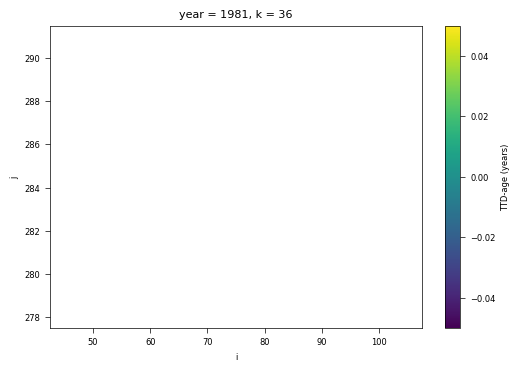

In [18]:
ttdage[9, 0].plot()

# Check matfiles

In [25]:
%%time
%%memit -c
# ca. 3 min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# # Check matfiles')
print('################################')

ocean_name_list = ['atlantic', 'pacific', 'indian', 'southern']

latbnds_dict = {
    'atlantic': [(-60, -50), (-50, -40), (-40, -30), (-30, -20), (-20, -10), (-10, 0), \
                 (0, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 80)], 
    'pacific': [(-60, -50), (-50, -40), (-40, -30), (-30, -20), (-20, -10), (-10, 0), \
                 (0, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 60)], 
    'indian': [(-60, -50), (-50, -40), (-40, -30), (-30, -20), (-20, -10), (-10, 0), \
               (0, 30)],
    'southern': [(-80, -70), (-70, -65), (-65, -60), (-60, -50)]
}

matfile_ocean_name_dict = {
    'atlantic': 'ATL', 
    'pacific' : 'PAC', 
    'indian'  : 'IND', 
    'southern': 'SO'
}

#__________________
# New dictionnay
new_keys = {
    'Year': 'year (years)', 
    'CFC12': 'cfc12 (umol kg-1)', 
    'Theta': 'thetao (Celsius)', 
    'Salinity': 'so (PSU)', 
    'mageF12': 'TTD-age (years)'
}

for ocean_name in ocean_name_list: 
    print('\n----------------------')
    print(f'{ocean_name.capitalize()}')
    print('----------------------\n')
    for (latmin, latmax) in latbnds_dict[ocean_name]: 

        if latmin>=0: lll1=f'{latmin}N'
        else: lll1=f'{-latmin}S'
        if latmax>=0: lll2=f'{latmax}N'
        else: lll2=f'{-latmax}S'
        lat_range = f'{lll1}-{lll2}'

        print(f'    {lat_range}...')

        #__________________
        # Load original dictionnary
        orig_dict = {}
        fdir = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/25-10-11-extract-noresm-outputs-for-TTD/'
        fname = f'NorESM2-LM_outputs_for_TTD_{ocean_name}_{lat_range}_extended_with_dimensions.txt'
        print(f'        >>> original: {fname}')
        # Read the file into a DataFrame
        df = pd.read_csv(fdir+fname, sep='\t')
        zw = df.to_dict(orient='list')
        for kkk, vvv in zw.items(): 
            if kkk=='cfc12 (mol m-3)': orig_dict[kkk.replace('(mol m-3)', '(umol m-3)')] = np.array(vvv)*1e9
            else: orig_dict[kkk] = np.array(vvv)
        #

        #__________________
        # Load matfile
        new_dict = {}
        matfile_ocean_name = matfile_ocean_name_dict[ocean_name]
        lll = [np.abs(latmin), np.abs(latmax)]
        matfile_lat_range = f'{np.min(lll)}{np.max(lll)}{lat_range[-1]}'
        if lat_range=='10S-0N': matfile_lat_range = '010S'
        fdir = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/TTD-age-NorESM2-LM/'
        fname = f'{matfile_ocean_name}_TTD_{matfile_lat_range}_CFC12.mat'
        print(f'        >>> new: {fname}')
        # Load the .mat file
        matfile = scipy.io.loadmat(fdir+fname)

        for kkk, vvv in new_keys.items(): 
            new_dict[vvv] = np.array(matfile[kkk].squeeze())
        #

        #__________________
        # Check alignment of data between new and original
        check_list = ['thetao (Celsius)', 'so (PSU)']
        for check in check_list: 
            zworig = orig_dict[check]
            zwnew = new_dict[check]
            if zworig.shape==zwnew.shape: 
                if not ((zworig == zwnew).all()): 
                    print(f'        !!! WARNING !!! {check} is NOT aligned')
                else: print(f'        GOOD! The new and original {check} are aligned')
            else: 
                print(f'        !!! WARNING !!! {check} has not the right shape: original={zworig.shape}, new={zwnew.shape}')
            #
        #
    #
#


print('\n################################')
print('Done: '+str(datetime.datetime.now()))
print('################################')
print('################################')

################################
################################
2025-12-09 10:53:27.590618
# # Check matfiles
################################

----------------------
Atlantic
----------------------

    60S-50S...
        >>> original: NorESM2-LM_outputs_for_TTD_atlantic_60S-50S_extended_with_dimensions.txt
        >>> new: ATL_TTD_5060S_CFC12.mat
        GOOD! The new and original thetao (Celsius) are aligned
        GOOD! The new and original so (PSU) are aligned
    50S-40S...
        >>> original: NorESM2-LM_outputs_for_TTD_atlantic_50S-40S_extended_with_dimensions.txt
        >>> new: ATL_TTD_4050S_CFC12.mat
        GOOD! The new and original thetao (Celsius) are aligned
        GOOD! The new and original so (PSU) are aligned
    40S-30S...
        >>> original: NorESM2-LM_outputs_for_TTD_atlantic_40S-30S_extended_with_dimensions.txt
        >>> new: ATL_TTD_3040S_CFC12.mat
        GOOD! The new and original thetao (Celsius) are aligned
        GOOD! The new and original so (PS

# Combine matfiles

In [11]:
%%time
%%memit -c
# ca. 3 min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Combine matfiles')
print('################################')

ocean_name_list = ['atlantic', 'pacific', 'indian', 'southern']

latbnds_dict = {
    'atlantic': [(-60, -50), (-50, -40), (-40, -30), (-30, -20), (-20, -10), (-10, 0), \
                 (0, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 60), (60, 80)], 
    'pacific': [(-60, -50), (-50, -40), (-40, -30), (-30, -20), (-20, -10), (-10, 0), \
                 (0, 10), (10, 20), (20, 30), (30, 40), (40, 50), (50, 60)], 
    'indian': [(-60, -50), (-50, -40), (-40, -30), (-30, -20), (-20, -10), (-10, 0), \
               (0, 30)],
    'southern': [(-80, -70), (-70, -65), (-65, -60), (-60, -50)]
}

matfile_ocean_name_dict = {
    'atlantic': 'ATL', 
    'pacific' : 'PAC', 
    'indian'  : 'IND', 
    'southern': 'SO'
}

#---------------------
# Initialize dictionnaries
#---------------------

print('Initialize dictionnaries...')

(latmin, latmax) = latbnds_dict[ocean_name_list[0]][0]
if latmin>=0: lll1=f'{latmin}N'
else: lll1=f'{-latmin}S'
if latmax>=0: lll2=f'{latmax}N'
else: lll2=f'{-latmax}S'
lat_range = f'{lll1}-{lll2}'

#__________________
# Original dictionnary
fdir = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/25-10-11-extract-noresm-outputs-for-TTD/'
fname = f'NorESM2-LM_outputs_for_TTD_{ocean_name_list[0]}_{lat_range}_extended_with_dimensions.txt'
# Read the file into a DataFrame
df = pd.read_csv(fdir+fname, sep='\t')
zw = df.to_dict(orient='list')
orig_dict = {}
for kkk, vvv in zw.items(): 
    if kkk=='cfc12 (mol m-3)': orig_dict[kkk.replace('(mol m-3)', '(umol m-3)')] = []
    else: orig_dict[kkk] = np.array([])
#

#__________________
# New dictionnay
new_keys = {
    'Year': 'year (years)', 
    'CFC12': 'cfc12 (umol kg-1)', 
    'Theta': 'thetao (Celsius)', 
    'Salinity': 'so (PSU)', 
    'mageF12': 'TTD-age (years)', 
    'ageF12': 'direct-age (years)'
}
new_dict = {}
for kkk, vvv in new_keys.items(): 
    new_dict[vvv] = np.array([])
#

#---------------------
# Load data
#---------------------

print('Load data...')
for ocean_name in ocean_name_list: 
    
    print(f'    {ocean_name.capitalize()}...')
    
    for (latmin, latmax) in latbnds_dict[ocean_name]: 

        if latmin>=0: lll1=f'{latmin}N'
        else: lll1=f'{-latmin}S'
        if latmax>=0: lll2=f'{latmax}N'
        else: lll2=f'{-latmax}S'
        lat_range = f'{lll1}-{lll2}'

        print(f'        {lat_range}...')

        #__________________
        # Load original dictionnary

        fdir = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/25-10-11-extract-noresm-outputs-for-TTD/'
        fname = f'NorESM2-LM_outputs_for_TTD_{ocean_name}_{lat_range}_extended_with_dimensions.txt'
        print(f'            original: {fname}')
        # Read the file into a DataFrame
        df = pd.read_csv(fdir+fname, sep='\t')
        zw = df.to_dict(orient='list')
        for kkk, vvv in orig_dict.items(): 
            if kkk=='cfc12 (umol m-3)': orig_dict[kkk] = np.concatenate( (vvv, np.array(zw[kkk.replace('umol', 'mol')])*1e6) )
            else: orig_dict[kkk] = np.concatenate( (vvv, np.array(zw[kkk])) )
        #

        #__________________
        # Load matfile

        matfile_ocean_name = matfile_ocean_name_dict[ocean_name]
        lll = [np.abs(latmin), np.abs(latmax)]
        matfile_lat_range = f'{np.min(lll)}{np.max(lll)}{lat_range[-1]}'
        if lat_range=='10S-0N': matfile_lat_range = '010S'
        fdir = '/mnt/reef-ns1002k/daco/MY_JUPYTER_NOTEBOOKS/OceanICU/TTD-age-NorESM2-LM/'
        fname = f'{matfile_ocean_name}_TTD_{matfile_lat_range}_CFC12.mat'
        print(f'            matfile: {fname}')
        # Load the .mat file
        matfile = scipy.io.loadmat(fdir+fname)
        for kkk, vvv in new_keys.items(): 
            new_dict[vvv] = np.concatenate( (new_dict[vvv], np.array(matfile[kkk]).squeeze()) )
        #
    #
#

#---------------------
# Check alignment of data between new and original
#---------------------

print('Check alignment of data between new and original...')
    
check_list = ['thetao (Celsius)', 'so (PSU)']
boolean_check = True
for check in check_list: 
    zworig = orig_dict[check]
    zwnew = new_dict[check]
    if zworig.shape==zwnew.shape: 
        if not ((zworig == zwnew).all()): 
            zwdiff = np.abs((zwnew - zworig)/zworig)*100
            if np.nanmax(zwdiff) > 1e-5: 
                print(f'!!! WARNING: {check} has differences > 0.00001%')
                boolean_check=False
            else: print(f'!!! OKish: {check} has differences <= 0.00001%')
        #
    else: 
        print(f'!!! WARNING: {check} has not the righ shape')
        boolean_check=False
    #
#
if boolean_check: print('GOOD! The new and original data are aligned')
else: print('!!!!!!!! ERROR: the new and original data are NOT ALIGNED')

#---------------------
# Put back in dataarray
#---------------------

print('Put back in dataarray...')

#______________________
# Get theato at specific year to get the shape of the new dataarray
vesm = 'NorESM2-LM'
simu='historical'
var = 'thetao'
fname = dirshared+vesm+"_"+simu+"_"+var+"_2000.nc"
zwds = xr.open_dataset(fname, **kwopends) 
zwda_thetao = zwds[var]


#______________________
# TTD age: mageF12

print('    TTD age: mageF12...')

nyear = np.unique(orig_dict['year (years)']).shape[0]
ndep, nlat, nlon = zwda_thetao.shape[1:]
shape = (nyear, ndep, nlat, nlon)
zwnp = np.full(shape, np.nan)

ttdage_values = new_dict['TTD-age (years)']
ttdage_t = np.array(orig_dict['year (years)'], dtype=int)
ttdage_t = ttdage_t - np.nanmin(ttdage_t)
ttdage_k = np.array(orig_dict['k ()'], dtype=int)
ttdage_j = np.array(orig_dict['j ()'], dtype=int)
ttdage_i = np.array(orig_dict['i ()'], dtype=int)

# Ensure all indices are of equal length
if not (ttdage_t.size == ttdage_k.size == ttdage_j.size == ttdage_i.size == ttdage_values.size):
    raise ValueError("Index arrays and values array must have the same length.")

# Verify the indices are within bounds
if not (np.all(ttdage_t < zwnp.shape[0]) and
        np.all(ttdage_k < zwnp.shape[1]) and
        np.all(ttdage_j < zwnp.shape[2]) and
        np.all(ttdage_i < zwnp.shape[3])):
    raise IndexError("Some indices are out of bounds and cannot be assigned.")
#

zwnp[ttdage_t, ttdage_k, ttdage_j, ttdage_i] = ttdage_values

zwda_ttd_age = xr.DataArray(
    data = zwnp,
    dims = ["year", "k", "j", "i"],
    coords = {
        "year":("year", np.unique(orig_dict['year (years)'])), 
        "depth": ("k", zwda_thetao.depth.values),
        "latitude": (["j", "i"], zwda_thetao.latitude.values),
        "longitude": (["j", "i"], zwda_thetao.longitude.values)
    },
    name='mageF12',
    attrs = dict(
        units = 'years', 
    )
)

# Fix to remove year from 1972 to 1981
zwda_ttd_age = zwda_ttd_age[10:]

#______________________
# Direct age: ageF12

print('    Direct age: ageF12')
nyear = np.unique(orig_dict['year (years)']).shape[0]
ndep, nlat, nlon = zwda_thetao.shape[1:]
shape = (nyear, ndep, nlat, nlon)
zwnp = np.full(shape, np.nan)

directage_values = new_dict['direct-age (years)']
directage_t = np.array(orig_dict['year (years)'], dtype=int)
directage_t = directage_t - np.nanmin(directage_t)
directage_k = np.array(orig_dict['k ()'], dtype=int)
directage_j = np.array(orig_dict['j ()'], dtype=int)
directage_i = np.array(orig_dict['i ()'], dtype=int)


zwnp[ttdage_t, ttdage_k, ttdage_j, ttdage_i] = ttdage_values

# Ensure all indices are of equal length
if not (directage_t.size == directage_k.size == directage_j.size == directage_i.size == directage_values.size):
    raise ValueError("Index arrays and values array must have the same length.")

# Verify the indices are within bounds
if not (np.all(directage_t < zwnp.shape[0]) and
        np.all(directage_k < zwnp.shape[1]) and
        np.all(directage_j < zwnp.shape[2]) and
        np.all(directage_i < zwnp.shape[3])):
    raise IndexError("Some indices are out of bounds and cannot be assigned.")
#

zwnp[directage_t, directage_k, directage_j, directage_i] = directage_values

zwda_direct_age = xr.DataArray(
    data = zwnp,
    dims = ["year", "k", "j", "i"],
    coords = {
        "year":("year", np.unique(orig_dict['year (years)'])), 
        "depth": ("k", zwda_thetao.depth.values),
        "latitude": (["j", "i"], zwda_thetao.latitude.values),
        "longitude": (["j", "i"], zwda_thetao.longitude.values)
    },
    name='ageF12',
    attrs = dict(
        units = 'years', 
    )
)

# Fix to remove year from 1972 to 1981
zwda_direct_age = zwda_direct_age[10:]


#________________
# Save in netcdf
print('Save in netcdf...')

vesm = 'NorESM2-LM'
simu='historical'
var = 'mageF12'
ymin = int(np.min(zwda_ttd_age.year))
ymax = int(np.max(zwda_ttd_age.year))
ncname = netcdfdir + f'{vesm}_{simu}_{var}_{ymin:04}-{ymax:04}.nc'
zwda_ttd_age.to_netcdf(ncname)
print('File saved: %s'%ncname)

vesm = 'NorESM2-LM'
simu='historical'
var = 'ageF12'
ymin = int(np.min(zwda_direct_age.year))
ymax = int(np.max(zwda_direct_age.year))
ncname = netcdfdir + f'{vesm}_{simu}_{var}_{ymin:04}-{ymax:04}.nc'
zwda_direct_age.to_netcdf(ncname)
print('File saved: %s'%ncname)




print('################################')
print('Done: '+str(datetime.datetime.now()))
print('################################')
print('################################')

################################
################################
2025-12-11 16:34:20.575452
# Combine matfiles
################################
Initialize dictionnaries...
Load data...
    Atlantic...
        60S-50S...
            original: NorESM2-LM_outputs_for_TTD_atlantic_60S-50S_extended_with_dimensions.txt
            matfile: ATL_TTD_5060S_CFC12.mat
        50S-40S...
            original: NorESM2-LM_outputs_for_TTD_atlantic_50S-40S_extended_with_dimensions.txt
            matfile: ATL_TTD_4050S_CFC12.mat
        40S-30S...
            original: NorESM2-LM_outputs_for_TTD_atlantic_40S-30S_extended_with_dimensions.txt
            matfile: ATL_TTD_3040S_CFC12.mat
        30S-20S...
            original: NorESM2-LM_outputs_for_TTD_atlantic_30S-20S_extended_with_dimensions.txt
            matfile: ATL_TTD_2030S_CFC12.mat
        20S-10S...
            original: NorESM2-LM_outputs_for_TTD_atlantic_20S-10S_extended_with_dimensions.txt
            matfile: ATL_TTD_1020S_CFC12.mat
   

# Plot agessc, mageF12, ageF12

In [28]:
%%time
%%memit -c
# ca. 5min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Plot agessc, mageF12, ageF12')
print('################################')

vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2013)

var = 'mageF12'
fname = netcdfdir + f'{vesm}_{simu}_{var}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_mage12 = zwds[var].sel(year=tslice) # in years
zwda_mage12 = zwda_mage12.where(np.isfinite(zwda_mage12))

var = 'ageF12'
fname = netcdfdir + f'{vesm}_{simu}_{var}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_age12 = zwds[var].sel(year=tslice) # in years
# zwda_age12 = zwda_age12.where(np.isfinite(zwda_mage12))

var = 'agessc'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwda_agessc = zwds[var].sel(year=tslice) # in years
# zwda_agessc = zwda_agessc.where(np.isfinite(zwda_mage12)).load()

refyear = 1600
simu='piControl'
startyear, endyear = int(refyear+tslice.start-1850), int(refyear+tslice.stop-1850)
tslice_ctl = slice(startyear, endyear)
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice_ctl.start), int(tslice_ctl.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwda_agessc_ctl = zwds[var].sel(year=tslice_ctl) # in years
# zwda_agessc_ctl = zwda_agessc_ctl.where(np.isfinite(zwda_mage12).values).load()


mask = np.isfinite(zwda_mage12[0])

zwda_mage12 = zwda_mage12.where(mask).load()
zwda_age12 = zwda_age12.where(mask).load()
zwda_agessc = zwda_agessc.where(mask).load()
zwda_agessc_ctl = zwda_agessc_ctl.where(mask).load()



################################
################################
2025-12-11 16:49:27.604833
# Plot agessc, mageF12, ageF12
################################
peak memory: 65858.16 MiB, increment: 34154.70 MiB
CPU times: user 3.13 s, sys: 2.86 s, total: 6 s
Wall time: 24.8 s


## Distribution of age global ocean, years 1982 to 2013

In [29]:
%%time
%%memit -c

zwda_agessc_flat = zwda_agessc.values.flatten()
zwda_agessc_flat = zwda_agessc_flat[np.isfinite(zwda_agessc_flat)]

zwda_agessc_ctl_flat = zwda_agessc_ctl.values.flatten()
zwda_agessc_ctl_flat = zwda_agessc_ctl_flat[np.isfinite(zwda_agessc_ctl_flat)]

zwda_age12_flat = zwda_age12.values.flatten()
zwda_age12_flat = zwda_age12_flat[np.isfinite(zwda_age12_flat)]

zwda_mage12_flat = zwda_mage12.values.flatten()
zwda_mage12_flat = zwda_mage12_flat[np.isfinite(zwda_mage12_flat)]


peak memory: 66150.29 MiB, increment: 34502.23 MiB
CPU times: user 1.39 s, sys: 632 ms, total: 2.02 s
Wall time: 2.17 s


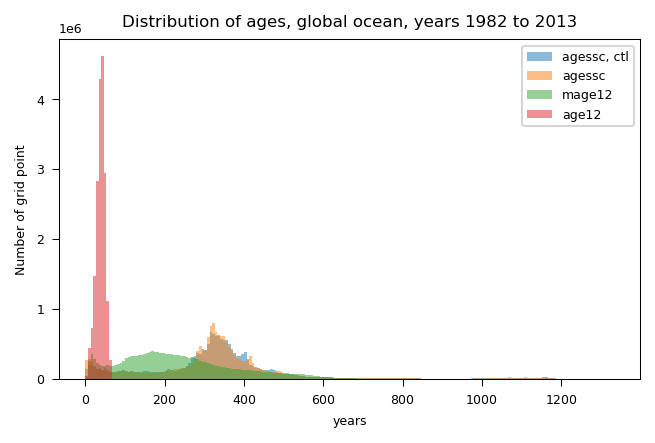

In [30]:
zwmax = np.max(np.concatenate([zwda_age12_flat, zwda_agessc_flat, zwda_agessc_ctl_flat, zwda_mage12_flat]))
zwmin = np.min(np.concatenate([zwda_age12_flat, zwda_agessc_flat, zwda_agessc_ctl_flat, zwda_mage12_flat]))
bins_range = [zwmin, zwmax]

kwhist = dict(range=bins_range, bins=200, alpha=.5)

plt.figure(figsize=(5, 3))
_, _, _ = plt.hist(zwda_agessc_ctl_flat, label='agessc, ctl', **kwhist)
_, _, _ = plt.hist(zwda_agessc_flat, label='agessc', **kwhist)
_, _, _ = plt.hist(zwda_mage12_flat, label='mage12', **kwhist)
_, _, _ = plt.hist(zwda_age12_flat , label='age12', **kwhist)
plt.xlabel('years')
plt.ylabel('Number of grid point')
plt.title('Distribution of ages, global ocean, years 1982 to 2013')
plt.legend()

## Distribution of age global ocean, 5 first and last years

In [31]:
%%time
%%memit -c

zwda_agessc_flat1 = zwda_agessc[:5].values.flatten()
zwda_agessc_flat1 = zwda_agessc_flat1[np.isfinite(zwda_agessc_flat1)]

zwda_agessc_ctl_flat1 = zwda_agessc_ctl[:5].values.flatten()
zwda_agessc_ctl_flat1 = zwda_agessc_ctl_flat1[np.isfinite(zwda_agessc_ctl_flat1)]

zwda_mage12_flat1 = zwda_mage12[:5].values.flatten()
zwda_mage12_flat1 = zwda_mage12_flat1[np.isfinite(zwda_mage12_flat1)]

zwda_age12_flat1 = zwda_age12[:5].values.flatten()
zwda_age12_flat1 = zwda_age12_flat1[np.isfinite(zwda_age12_flat1)]

zwda_agessc_flat2 = zwda_agessc[-5:].values.flatten()
zwda_agessc_flat2 = zwda_agessc_flat2[np.isfinite(zwda_agessc_flat2)]

zwda_agessc_ctl_flat2 = zwda_agessc_ctl[-5:].values.flatten()
zwda_agessc_ctl_flat2 = zwda_agessc_ctl_flat2[np.isfinite(zwda_agessc_ctl_flat2)]

zwda_mage12_flat2 = zwda_mage12[-5:].values.flatten()
zwda_mage12_flat2 = zwda_mage12_flat2[np.isfinite(zwda_mage12_flat2)]

zwda_age12_flat2 = zwda_age12[-5:].values.flatten()
zwda_age12_flat2 = zwda_age12_flat2[np.isfinite(zwda_age12_flat2)]


peak memory: 64422.28 MiB, increment: 32341.18 MiB
CPU times: user 637 ms, sys: 348 ms, total: 985 ms
Wall time: 1.11 s


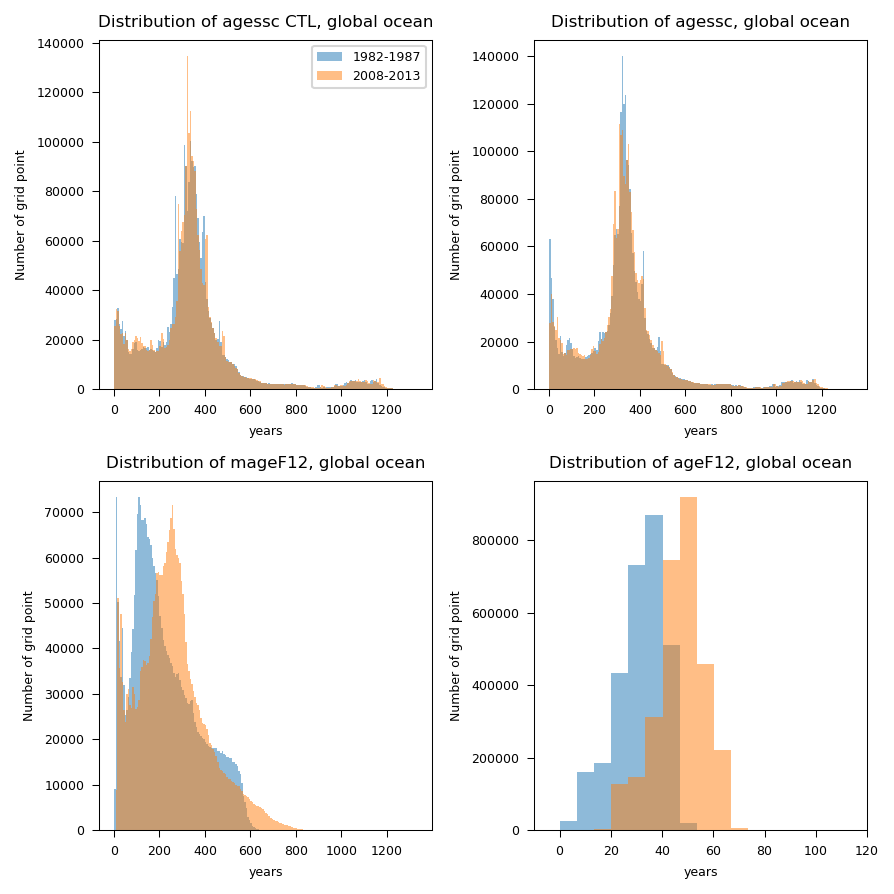

In [32]:
zwmax = np.max(np.concatenate([zwda_agessc_flat1, zwda_agessc_ctl_flat1, zwda_mage12_flat1, zwda_age12_flat1, zwda_agessc_flat2, zwda_agessc_ctl_flat2, zwda_mage12_flat2, zwda_age12_flat2]))
zwmin = np.min(np.concatenate([zwda_agessc_flat1, zwda_agessc_ctl_flat1, zwda_mage12_flat1, zwda_age12_flat1, zwda_agessc_flat2, zwda_agessc_ctl_flat2, zwda_mage12_flat2, zwda_age12_flat2]))
bins_range = [zwmin, zwmax]

kwhist = dict(range=bins_range, bins=200, alpha=.5)

plt.figure(figsize=(6, 6))

plt.subplot(221)
_, _, _ = plt.hist(zwda_agessc_ctl_flat1, label='1982-1987', **kwhist)
_, _, _ = plt.hist(zwda_agessc_ctl_flat2, label='2008-2013', **kwhist)
plt.xlabel('years')
plt.ylabel('Number of grid point')
plt.title('Distribution of agessc CTL, global ocean')
plt.legend()

plt.subplot(222)
_, _, _ = plt.hist(zwda_agessc_flat1, label='1982-1987', **kwhist)
_, _, _ = plt.hist(zwda_agessc_flat2, label='2008-2013', **kwhist)
plt.xlabel('years')
plt.ylabel('Number of grid point')
plt.title('Distribution of agessc, global ocean')

plt.subplot(223)
_, _, _ = plt.hist(zwda_mage12_flat1, label='1982-1987', **kwhist)
_, _, _ = plt.hist(zwda_mage12_flat2, label='2008-2013', **kwhist)
plt.xlabel('years')
plt.ylabel('Number of grid point')
plt.title('Distribution of mageF12, global ocean')

plt.subplot(224)
_, _, _ = plt.hist(zwda_age12_flat1, label='1982-1987', **kwhist)
_, _, _ = plt.hist(zwda_age12_flat2, label='2008-2013', **kwhist)
plt.xlabel('years')
plt.ylabel('Number of grid point')
plt.title('Distribution of ageF12, global ocean')
plt.xlim(-10, 120)

plt.tight_layout()



## Maps

Text(0.5, 1.0, 'mageF12, 2000m, 1982')

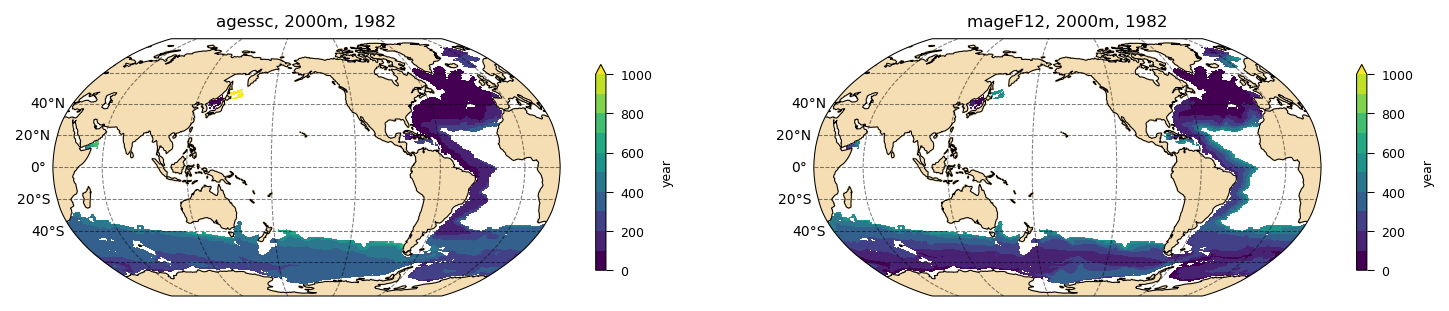

In [111]:
yyy = 0
kkk = 50

kwpcm = dict(vmin=0, vmax=1000, zwcbExtend='max', zwcbLabel='year')
plt.figure(figsize=(12, 4))
zwccrsproj = ccrs.Robinson(central_longitude=-155)

ax = plt.subplot(121, projection=zwccrsproj)
data2plot = zwda_agessc.isel(year=yyy, k=kkk)
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, {data2plot.year.values:.0f}')

ax = plt.subplot(122, projection=zwccrsproj)
data2plot = zwda_mage12.isel(year=yyy, k=kkk)
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, {data2plot.year.values:.0f}')





## Maps first and alst five years

Text(0.5, 1.0, 'mageF12, 3000m, difference')

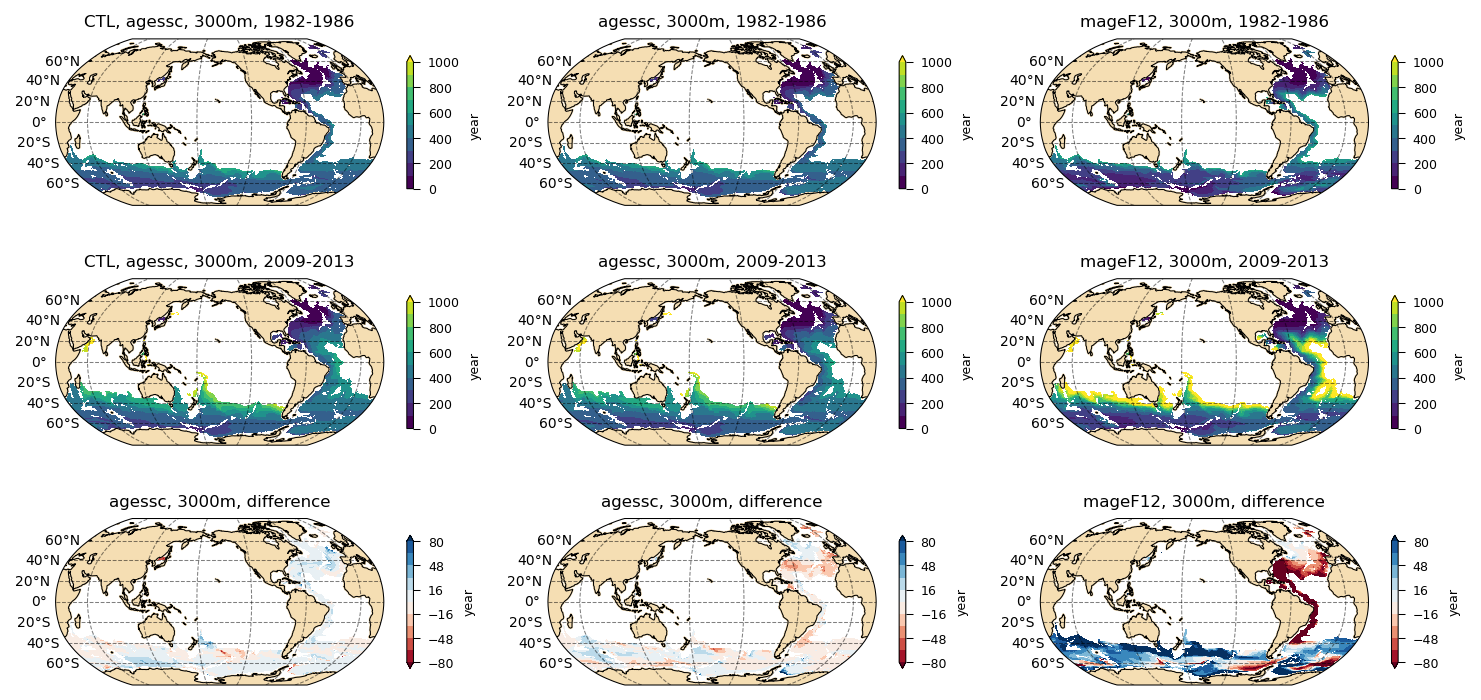

In [190]:
yyy = slice(5)
kkk = 54

kwpcm = dict(vmin=0, vmax=1000, zwcbExtend='max', zwcbLabel='year')
plt.figure(figsize=(12, 6))
zwccrsproj = ccrs.Robinson(central_longitude=-155)

ax = plt.subplot(331, projection=zwccrsproj)
data2plot = zwda_agessc_ctl.isel(year=yyy, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'CTL, {data2plot.name}, {data2plot.depth.values:.0f}m, 1982-1986')

ax = plt.subplot(332, projection=zwccrsproj)
data2plot = zwda_agessc.isel(year=yyy, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, 1982-1986')

ax = plt.subplot(333, projection=zwccrsproj)
data2plot = zwda_mage12.isel(year=yyy, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, 1982-1986')

yyy = slice(None, -5, -1)

ax = plt.subplot(334, projection=zwccrsproj)
data2plot = zwda_agessc_ctl.isel(year=yyy, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'CTL, {data2plot.name}, {data2plot.depth.values:.0f}m, 2009-2013')

ax = plt.subplot(335, projection=zwccrsproj)
data2plot = zwda_agessc.isel(year=yyy, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, 2009-2013')

ax = plt.subplot(336, projection=zwccrsproj)
data2plot = zwda_mage12.isel(year=yyy, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, 2009-2013')

yyy1 = slice(5)
yyy2 = slice(None, -5, -1)
kwpcm = dict(vmin=-80, vmax=80, zwcbExtend='both', zwcbLabel='year')

ax = plt.subplot(337, projection=zwccrsproj)
data2plot = zwda_agessc_ctl.isel(year=yyy2, k=kkk).mean(dim='year') - zwda_agessc_ctl.isel(year=yyy1, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, difference')

ax = plt.subplot(338, projection=zwccrsproj)
data2plot = zwda_agessc.isel(year=yyy2, k=kkk).mean(dim='year') - zwda_agessc.isel(year=yyy1, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, difference')

ax = plt.subplot(339, projection=zwccrsproj)
data2plot = zwda_mage12.isel(year=yyy2, k=kkk).mean(dim='year') - zwda_mage12.isel(year=yyy1, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, difference')





## Plot time series

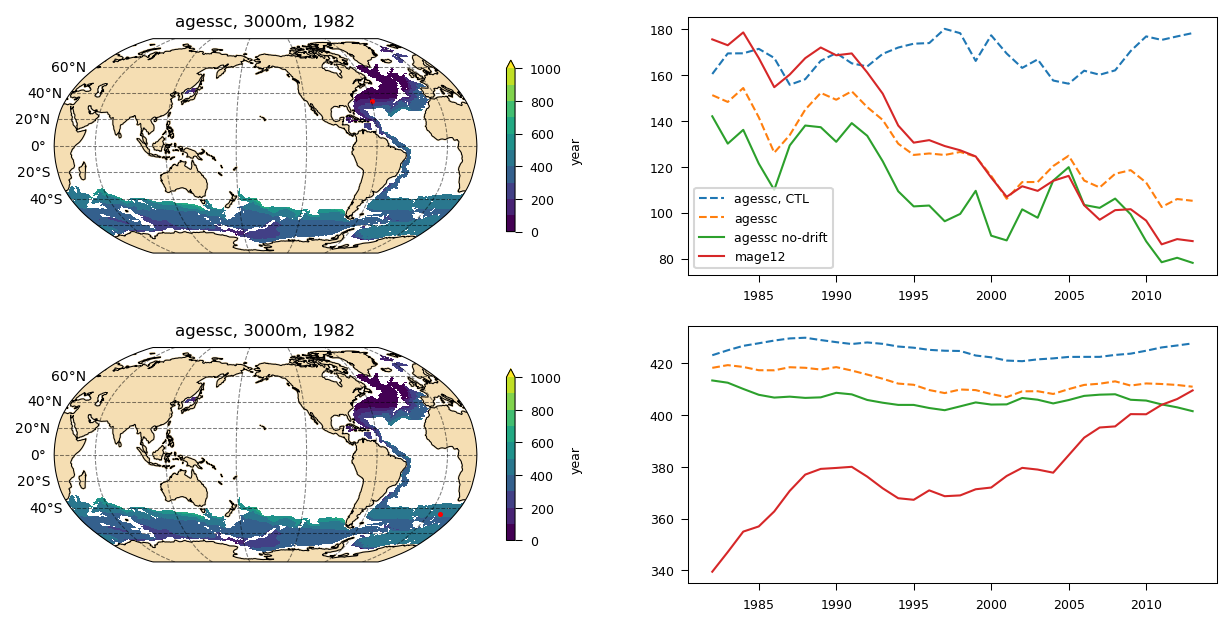

In [200]:

kwpcm = dict(vmin=0, vmax=1000, zwcbExtend='max', zwcbLabel='year')
plt.figure(figsize=(10, 5))
zwccrsproj = ccrs.Robinson(central_longitude=-155)

kkk = 54
jjj = 270
iii = 50
ax = plt.subplot(221, projection=zwccrsproj)
data2plot = zwda_agessc.isel(year=0, k=kkk)
map_whole_globe(data2plot, zwax=ax, **kwpcm)
X = data2plot.isel(j=jjj, i=iii).longitude.values
Y = data2plot.isel(j=jjj, i=iii).latitude.values
plt.scatter(X, Y, transform = ccrs.PlateCarree(), c='r', s=2)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, {data2plot.year.values:.0f}')

ax = plt.subplot(222)
data2plot = zwda_agessc_ctl.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values-refyear+1850, data2plot.values, label='agessc, CTL', ls='--')
data2plot = zwda_agessc.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='agessc', ls='--')

data2plot = zwda_agessc.isel(k=kkk, j=jjj, i=iii) - zwda_agessc_ctl.isel(k=kkk, j=jjj, i=iii).values + zwda_agessc.isel(k=kkk, j=jjj, i=iii, year=0).values
ax.plot(data2plot.year.values, data2plot.values, label='agessc no-drift')
data2plot = zwda_mage12.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='mage12')

ax.legend()


kkk = 54
jjj = 90
iii = 120
ax = plt.subplot(223, projection=zwccrsproj)
data2plot = zwda_agessc.isel(year=0, k=kkk)
map_whole_globe(data2plot, zwax=ax, **kwpcm)
X = data2plot.isel(j=jjj, i=iii).longitude.values
Y = data2plot.isel(j=jjj, i=iii).latitude.values
plt.scatter(X, Y, transform = ccrs.PlateCarree(), c='r', s=2)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m, {data2plot.year.values:.0f}')

ax = plt.subplot(224)
data2plot = zwda_agessc_ctl.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values-refyear+1850, data2plot.values, label='agessc, CTL', ls='--')
data2plot = zwda_agessc.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='agessc', ls='--')

data2plot = zwda_agessc.isel(k=kkk, j=jjj, i=iii) - zwda_agessc_ctl.isel(k=kkk, j=jjj, i=iii).values + zwda_agessc.isel(k=kkk, j=jjj, i=iii, year=0).values
ax.plot(data2plot.year.values, data2plot.values, label='agessc no-drift')
data2plot = zwda_mage12.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='mage12')



# Access drift in ocean circulation

## def shorten_fname_list(fname_list, startyear, endyear):

In [19]:
def shorten_fname_list(fname_list, startyear, endyear):
    fname_list.sort()
    new_fname_list = []
    for fname in fname_list: 
        year1_of_fname = int(fname.split('/')[-1].split('_')[-1].split('-')[0][:4])
        year2_of_fname = int(fname.split('/')[-1].split('_')[-1].split('-')[1][:4])
        startyear_in_between = ((startyear>=year1_of_fname) & (startyear<=year2_of_fname))
        endyear_in_between   = ((endyear>=year1_of_fname) & (endyear<=year2_of_fname))
        year1_in_between = ((year1_of_fname>=startyear) & (year1_of_fname<=endyear))
        year2_in_between = ((year2_of_fname>=startyear) & (year2_of_fname<=endyear))
        if startyear_in_between | endyear_in_between | year1_in_between | year2_in_between: 
            if not (fname in new_fname_list): 
                new_fname_list.append(fname)
        #
    #
    #
    # if len(new_fname_list)==0: 
    #     zwmax = int(fname_list[-1][-9:-5])
    #     zwmin = zwmax-99
    #     for fname in fname_list: 
    #         year1_of_fname = fname.split('/')[-1].split('_')[-1].split('-')[0][:4]
    #         for search in np.arange(zwmin, zwmax): 
    #             if '%04d'%search==year1_of_fname:
    #                 if not (fname in new_fname_list): new_fname_list.append(fname)
    #                 #
    #             #
    #         #
    #     #
    # #
    if len(new_fname_list)==0: new_fname_list=fname_list
    return new_fname_list
#


## Check data avaibility

In [20]:
%%time
%%memit -c
print(datetime.datetime.now())
print('# Compute yearly mean for piControl')
print('## Check data avaibility')

refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600
}

simu='piControl'
version

esm  = 'NorESM2-LM' 

var = 'msftmz'

# startyear, endyear = refyear_dict[esm], refyear_dict[esm]+164
startyear, endyear = refyear_dict[esm], refyear_dict[esm]+165+84

# Load data
fname_list = get_esgf_dataset_filepaths(var, esm, simu, 
                                        diresgf='/mnt/reef-ns1002k-ns9034k/', 
                                        version='v20210118', 
                                        variant='r1i1p1f1', grid='grz')

new_fname_list = shorten_fname_list(fname_list, startyear, endyear)
 

zwds = xr.open_mfdataset(new_fname_list, **kwopenmfds)
ymin = int(np.min(zwds['time.year']))
ymax = int(np.max(zwds['time.year']))
tstep = zwds[var].shape[0]
good1 = tstep/12 == ymax-ymin+1
good2 = (startyear>=ymin) & (endyear<=ymax)
if good1 & good2: 
    print('%s GOOD, time period complete and match target'%esm)
    print(f'{ymin} to {ymax}, {tstep/12} years ({tstep} months)')
elif good1 and (not good2): 
    print('!!! WARNING !!! %s, time period complete BUT do not match target'%esm)
    print(f'{ymin} to {ymax}, {tstep/12} years ({tstep} months), \
    here is the list of the files:')
    for fname in new_fname_list: print(fname)
else: 
    print('!!! WARNING !!! %s, some years are missing, \
    here is the list of available files: '%esm)
    for fname in new_fname_list: print(fname)
#
print('------------')
print('')






2025-12-03 17:14:01.479719
# Compute yearly mean for piControl
## Check data avaibility


OSError: no files to open

## Compute

In [39]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Compute yearly mean for piControl')
print('## Compute')

refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600
}

simu='piControl'
esm  = 'NorESM2-LM' 
var = 'msftmz'

# startyear, endyear = refyear_dict[esm], refyear_dict[esm]+165+84
# startyear, endyear = refyear_dict[esm], refyear_dict[esm]+30
startyear, endyear = refyear_dict[esm]+165+84-30, refyear_dict[esm]+165+84

# Load data
fname_list = get_esgf_dataset_filepaths(var, esm, simu, 
                                        diresgf='/mnt/reef-ns1002k-ns9034k/', 
                                        version='v20210118', 
                                        variant='r1i1p1f1', grid='grz')
new_fname_list = shorten_fname_list(fname_list, startyear, endyear)
zwds = xr.open_mfdataset(new_fname_list, **kwopenmfds)

zwds2 = zwds[var].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)

# save for later
zwds_attrs=zwds.attrs
year_list = ['%04d' %yyy for yyy in np.arange(startyear, endyear+.5)]
del zwds
gc.collect()

# Loop on years
for year in year_list: 
    print(f'For year {year}...')
    zwda = zwds2.sel(time=year)[var].load()
    zwda_tavg = zwda.groupby('time.year').mean(dim='time')
    # Clean
    del zwda
    gc.collect()
    # create dataset
    zwda_ds = zwda_tavg.to_dataset() 
    zwda_ds.attrs = zwds_attrs
    # Save in netcdf
    ncname = netcdfdir+esm+'_'+simu+'_'+var+'_'+year+'.nc'
    zwda_ds.to_netcdf(ncname)
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

2025-11-28 13:37:42.811923
# Compute yearly mean for piControl
## Compute
For year 1819...
For year 1820...
For year 1821...
For year 1822...
For year 1823...
For year 1824...
For year 1825...
For year 1826...
For year 1827...
For year 1828...
For year 1829...
For year 1830...
For year 1831...
For year 1832...
For year 1833...
For year 1834...
For year 1835...
For year 1836...
For year 1837...
For year 1838...
For year 1839...
For year 1840...
For year 1841...
For year 1842...
For year 1843...
For year 1844...
For year 1845...
For year 1846...
For year 1847...
For year 1848...
For year 1849...
Done with msftmz
peak memory: 15070.04 MiB, increment: 10772.23 MiB
CPU times: user 5.43 s, sys: 351 ms, total: 5.78 s
Wall time: 9.47 s


## Check data avaibility historical

In [24]:
%%time
%%memit -c
print(datetime.datetime.now())
print('# Compute yearly mean for piControl')
print('## Check data avaibility historical')

refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600
}

simu='historical'
esm  = 'NorESM2-LM' 

var = 'msftmz'

# Load data
fname_list = get_esgf_dataset_filepaths(var, esm, simu, 
                                        diresgf='/mnt/reef-ns1002k-ns9034k/', 
                                        version='v20190815', 
                                        variant='r1i1p1f1', grid='grz')

zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
ymin = int(np.min(zwds['time.year']))
ymax = int(np.max(zwds['time.year']))
tstep = zwds[var].shape[0]
good1 = tstep/12 == ymax-ymin+1
if good1: 
    print('%s GOOD, time period complete and match target'%esm)
    print(f'{ymin} to {ymax}, {tstep/12} years ({tstep} months)')
else: 
    print('!!! WARNING !!! %s, some years are missing, \
    here is the list of available files: '%esm)
    for fname in fname_list: print(fname)
#
print('------------')
print('')






2025-12-03 17:19:09.809258
# Compute yearly mean for piControl
## Check data avaibility historical
NorESM2-LM GOOD, time period complete and match target
1850 to 2014, 165.0 years (1980 months)
------------

peak memory: 15674.42 MiB, increment: 7785.62 MiB
CPU times: user 386 ms, sys: 131 ms, total: 516 ms
Wall time: 2.23 s


## Compute historical

In [27]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Compute yearly mean for piControl')
print('## Compute historical')

simu='historical'
esm  = 'NorESM2-LM' 
var = 'msftmz'
year_list = ['%04d' %yyy for yyy in np.arange(2014-30, 2014.5)]

# Load data
fname_list = get_esgf_dataset_filepaths(var, esm, simu, 
                                        diresgf='/mnt/reef-ns1002k-ns9034k/', 
                                        version='v20190815', 
                                        variant='r1i1p1f1', grid='grz')
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds[var].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)

# save for later
zwds_attrs=zwds.attrs
del zwds
gc.collect()

# Loop on years
for year in year_list: 
    print(f'For year {year}...')
    zwda = zwds2.sel(time=year)[var].load()
    zwda_tavg = zwda.groupby('time.year').mean(dim='time')
    # Clean
    del zwda
    gc.collect()
    # create dataset
    zwda_ds = zwda_tavg.to_dataset() 
    zwda_ds.attrs = zwds_attrs
    # Save in netcdf
    ncname = netcdfdir+esm+'_'+simu+'_'+var+'_'+year+'.nc'
    zwda_ds.to_netcdf(ncname)
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-12-03 17:25:26.311077
################################
# Compute yearly mean for piControl
## Compute historical
For year 1984...
For year 1985...
For year 1986...
For year 1987...
For year 1988...
For year 1989...
For year 1990...
For year 1991...
For year 1992...
For year 1993...
For year 1994...
For year 1995...
For year 1996...
For year 1997...
For year 1998...
For year 1999...
For year 2000...
For year 2001...
For year 2002...
For year 2003...
For year 2004...
For year 2005...
For year 2006...
For year 2007...
For year 2008...
For year 2009...
For year 2010...
For year 2011...
For year 2012...
For year 2013...
For year 2014...
################################
Done:  2025-12-03 17:25:35.565788
################################
################################
peak memory: 15930.41 MiB, increment: 7942.29 MiB
CPU times: user 4.71 s, sys: 197 ms, total: 4.9 s
Wall time: 9.54 s


## Plot MOC 1600-1630, 1819-1849 and diff

In [91]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Compute yearly mean for piControl')
print('## Plot MOC 1600-1630, 1819-1849 and diff')

simu='piControl'
vesm  = 'NorESM2-LM' 
var = 'msftmz'

#________________
# Get data
print('Get data...')    

fname_list = [f"{netcdfdir}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(1600, 1630.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda1 = zwds[var].mean(dim='year').load()

fname_list = [f"{netcdfdir}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(1819, 1849.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda2 = zwds[var].mean(dim='year').load()



################################
################################
2025-11-28 15:13:15.940054
################################
# Compute yearly mean for piControl
## Plot MOC 1600-1630, 1819-1849 and diff
Get data...
peak memory: 8397.11 MiB, increment: 4145.05 MiB
CPU times: user 1.61 s, sys: 254 ms, total: 1.86 s
Wall time: 20.6 s


################################
Done:  2025-11-28 16:53:40.011507
################################
################################


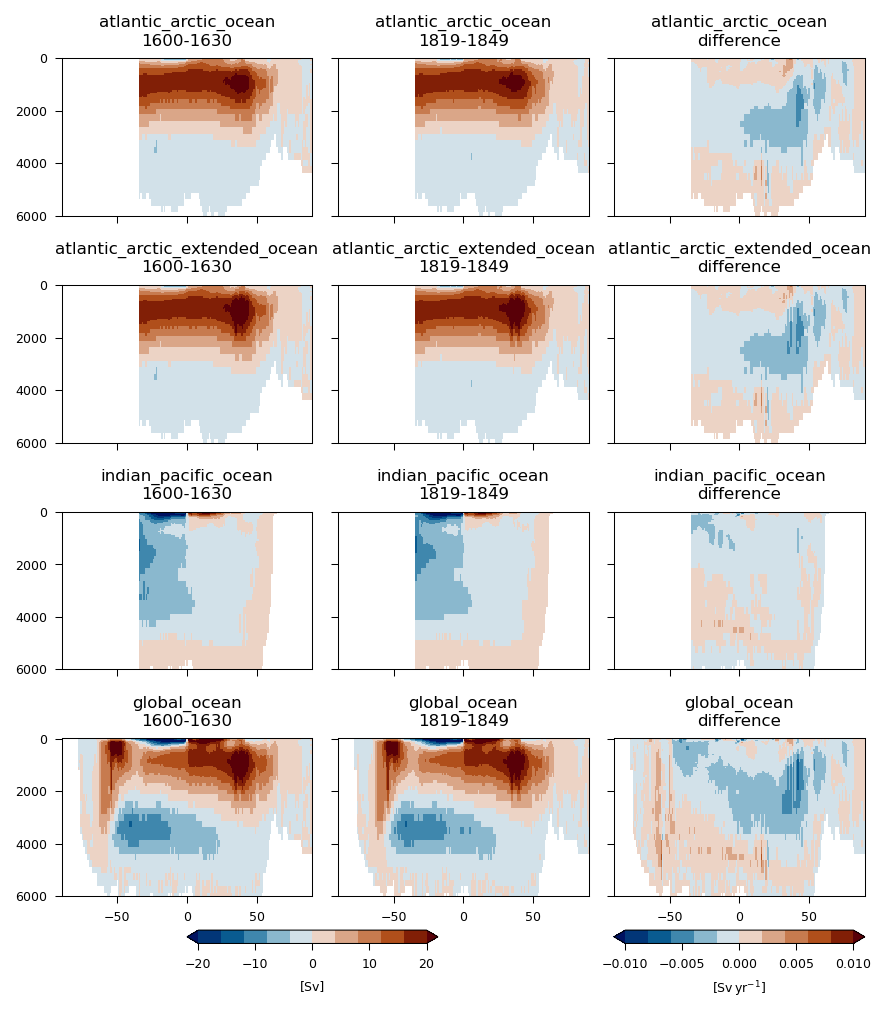

In [147]:
#--------------------
# Figure parameters
#--------------------

row_list = np.arange(zwda1.shape[0])

zfact = 1/1025*1e-6 # kg s-1 to Sv 
units = 'Sv'

#______________
# Sections axis labeling and limits
xlim = (-90, 90)
ylim = (6000, -10)

#______________
# Section cmap
a = cmcrameri.cm.vik
colors = a(np.linspace(0,1,10+2))
newcmap = ListedColormap(colors[1:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[0])
newcmap.set_bad("none")

#______________
# Section pcm kwargs
kwpcm = dict(cmap=newcmap, vmin=-20, vmax=20)
kwpcm_d = dict(cmap=newcmap, vmin=-.01, vmax=.01)

#______________
# panel labeling
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]
# Create a list of double letter combinations (aa, ab, ..., zz)
double_letters = [a + b for a in string.ascii_lowercase for b in string.ascii_lowercase]
extended_alphabet = alphabet + double_letters
extended_alphabet_reverse = extended_alphabet[::-1]

# Pop one now to save a) for the barplot at the top
extended_alphabet_reverse.pop()

#______________
# Set figure
ncol = 3
nrow = len(row_list)
fwidth_cm = 5
fheight_cm = 4
fsize = (fwidth_cm*cm2in*ncol, fheight_cm*cm2in*nrow) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, sharex='col', sharey='row')

#--------------------
# Plot sections
#--------------------

pcm = np.zeros_like(ax)
for irow, vrow in enumerate(row_list): 
    
    data1 = zwda1.isel(basin=vrow)
    data2 = zwda2.isel(basin=vrow)
    
    basinname = data1.sector.data.item().decode('utf-8').strip()
    
    icol = 0
    zax = ax[irow, icol]
    xxx = data1.latitude.values
    yyy = data1.depth.values
    ccc = data1.values * zfact
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\n1600-1630'
    zax.set_title(zwttl)

    icol = 1
    zax = ax[irow, icol]
    xxx = data2.latitude.values
    yyy = data2.depth.values
    ccc = data2.values * zfact
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\n1819-1849'
    zax.set_title(zwttl)

    icol = 2
    zax = ax[irow, icol]
    xxx = data1.latitude.values
    yyy = data1.depth.values
    dt = (1849+1819)/2 - (1600+1630)/2
    ccc = (data2.values - data1.values) * zfact / dt
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm_d)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\ndifference'
    zax.set_title(zwttl)
                 

    #
#
                 
fig.tight_layout()              
                
#---------------------
# Colorbar
#---------------------

zw1 = ax[-1, 0].get_position()
nx0 = zw1.x0 + .5*zw1.width
ny0 = zw1.y0 - .3*zw1.height
nw  = zw1.width
nh  = 0.05*nw
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm[-1, 0], cax=cax, orientation='horizontal', \
                    ticklocation='bottom', extend='both')
clabel = f'[{units}]'
cbar.set_label(clabel)

zw1 = ax[-1, -1].get_position()
nx0 = zw1.x0 
ny0 = zw1.y0 - .3*zw1.height
nw  = zw1.width
nh  = 0.05*nw
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm[-1, -1], cax=cax, orientation='horizontal', \
                    ticklocation='bottom', extend='both')
clabel = f'[{units}'+'$\,$yr$^{-1}$]'
cbar.set_label(clabel)


print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

## Plot MOC picontrol vs historical

In [36]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Compute yearly mean for piControl')
print('## Plot MOC picontrol vs historical')

vesm  = 'NorESM2-LM' 
var = 'msftmz'

#________________
# Get data
print('Get data...')    

simu='historical'

fname_list = [f"{netcdfdir}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(1850, 1880.5)]
zwds1 = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda1_hist = zwds1[var].mean(dim='year').load()

fname_list = [f"{netcdfdir}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(1984, 2014.5)]
zwds2 = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda2_hist = zwds2[var].mean(dim='year').load()

simu='piControl'

fname_list = [f"{netcdfdir}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(1600, 1630.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda1_ctl = zwds[var].mean(dim='year').load()

fname_list = [f"{netcdfdir}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(1819, 1849.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda2_ctl = zwds[var].mean(dim='year').load()




################################
################################
2025-12-03 17:42:22.721639
################################
# Compute yearly mean for piControl
## Plot MOC picontrol vs historical
Get data...
peak memory: 16030.84 MiB, increment: 7953.58 MiB
CPU times: user 2.47 s, sys: 451 ms, total: 2.92 s
Wall time: 40 s


################################
Done:  2025-12-03 18:05:38.112028
################################
################################


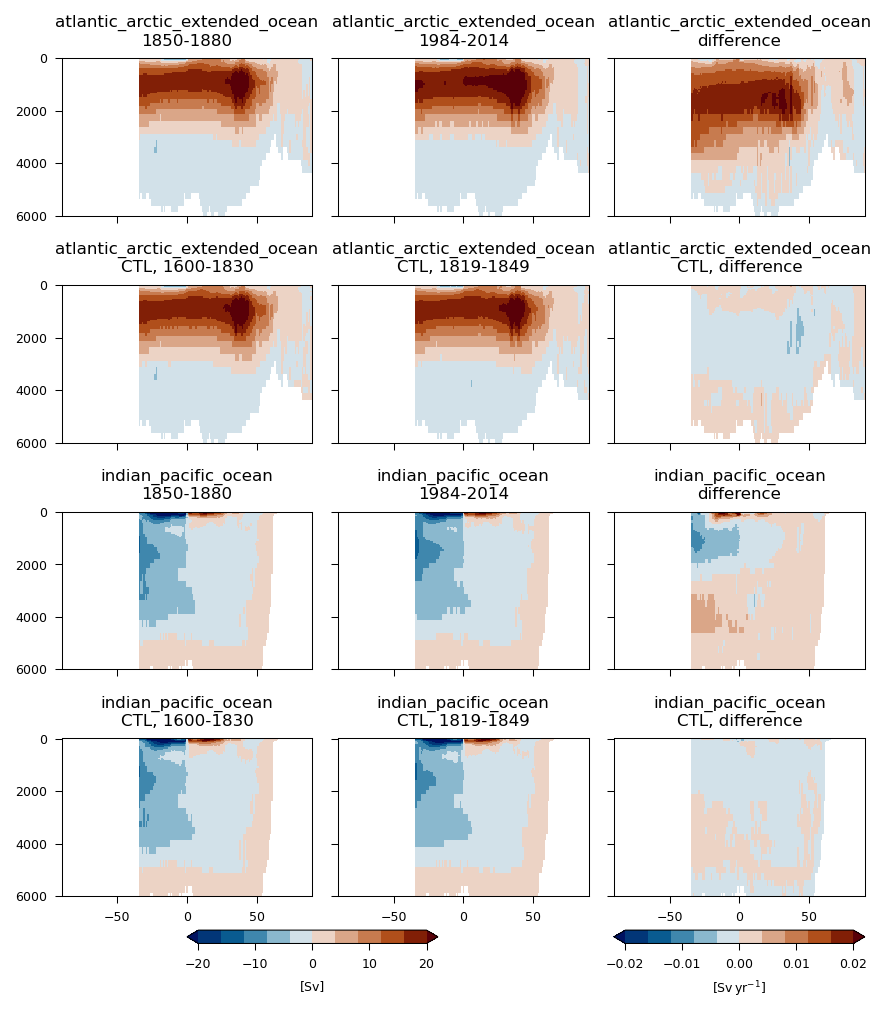

In [69]:
#--------------------
# Figure parameters
#--------------------

row_list = [1, 2]

zfact = 1/1025*1e-6 # kg s-1 to Sv 
units = 'Sv'

#______________
# Sections axis labeling and limits
xlim = (-90, 90)
ylim = (6000, -10)

#______________
# Section cmap
a = cmcrameri.cm.vik
colors = a(np.linspace(0,1,10+2))
newcmap = ListedColormap(colors[1:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[0])
newcmap.set_bad("none")

#______________
# Section pcm kwargs
kwpcm = dict(cmap=newcmap, vmin=-20, vmax=20)
kwpcm_d = dict(cmap=newcmap, vmin=-.02, vmax=.02)

#______________
# panel labeling
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]
# Create a list of double letter combinations (aa, ab, ..., zz)
double_letters = [a + b for a in string.ascii_lowercase for b in string.ascii_lowercase]
extended_alphabet = alphabet + double_letters
extended_alphabet_reverse = extended_alphabet[::-1]

# Pop one now to save a) for the barplot at the top
extended_alphabet_reverse.pop()

#______________
# Set figure
ncol = 3
nrow = len(row_list)*2
fwidth_cm = 5
fheight_cm = 4
fsize = (fwidth_cm*cm2in*ncol, fheight_cm*cm2in*nrow) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, sharex='col', sharey='row')

#--------------------
# Plot sections
#--------------------

pcm = np.zeros_like(ax)
irow = 0
for vrow in row_list: 
    
    #####
    
    data1 = zwda1_hist.isel(basin=vrow)
    data2 = zwda2_hist.isel(basin=vrow)

    basinname = data1.sector.data.item().decode('utf-8').strip()
    
    icol = 0
    zax = ax[irow, icol]
    xxx = data1.latitude.values
    yyy = data1.depth.values
    ccc = data1.values * zfact
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\n1850-1880'
    zax.set_title(zwttl)

    icol = 1
    zax = ax[irow, icol]
    xxx = data2.latitude.values
    yyy = data2.depth.values
    ccc = data2.values * zfact
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\n1984-2014'
    zax.set_title(zwttl)

    icol = 2
    zax = ax[irow, icol]
    xxx = data1.latitude.values
    yyy = data1.depth.values
    dt = (2014+1984)/2 - (1850+1880)/2
    ccc = (data2.values - data1.values) * zfact / dt
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm_d)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\ndifference'
    zax.set_title(zwttl)
    
    irow+=1
                 
    
    data1 = zwda1_ctl.isel(basin=vrow)
    data2 = zwda2_ctl.isel(basin=vrow)

    basinname = data1.sector.data.item().decode('utf-8').strip()
    
    icol = 0
    zax = ax[irow, icol]
    xxx = data1.latitude.values
    yyy = data1.depth.values
    ccc = data1.values * zfact
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\nCTL, 1600-1830'
    zax.set_title(zwttl)

    icol = 1
    zax = ax[irow, icol]
    xxx = data2.latitude.values
    yyy = data2.depth.values
    ccc = data2.values * zfact
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\nCTL, 1819-1849'
    zax.set_title(zwttl)

    icol = 2
    zax = ax[irow, icol]
    xxx = data1.latitude.values
    yyy = data1.depth.values
    dt = (1849+1819)/2 - (1600+1630)/2
    ccc = (data2.values - data1.values) * zfact / dt
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm_d)
    pcm[irow, icol] = zwpcm
    zax.set_ylim(ylim)
    zax.set_xlim(xlim)
    zwttl = f'{basinname}\nCTL, difference'
    zax.set_title(zwttl)
                 
    irow+=1

#
                 
fig.tight_layout()              
                
#---------------------
# Colorbar
#---------------------

zw1 = ax[-1, 0].get_position()
nx0 = zw1.x0 + .5*zw1.width
ny0 = zw1.y0 - .3*zw1.height
nw  = zw1.width
nh  = 0.05*nw
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm[-1, 0], cax=cax, orientation='horizontal', \
                    ticklocation='bottom', extend='both')
clabel = f'[{units}]'
cbar.set_label(clabel)

zw1 = ax[-1, -1].get_position()
nx0 = zw1.x0 
ny0 = zw1.y0 - .3*zw1.height
nw  = zw1.width
nh  = 0.05*nw
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm[-1, -1], cax=cax, orientation='horizontal', \
                    ticklocation='bottom', extend='both')
clabel = f'[{units}'+'$\,$yr$^{-1}$]'
cbar.set_label(clabel)


print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

# Prepare PO-tracer

In [32]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Prepare PO tracer')

vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice('1982', '2013')

#________________
# Get data
print('Get data...')    

var = 'po4'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda1 = zwds[var].sel(year=tslice).mean(dim='year')

var = 'o2'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds) # in mol.m-3
zwda2 = zwds[var].sel(year=tslice).mean(dim='year')

#________________
# Compute PO tracer
print('Compute PO tracer...')
# zwda_pot = 172*zwda1 + zwda2 # po-tracer = 172*po4+o2
zwda_pot = zwda1 + zwda2/175# po-tracer = po4 + o2/175 Broecker et al. 1991
zwda_pot.name='po-tracer'

#________________
# create dataset
zwda_ds = zwda_pot.to_dataset() 
zwda_ds.attrs['description'] = 'PO tracer = PO4 + O2/175 # Broecker et al. 1991'

#________________
# Save in netcdf
print('Save in netcdf...')
ncname = netcdfdir+vesm+'_'+simu+f'_po_tracer_average_on_{tslice.start}-{tslice.stop}.nc'
zwda_ds.to_netcdf(ncname)
print('File saved: %s'%ncname)

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-11-25 11:11:02.423595
################################
# Prepare PO tracer
Get data...
Compute PO tracer...
Save in netcdf...
File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_po_tracer_average_on_1982-2013.nc
################################
Done:  2025-11-25 11:11:27.730822
################################
################################
peak memory: 44360.02 MiB, increment: 22692.35 MiB
CPU times: user 5.59 s, sys: 3.16 s, total: 8.74 s
Wall time: 25.7 s


# Prepare density

In [33]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Prepare density')

vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice('1982', '2013')

#________________
# Get data
print('Get data...')    

var = 'thetao'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_temp = zwds[var]

var = 'so'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_sali = zwds[var]


#________________
# Compute density
print('Compute density...')
zwda_sigma0 = compute_potential_density_anomaly(zwda_temp, zwda_sali).mean(dim='year')

#________________
# create dataset
zwda_ds = zwda_sigma0.to_dataset() 

#________________
# Save in netcdf
print('Save in netcdf...')
ncname = netcdfdir+f'{vesm}_{simu}_sigma0_average_on_{tslice.start}-{tslice.stop}.nc'
zwda_ds.to_netcdf(ncname)
print('    File saved: %s'%ncname)
    
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-11-25 11:11:28.193517
################################
# Prepare density
Get data...
Compute density...
Save in netcdf...
[########################################] | 100% Completed | 12.54 s
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_sigma0_average_on_1982-2013.nc
################################
Done:  2025-11-25 11:12:03.416541
################################
################################
peak memory: 47531.65 MiB, increment: 25826.41 MiB
CPU times: user 41.6 s, sys: 4.76 s, total: 46.4 s
Wall time: 35.7 s


# Analysis in geographical space

## Compute trends for TTD age

In [58]:
%%time
%%memit -c
# ca. 5min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Compute trends for TTD age')
print('################################')

vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2000)
var = 'mageF12'

#________________
# Get data
print('Get data...')
# fname = netcdfdir + f'{vesm}_{simu}_{var}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
fname = netcdfdir + f'{vesm}_{simu}_{var}_1982-2013.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda = zwds[var].sel(year=tslice) # in years
zwda = zwda.where(np.isfinite(zwda))

#________________
# Save for later
ymin = int(np.min(zwda['year']))
ymax = int(np.max(zwda['year']))

#________________
# Compute linear regression zwda
print('Compute linear regression...')
year = expand_coords(zwda, 'year')
linreg_results = linregress_esmtools(year, zwda.chunk(dict(year=-1)), dim='year', nan_policy='omit').compute()

zwtxt = f'Results from scipy.stats.linregress calculating a linear \
least-squares regression of {var} against time. The linear regression is computed of the years \
{ymin} to {ymax}. The dataset contains the following variables: \
1) slope : Slope of the regression line. \
2) intercept : Intercept of the regression line. \
3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
    is equal to the coefficient of determination. \
4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
    that the slope is zero, using Wald Test with t-distribution of \
    the test statistic. See `alternative` above for alternative \
    hypotheses. \
5) stderr : Standard error of the estimated slope (gradient), under the \
    assumption of residual normality. \
To compute the trend over years: trd = slope * years + intercept'
linreg_results.attrs['description'] = ' '.join(zwtxt.split())

# Save in netcdf
#---------------    
print('Save in netcdf...')
ncname = netcdfdir+vesm+'_'+simu+'_'+var+'_linregress_on_%04d-%04d.nc'%(ymin, ymax)
linreg_results.to_netcdf(ncname)
print('File saved: %s'%ncname)
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-12-10 13:29:47.622107
# Analysis in geographical space
## Compute trends for TTD age
################################
Get data...
Compute linear regression...
[###                                     ] | 8% Completed | 65.91 s

/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


[########################################] | 100% Completed | 304.89 s
[########################################] | 100% Completed | 304.89 s
Save in netcdf...
File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_mageF12_linregress_on_1982-2000.nc
################################
Done:  2025-12-10 13:34:56.551185
################################
################################
peak memory: 27357.05 MiB, increment: 15726.82 MiB
CPU times: user 4min 37s, sys: 1min 44s, total: 6min 22s
Wall time: 5min 9s


## Compute trends for ideal age fitting ttd-age finite values

In [60]:
%%time
%%memit -c
# ca. 5min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Compute trends for ideal age fitting ttd-age finite values')
print('################################')

vesm = 'NorESM2-LM'
MAIN_VAR = 'agessc'
simu = 'historical'
tslice = slice(1982, 2000)

picontrol_refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600, 
    'CNRM-ESM2-1'  : 1850, 
    'GFDL-CM4'     :  101,
    'GFDL-ESM4'    :  101,
    'UKESM1-0-LL'  : 2250
}

number_of_years = 2099-1850


#________________
# Get data
print('Get data...')

fname_list = [f"{dirshared}{vesm}_{simu}_{MAIN_VAR}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_XXX = zwds[MAIN_VAR]

#________________
# Get age and aou drifts and remove it
print('Get drift and remove it...')

tperiod_drift = f'{picontrol_refyear_dict[vesm]:04d}-{picontrol_refyear_dict[vesm]+number_of_years:04d}'
fname = dirshared+vesm+'_piControl_'+MAIN_VAR+'_linregress_on_'+tperiod_drift+'.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_XXX_drift_slope = zwds['slope']

year = zwda_XXX.year
zwda_XXX_drift = (year - year[0])*zwda_XXX_drift_slope
for zwcoords in zwda_XXX.coords : 
    if zwcoords in zwda_XXX_drift.coords: zwda_XXX_drift[zwcoords] = zwda_XXX[zwcoords]
#
zwda_XXX = (zwda_XXX - zwda_XXX_drift).rename(zwda_XXX.name)

#________________
# Get finite values ttd-age and select ideal age
print('Get finite values ttd-age and select ideal age...')

var = 'mageF12'
# fname = netcdfdir + f'{vesm}_{simu}_{var}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
fname = netcdfdir + f'{vesm}_{simu}_{var}_1982-2013.nc'
zwds = xr.open_dataset(fname, **kwopends).sel(year=tslice)
zwda_ttdage = zwds[var]

zwda_XXX = zwda_XXX.where(np.isfinite(zwda_ttdage))

#________________
# Save for later
ymin_XXX = int(np.min(zwda_XXX['year']))
ymax_XXX = int(np.max(zwda_XXX['year']))

#________________
# Compute linear regression zwda
print('Compute linear regression...')
year = expand_coords(zwda_XXX, 'year')
linreg_results = linregress_esmtools(year, zwda_XXX.chunk(dict(year=-1)), dim='year', nan_policy='omit').compute()

zwtxt = f'Results from scipy.stats.linregress calculating a linear \
least-squares regression of {MAIN_VAR} against time. The linear regression is computed of the years \
{ymin_XXX} to {ymax_XXX}. The dataset contains the following variables: \
1) slope : Slope of the regression line. \
2) intercept : Intercept of the regression line. \
3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
    is equal to the coefficient of determination. \
4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
    that the slope is zero, using Wald Test with t-distribution of \
    the test statistic. See `alternative` above for alternative \
    hypotheses. \
5) stderr : Standard error of the estimated slope (gradient), under the \
    assumption of residual normality. \
To compute the trend over years: trd = slope * years + intercept'
linreg_results.attrs['description'] = ' '.join(zwtxt.split())

# Save in netcdf
#---------------    
print('Save in netcdf...')
ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_linregress_on_{int(ymin_XXX):04d}-{int(ymax_XXX):04d}_drift_removed_fitting_ttdage_finite_values.nc'
linreg_results.to_netcdf(ncname)
print('File saved: %s'%ncname)
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-12-10 13:36:11.175002
# Analysis in geographical space
## Compute trends for ideal age fitting ttd-age finite values
################################
Get data...
Get drift and remove it...
Get finite values ttd-age and select ideal age...
Compute linear regression...
[##############                          ] | 36% Completed | 70.21 s

/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


[########################################] | 100% Completed | 354.87 s
[########################################] | 100% Completed | 354.97 s
Save in netcdf...
File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_agessc_linregress_on_1982-2000_drift_removed_fitting_ttdage_finite_values.nc
################################
Done:  2025-12-10 13:42:15.436638
################################
################################
peak memory: 33078.57 MiB, increment: 19586.27 MiB
CPU times: user 5min 19s, sys: 2min 30s, total: 7min 50s
Wall time: 6min 4s


## Compute trends for AOU fitting ttd-age finite values

In [78]:
%%time
%%memit -c
# ca. 5min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Compute trends for AOU fitting ttd-age finite values')
print('################################')

vesm = 'NorESM2-LM'
MAIN_VAR = 'aou'
simu = 'historical'
tslice = slice(1982, 2000)

picontrol_refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600, 
    'CNRM-ESM2-1'  : 1850, 
    'GFDL-CM4'     :  101,
    'GFDL-ESM4'    :  101,
    'UKESM1-0-LL'  : 2250
}

number_of_years = 2099-1850


#________________
# Get data
print('Get data...')

fname_list = [f"{dirshared}{vesm}_{simu}_{MAIN_VAR}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_XXX = zwds[MAIN_VAR]

#________________
# Get age and aou drifts and remove it
print('Get drift and remove it...')

tperiod_drift = f'{picontrol_refyear_dict[vesm]:04d}-{picontrol_refyear_dict[vesm]+number_of_years:04d}'
fname = dirshared+vesm+'_piControl_'+MAIN_VAR+'_linregress_on_'+tperiod_drift+'.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_XXX_drift_slope = zwds['slope']

year = zwda_XXX.year
zwda_XXX_drift = (year - year[0])*zwda_XXX_drift_slope
for zwcoords in zwda_XXX.coords : 
    if zwcoords in zwda_XXX_drift.coords: zwda_XXX_drift[zwcoords] = zwda_XXX[zwcoords]
#
zwda_XXX = (zwda_XXX - zwda_XXX_drift).rename(zwda_XXX.name)

#________________
# Get finite values ttd-age and select aou
print('Get finite values ttd-age and select aou...')

var = 'mageF12'
# fname = netcdfdir + f'{vesm}_{simu}_{var}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
fname = netcdfdir + f'{vesm}_{simu}_{var}_1982-2013.nc'
zwds = xr.open_dataset(fname, **kwopends).sel(year=tslice)
zwda_ttdage = zwds[var]

zwda_XXX = zwda_XXX.where(np.isfinite(zwda_ttdage))

#________________
# Save for later
ymin_XXX = int(np.min(zwda_XXX['year']))
ymax_XXX = int(np.max(zwda_XXX['year']))

#________________
# Compute linear regression zwda
print('Compute linear regression...')
year = expand_coords(zwda_XXX, 'year')
linreg_results = linregress_esmtools(year, zwda_XXX.chunk(dict(year=-1)), dim='year', nan_policy='omit').compute()

zwtxt = f'Results from scipy.stats.linregress calculating a linear \
least-squares regression of {MAIN_VAR} against time. The linear regression is computed of the years \
{ymin_XXX} to {ymax_XXX}. The dataset contains the following variables: \
1) slope : Slope of the regression line. \
2) intercept : Intercept of the regression line. \
3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
    is equal to the coefficient of determination. \
4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
    that the slope is zero, using Wald Test with t-distribution of \
    the test statistic. See `alternative` above for alternative \
    hypotheses. \
5) stderr : Standard error of the estimated slope (gradient), under the \
    assumption of residual normality. \
To compute the trend over years: trd = slope * years + intercept'
linreg_results.attrs['description'] = ' '.join(zwtxt.split())

# Save in netcdf
#---------------    
print('Save in netcdf...')
ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_linregress_on_{int(ymin_XXX):04d}-{int(ymax_XXX):04d}_drift_removed_fitting_ttdage_finite_values.nc'
linreg_results.to_netcdf(ncname)
print('File saved: %s'%ncname)
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-12-10 14:10:36.303851
# Analysis in geographical space
## Compute trends for AOU fitting ttd-age finite values
################################
Get data...
Get drift and remove it...
Get finite values ttd-age and select aou...
Compute linear regression...
[##############                          ] | 36% Completed | 55.31 s

/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:182: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:196: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/daco/.local/lib/python3.10/site-packages/scipy/stats/_stats_mstats_common.py:199: RuntimeWarning: invalid value encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


[########################################] | 100% Completed | 349.43 s
[########################################] | 100% Completed | 349.53 s
Save in netcdf...
File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_aou_linregress_on_1982-2000_drift_removed_fitting_ttdage_finite_values.nc
################################
Done:  2025-12-10 14:16:35.009757
################################
################################
peak memory: 50723.86 MiB, increment: 27495.45 MiB
CPU times: user 5min 15s, sys: 2min 28s, total: 7min 43s
Wall time: 5min 59s


## Plot data

### Load data

In [98]:
%%time
%%memit -c

vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2013)
# tperiod4trends = '1982-2000'
tperiod4trends = '1982-2013'

var = 'mageF12'
fname = netcdfdir + f'{vesm}_{simu}_{var}_1982-2013.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_mage12 = zwds[var].sel(year=tslice) # in years
zwda_mage12 = zwda_mage12.where(np.isfinite(zwda_mage12))

var = 'agessc'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwda_agessc = zwds[var].sel(year=tslice) # in years
zwda_agessc = zwda_agessc.where(np.isfinite(zwda_mage12)).load()

refyear = 1600
simu='piControl'
startyear, endyear = int(refyear+tslice.start-1850), int(refyear+tslice.stop-1850)
tslice_ctl = slice(startyear, endyear)
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice_ctl.start), int(tslice_ctl.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwda_agessc_ctl = zwds[var].sel(year=tslice_ctl) # in years
zwda_agessc_ctl = zwda_agessc_ctl.where(np.isfinite(zwda_mage12).values).load()

# fname = netcdfdir + f'{vesm}_historical_mageF12_linregress_on_1982-2013.nc'
fname = netcdfdir + f'{vesm}_historical_mageF12_linregress_on_{tperiod4trends}.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_mageF12_trd = zwds['slope']
zwda_mageF12_trd_pval = zwds['pvalue']

# fname =  netcdfdir + f'{vesm}_historical_agessc_linregress_on_1982-2013_drift_removed_fitting_ttdage_finite_values.nc'
fname =  netcdfdir + f'{vesm}_historical_agessc_linregress_on_{tperiod4trends}_drift_removed_fitting_ttdage_finite_values.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_agessc_trd = zwds['slope']
zwda_agessc_trd = zwda_agessc_trd.where(np.isfinite(zwda_mageF12_trd).values).load()
zwda_agessc_trd_pval = zwds['pvalue']
zwda_agessc_trd_pval = zwda_agessc_trd_pval.where(np.isfinite(zwda_mageF12_trd).values).load()

# fname =  netcdfdir + f'{vesm}_historical_aou_linregress_on_1982-2013_drift_removed_fitting_ttdage_finite_values.nc'
fname =  netcdfdir + f'{vesm}_historical_aou_linregress_on_{tperiod4trends}_drift_removed_fitting_ttdage_finite_values.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_aou_trd_pval = zwds['pvalue']
zwda_aou_trd_pval = zwda_aou_trd_pval.where(np.isfinite(zwda_mageF12_trd).values).load()

fname = dirshared+vesm+'_piControl_agessc_linregress_on_1600-1849.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_agessc_drift = zwds['slope']
zwda_agessc_drift = zwda_agessc_drift.where(np.isfinite(zwda_mageF12_trd).values).load()

year = zwda_agessc.year
zwda_drift_correction = (year - year[0])*zwda_agessc_drift
for zwcoords in zwda_agessc.coords : 
    if zwcoords in zwda_drift_correction.coords: zwda_drift_correction[zwcoords] = zwda_agessc[zwcoords]
#
zwda_agessc_drift_corrected = (zwda_agessc - zwda_drift_correction).rename(zwda_agessc.name)




peak memory: 55521.12 MiB, increment: 31717.21 MiB
CPU times: user 4.91 s, sys: 2.95 s, total: 7.86 s
Wall time: 26.3 s


### Distribution of trends

In [99]:
%%time
%%memit -c

zwda_agessc_trd_flat = zwda_agessc_trd.values.flatten()
zwda_agessc_trd_flat = zwda_agessc_trd_flat[np.isfinite(zwda_agessc_trd_flat)]

zwda_agessc_drift_flat = zwda_agessc_drift.values.flatten()
zwda_agessc_drift_flat = zwda_agessc_drift_flat[np.isfinite(zwda_agessc_drift_flat)]

zwda_mageF12_trd_flat = zwda_mageF12_trd.values.flatten()
zwda_mageF12_trd_flat = zwda_mageF12_trd_flat[np.isfinite(zwda_mageF12_trd_flat)]

COND = (zwda_mageF12_trd_pval<=.05) & (zwda_agessc_trd_pval<=.05) & (zwda_aou_trd_pval<=.05)

zwda_agessc_drift_signif_flat = zwda_agessc_drift.where(COND).values.flatten()
zwda_agessc_drift_signif_flat = zwda_agessc_drift_signif_flat[np.isfinite(zwda_agessc_drift_signif_flat)]

zwda_agessc_trd_signif_flat = zwda_agessc_trd.where(COND).values.flatten()
zwda_agessc_trd_signif_flat = zwda_agessc_trd_signif_flat[np.isfinite(zwda_agessc_trd_signif_flat)]

zwda_mageF12_trd_signif_flat = zwda_mageF12_trd.where(COND).values.flatten()
zwda_mageF12_trd_signif_flat = zwda_mageF12_trd_signif_flat[np.isfinite(zwda_mageF12_trd_signif_flat)]


peak memory: 63688.86 MiB, increment: 31857.35 MiB
CPU times: user 1.08 s, sys: 185 ms, total: 1.27 s
Wall time: 1.41 s


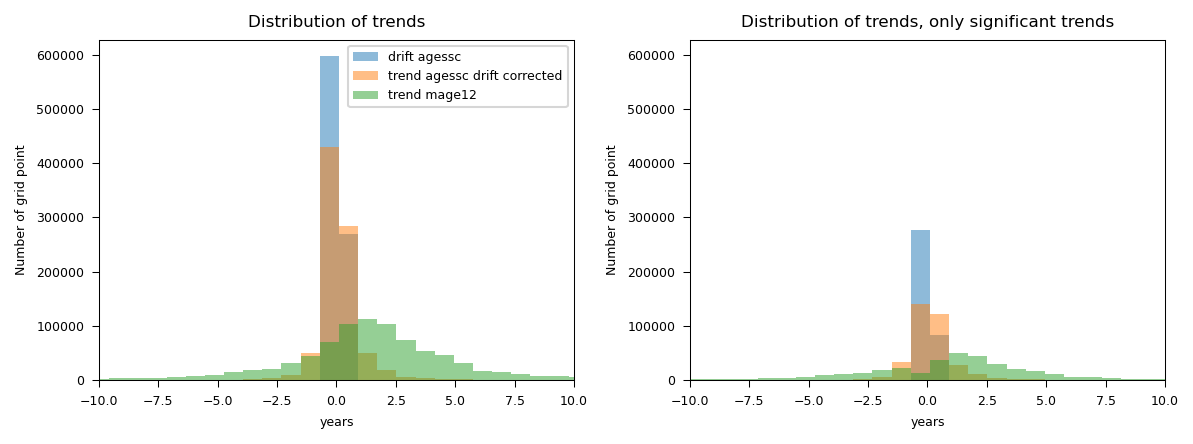

In [100]:
zwmax = np.max(np.concatenate([zwda_agessc_trd_flat, zwda_agessc_drift_flat, zwda_mageF12_trd_flat]))
zwmin = np.min(np.concatenate([zwda_agessc_trd_flat, zwda_agessc_drift_flat, zwda_mageF12_trd_flat]))
bins_range = [zwmin, zwmax]

kwhist = dict(range=bins_range, bins=1000, alpha=.5)

plt.figure(figsize=(8, 3))
ax1 = plt.subplot(121)
_, _, _ = plt.hist(zwda_agessc_drift_flat, label='drift agessc', **kwhist)
_, _, _ = plt.hist(zwda_agessc_trd_flat, label='trend agessc drift corrected', **kwhist)
_, _, _ = plt.hist(zwda_mageF12_trd_flat, label='trend mage12', **kwhist)
plt.xlim(-10, 10)
plt.xlabel('years')
plt.ylabel('Number of grid point')
plt.title('Distribution of trends')
plt.legend()
plt.subplot(122, sharey=ax1)
_, _, _ = plt.hist(zwda_agessc_drift_signif_flat, label='drift agessc', **kwhist)
_, _, _ = plt.hist(zwda_agessc_trd_signif_flat, label='trend agessc drift corrected', **kwhist)
_, _, _ = plt.hist(zwda_mageF12_trd_signif_flat, label='trend mage12', **kwhist)
plt.xlim(-10, 10)
plt.xlabel('years')
plt.ylabel('Number of grid point')
plt.title('Distribution of trends, only significant trends')

plt.tight_layout()

### Maps trends and differences between first and last five years

Text(0.5, 1.0, 'As above, only significant trends')

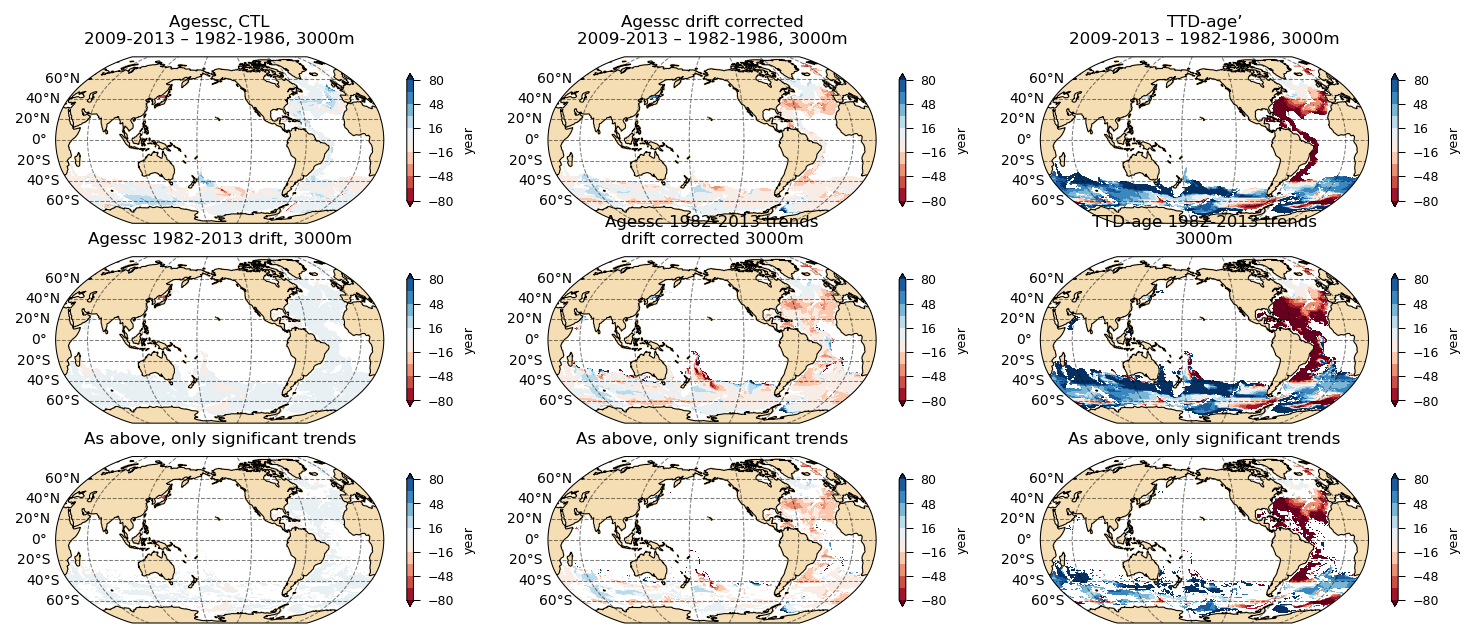

In [101]:
zfact = .5*(2013+2009) - .5*(1982+1986)

kkk = 54

plt.figure(figsize=(12, 5))
zwccrsproj = ccrs.Robinson(central_longitude=-155)

yyy1 = slice(5)
yyy2 = slice(None, -6, -1)
kwpcm = dict(vmin=-80, vmax=80, zwcbExtend='both', zwcbLabel='year')

ax = plt.subplot(331, projection=zwccrsproj)
data2plot = zwda_agessc_ctl.isel(year=yyy2, k=kkk).mean(dim='year') - zwda_agessc_ctl.isel(year=yyy1, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'Agessc, CTL\n2009-2013 – 1982-1986, {data2plot.depth.values:.0f}m')

ax = plt.subplot(332, projection=zwccrsproj)
data2plot = zwda_agessc_drift_corrected.isel(year=yyy2, k=kkk).mean(dim='year') - zwda_agessc_drift_corrected.isel(year=yyy1, k=kkk).mean(dim='year') 
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'Agessc drift corrected\n2009-2013 – 1982-1986, {data2plot.depth.values:.0f}m')

ax = plt.subplot(333, projection=zwccrsproj)
data2plot = zwda_mage12.isel(year=yyy2, k=kkk).mean(dim='year') - zwda_mage12.isel(year=yyy1, k=kkk).mean(dim='year')
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'TTD-age’\n2009-2013 – 1982-1986, {data2plot.depth.values:.0f}m')

ax = plt.subplot(334, projection=zwccrsproj)
data2plot = zwda_agessc_drift.isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'Agessc 1982-2013 drift, {data2plot.depth.values:.0f}m')

ax = plt.subplot(335, projection=zwccrsproj)
data2plot = zwda_agessc_trd.isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'Agessc 1982-2013 trends\ndrift corrected {data2plot.depth.values:.0f}m')

ax = plt.subplot(336, projection=zwccrsproj)
data2plot = zwda_mageF12_trd.isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'TTD-age 1982-2013 trends\n{data2plot.depth.values:.0f}m')

COND = (zwda_mageF12_trd_pval<=.05) & (zwda_agessc_trd_pval<=.05) & (zwda_aou_trd_pval<=.05)

ax = plt.subplot(337, projection=zwccrsproj)
data2plot = zwda_agessc_drift.where(COND).isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'As above, only significant trends')

ax = plt.subplot(338, projection=zwccrsproj)
data2plot = zwda_agessc_trd.where(COND).isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'As above, only significant trends')

ax = plt.subplot(339, projection=zwccrsproj)
data2plot = zwda_mageF12_trd.where(COND).isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
ax.set_title(f'As above, only significant trends')


### Plot timeseries

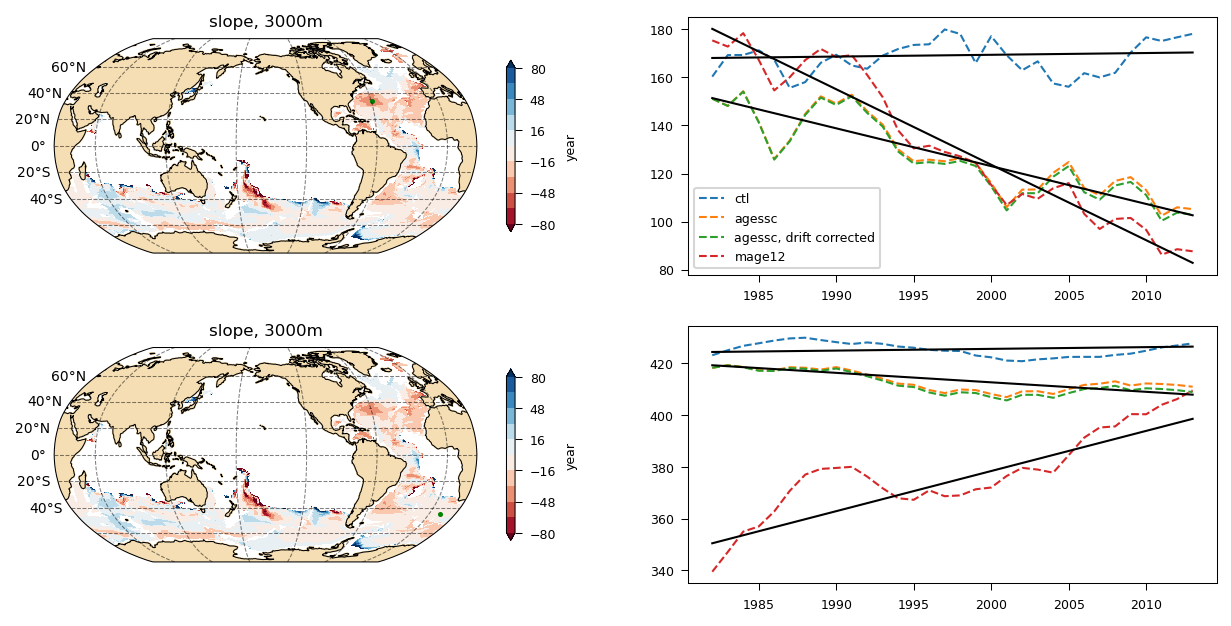

In [102]:
zfact = .5*(2013+2009) - .5*(1982+1986)
refyear = 1600

kwpcm = dict(vmin=-80, vmax=80, zwcbExtend='both', zwcbLabel='year')
plt.figure(figsize=(10, 5))
zwccrsproj = ccrs.Robinson(central_longitude=-155)

kkk = 54
jjj = 270
iii = 50
ax = plt.subplot(221, projection=zwccrsproj)
data2plot = zwda_agessc_trd.isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
X = data2plot.isel(j=jjj, i=iii).longitude.values
Y = data2plot.isel(j=jjj, i=iii).latitude.values
plt.scatter(X, Y, transform = ccrs.PlateCarree(), c='green', s=2)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m')

#__________________
# time series

ax = plt.subplot(222)

data2plot = zwda_agessc_ctl.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values-refyear+1850, data2plot.values, label='ctl', ls='--')

data2plot = zwda_agessc.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='agessc', ls='--')

data2plot = zwda_agessc_drift_corrected.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='agessc, drift corrected', ls='--')

data2plot = zwda_mage12.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='mage12', ls='--')

#__________________
# add trends and drift

years = zwda_agessc_drift_corrected.year.values
data2plot = (years - .5*(years[0]+years[-1]))*zwda_agessc_trd.isel(k=kkk, j=jjj, i=iii).values + \
            .5*(zwda_agessc_drift_corrected.isel(year=0, k=kkk, j=jjj, i=iii).values + \
                zwda_agessc_drift_corrected.isel(year=-1, k=kkk, j=jjj, i=iii).values)
ax.plot(years, data2plot, ls='-', c='k')

years = zwda_agessc_ctl.year.values-refyear+1850
data2plot = (years - .5*(years[0]+years[-1]))*zwda_agessc_drift.isel(k=kkk, j=jjj, i=iii).values + \
            .5*(zwda_agessc_ctl.isel(year=0, k=kkk, j=jjj, i=iii).values + \
                zwda_agessc_ctl.isel(year=-1, k=kkk, j=jjj, i=iii).values)
ax.plot(years, data2plot, ls='-', c='k')

years = zwda_mage12.year.values
data2plot = (years - .5*(years[0]+years[-1]))*zwda_mageF12_trd.isel(k=kkk, j=jjj, i=iii).values + \
            .5*(zwda_mage12.isel(year=0, k=kkk, j=jjj, i=iii).values + \
                zwda_mage12.isel(year=-1, k=kkk, j=jjj, i=iii).values)
ax.plot(years, data2plot, ls='-', c='k')


ax.legend()


kkk = 54
jjj = 90
iii = 120

ax = plt.subplot(223, projection=zwccrsproj)
data2plot = zwda_agessc_trd.isel(k=kkk)*zfact
map_whole_globe(data2plot, zwax=ax, **kwpcm)
X = data2plot.isel(j=jjj, i=iii).longitude.values
Y = data2plot.isel(j=jjj, i=iii).latitude.values
plt.scatter(X, Y, transform = ccrs.PlateCarree(), c='green', s=2)
ax.set_title(f'{data2plot.name}, {data2plot.depth.values:.0f}m')

#__________________
# time series

ax = plt.subplot(224)

data2plot = zwda_agessc_ctl.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values-refyear+1850, data2plot.values, label='ctl', ls='--')

data2plot = zwda_agessc.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='agessc', ls='--')

data2plot = zwda_agessc_drift_corrected.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='agessc, drift corrected', ls='--')

data2plot = zwda_mage12.isel(k=kkk, j=jjj, i=iii)
ax.plot(data2plot.year.values, data2plot.values, label='mage12', ls='--')

#__________________
# add trends and drift

years = zwda_agessc_drift_corrected.year.values
data2plot = (years - .5*(years[0]+years[-1]))*zwda_agessc_trd.isel(k=kkk, j=jjj, i=iii).values + \
            .5*(zwda_agessc_drift_corrected.isel(year=0, k=kkk, j=jjj, i=iii).values + \
                zwda_agessc_drift_corrected.isel(year=-1, k=kkk, j=jjj, i=iii).values)
ax.plot(years, data2plot, ls='-', c='k')

years = zwda_agessc_ctl.year.values-refyear+1850
data2plot = (years - .5*(years[0]+years[-1]))*zwda_agessc_drift.isel(k=kkk, j=jjj, i=iii).values + \
            .5*(zwda_agessc_ctl.isel(year=0, k=kkk, j=jjj, i=iii).values + \
                zwda_agessc_ctl.isel(year=-1, k=kkk, j=jjj, i=iii).values)
ax.plot(years, data2plot, ls='-', c='k')

years = zwda_mage12.year.values
data2plot = (years - .5*(years[0]+years[-1]))*zwda_mageF12_trd.isel(k=kkk, j=jjj, i=iii).values + \
            .5*(zwda_mage12.isel(year=0, k=kkk, j=jjj, i=iii).values + \
                zwda_mage12.isel(year=-1, k=kkk, j=jjj, i=iii).values)
ax.plot(years, data2plot, ls='-', c='k')



## Compare ttd-age trends and ideal age trends when computed in geographical space

### Prepare data2plot

In [88]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Compare ttd-age trends and ideal age trends when computed in geographical space')
print('################################')

from fast_histogram import histogram2d

vesm = 'NorESM2-LM'
simu = 'historical'
tperiod4trends = '1982-2000'

#----------------
# Load data 
#----------------

#_________________
# Get mageF12 trend data
print('Get mageF12 trend data...')
fname = netcdfdir + f'{vesm}_{simu}_mageF12_linregress_on_{tperiod4trends}.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_slope_mageF12 = zwds['slope']
zwda_pval_mageF12 = zwds['pvalue']

#_________________
# Get ideal age trend data
print('Get ideal age trend data...')
fname =  netcdfdir + f'{vesm}_{simu}_agessc_linregress_on_{tperiod4trends}_drift_removed_fitting_ttdage_finite_values.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_slope_agessc = zwds['slope']
zwda_pval_agessc = zwds['pvalue']

#_________________
# Get aou trend data
print('Get aou trend data...')
fname =  netcdfdir + f'{vesm}_{simu}_aou_linregress_on_{tperiod4trends}_drift_removed_fitting_ttdage_finite_values.nc'
zwds = xr.open_dataset(fname, **kwopends)
zwda_slope_aou = zwds['slope']
zwda_pval_aou = zwds['pvalue']

#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#----------------
# Compute volume
#----------------
print('Compute volume and omask...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello']
# FOR MPI model, invert latitude dimension
if vesm == 'MPI-ESM1-2-LR' : 
    zarea = zarea.isel(j=slice(None, None, -1))
#

depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)

omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

del depbounds, depthickness
   
#----------------
# Get PO-tracer threshold for water mass definition
#----------------

print('Get PO-tracer threshold for water mass definition...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#----------------
# Define water mass
#----------------

print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

# COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 80) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])

COND_watermass_dict = {
    'southern_dense': COND_southern_dense,
    'southern_light': COND_southern_light,
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
}

#----------------
# Loop on water masses
#----------------

data2plot = {}
for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
    
    data2plot[watermass_name] = {}
    
    #_________________
    # Select water mass   
    print('    Select water mass and significant trends...')   
    COND = watermass_cond & (zwda_pval_mageF12<=.05) & (zwda_pval_agessc<=.05) & (zwda_pval_aou<=.05)
    agessc_in_water_mass = zwda_slope_agessc.where(watermass_cond, np.nan)
    magF12_in_water_mass = zwda_slope_mageF12.where(watermass_cond, np.nan)
    
    #_______________
    # histograms 2D

    print('    histogram 2D...')
    
    XXXflat = agessc_in_water_mass.values.flatten()
    YYYflat = magF12_in_water_mass.values.flatten()
    nbins1 = 200
    bounds = [[np.nanmin(XXXflat),
               np.nanmax(XXXflat)], 
              [np.nanmin(YYYflat), 
               np.nanmax(YYYflat)]]
    ccc = histogram2d(XXXflat, YYYflat, \
                      range=bounds, bins=nbins1).T # need to transpose for visualisation purpose
    xxx = np.linspace(bounds[0][0], bounds[0][1], nbins1)
    yyy = np.linspace(bounds[1][0], bounds[1][1], nbins1)
    data2plot[watermass_name]['histogram2d'] = {'xxx':xxx, 'yyy':yyy, 'ccc':ccc}

    #_______________
    # Compute linear regression

    print('    Compute linear regression...')
    index = ~(np.isnan(XXXflat) | np.isnan(YYYflat))
    XXXflat = XXXflat[index]
    YYYflat = YYYflat[index]
    results = scipy.stats.linregress(XXXflat, YYYflat)

    YYY_predicted = results.intercept + results.slope * XXXflat
    nnn = len(XXXflat)  # Number of observations
    t_value = scipy.stats.t.ppf(1 - 0.025, nnn - 2)  # t-value for 95% confidence interval with n-2 degrees of freedom
    # Standard error of the predicted y-values 
    s_err = np.sqrt(np.sum((YYYflat - YYY_predicted) ** 2) / (nnn - 2))    
    # nb: results.stderr is s_err/np.rmse(X)

    #_______________
    # Compute 95% confidence band
    
    print('    Compute 95% confidence band...')

    # Subsampled X and Y predicted to compute 95% confidence band
    combined = list(zip(XXXflat, YYY_predicted))
    if nnn>100: sample_size=100
    else: sample_size=nnn
    # Find the minimum and maximum elements based on the `y` values
    min_combined = min(combined, key=lambda pair: pair[0])
    max_combined = max(combined, key=lambda pair: pair[0])
    # Remove these elements from the combined list to sample the rest
    remaining_combined = [pair for pair in combined if pair != min_combined and pair != max_combined]
    # Sample the remaining elements
    remaining_sample_size = sample_size - 2
    import random
    sampled_remaining = random.sample(remaining_combined, remaining_sample_size)
    # Include the min and max elements in the final sample
    sampled_combined = [min_combined] + sampled_remaining + [max_combined]
    sampled_X, sampled_Y_predicted = zip(*sampled_combined)
    # Convert the sampled tuples back to lists (if needed)
    sampled_X = list(sampled_X)
    sampled_Y_predicted = list(sampled_Y_predicted)
    # Combine `xxx` and `yyy` and sort based on `xxx`
    xxx_yyy = sorted(zip(sampled_X, sampled_Y_predicted))
    # Unzip the sorted pairs
    sorted_xxx, sorted_yyy = zip(*xxx_yyy)
    sampled_X = np.array(sorted_xxx)
    sampled_Y_predicted = np.array(sorted_yyy)

    conf_interval = t_value * s_err * np.sqrt(1 / nnn + (sampled_X - np.mean(XXXflat))**2 / np.sum((XXXflat - np.mean(XXXflat))**2))
    lower_band = sampled_Y_predicted - conf_interval
    upper_band = sampled_Y_predicted + conf_interval

    #_______________
    # Save linregress analysis
    data2plot[watermass_name]['linregress'] = {}
    data2plot[watermass_name]['linregress']['slope'] = results.slope
    data2plot[watermass_name]['linregress']['intercept'] = results.intercept
    data2plot[watermass_name]['linregress']['rvalue'] = results.rvalue
    data2plot[watermass_name]['linregress']['pvalue'] = results.pvalue
    data2plot[watermass_name]['linregress']['stderr'] = results.stderr 
    data2plot[watermass_name]['linregress']['intercept_stderr'] = results.intercept_stderr
    data2plot[watermass_name]['linregress']['number of observation'] = nnn
    data2plot[watermass_name]['linregress']['tvalue'] = t_value
    data2plot[watermass_name]['linregress']['sampled_X'] = sampled_X
    data2plot[watermass_name]['linregress']['sampled_Y_predicted'] = sampled_Y_predicted
    data2plot[watermass_name]['linregress']['lower_band'] = lower_band
    data2plot[watermass_name]['linregress']['upper_band'] = upper_band
    data2plot[watermass_name]['linregress']['conf_interval'] = conf_interval
    data2plot[watermass_name]['linregress']['stderr_pred'] = s_err

    
#

#_________________
# Save
print('Save file...')
savefile = dirout + 'data2plot_compare_'+tperiod4trends+'_trends_ttd-age_and_ideal-age_in_geo_space.pckl'
with open(savefile, "wb") as file:
    pickle.dump(data2plot, file)
#
print('File saved: '+savefile)


################################
################################
2025-12-10 14:24:20.930641
# Analysis in geographical space
## Compare ttd-age trends and ideal age trends when computed in geographical space
################################
Get mageF12 trend data...
Get ideal age trend data...
Get aou trend data...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Compute volume and omask...
Get PO-tracer threshold for water mass definition...
Define water mass...
For watermass: southern_dense...
    Select water mass and significant trends...
    histogram 2D...
    Compute linear regression...
    Compute 95% confidence band...
For watermass: southern_light...
    Select water mass and significant trends...
    histogram 2D...
    Compute linear regression...
    Compute 95% confidence band...
For watermass: atlantic_dense...
    Select water mass and significant trends...
    histogram 2D...
    Compute linear regression...
    Compute 95% confidence band...
For 

### Plot

################################
################################
2025-12-10 14:24:55.811124
# Analysis in geographical space
## Compare ttd-age trends and ideal age trends when computed in geographical space
### Plot
################################
>>> NorESM2-LM, southern_light: 0.000
>>> NorESM2-LM, atlantic_light: 0.000
>>> NorESM2-LM, southern_dense: 0.000
>>> NorESM2-LM, atlantic_dense: 0.000
Save figure...
Figure saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/scatter_plot_compare_1982-2000_trends_ttd-age_and_ideal-age_in_geo_space.png
CPU times: user 924 ms, sys: 1.76 s, total: 2.68 s
Wall time: 961 ms


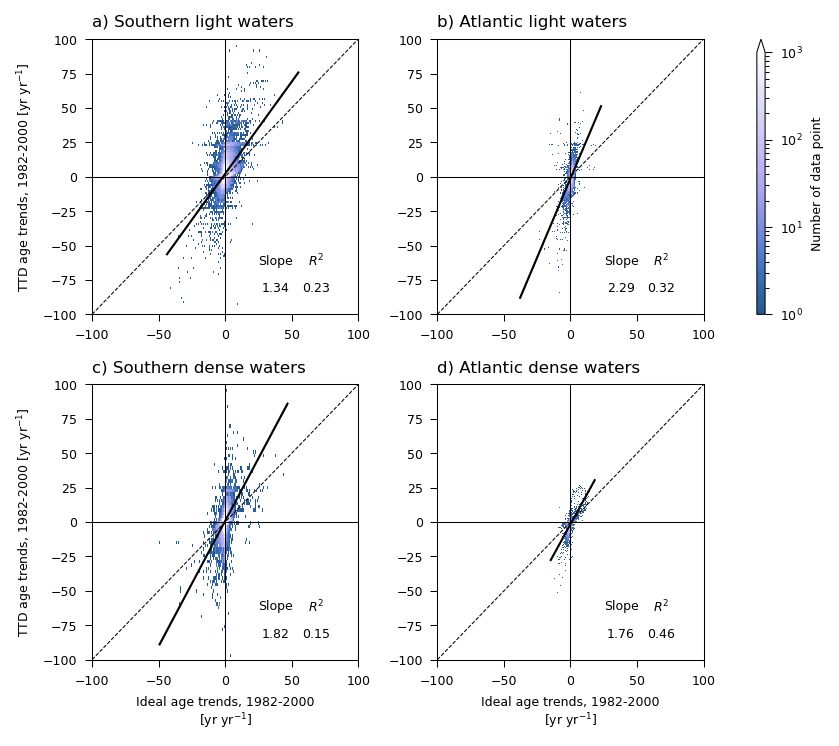

In [89]:
%%time
# %%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Compare ttd-age trends and ideal age trends when computed in geographical space')
print('### Plot')
print('################################')

tperiod4trends = '1982-2000'

#____________________
# Load data2plot

savefile = dirout + 'data2plot_compare_'+tperiod4trends+'_trends_ttd-age_and_ideal-age_in_geo_space.pckl'
# Open the pickle file in binary read mode
with open(savefile, 'rb') as file:
    # Load the dictionary from the pickle file
    data2plot = pickle.load(file)
#

#--------------------
# Figure parameters
#--------------------

#____________________
# figname
figname = savefile.replace('data2plot', 'scatter_plot').replace('.pckl', '.png')

#____________________
# list
wm_list = ['southern_light', 'atlantic_light', 'southern_dense', 'atlantic_dense']

#____________________
# Figure
fwidth_cm, fheight_cm = 12, 12
nrow, ncol = 2, 2
fsize = (fwidth_cm*cm2in, fheight_cm*cm2in) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, squeeze=False)

#____________________
# labels
region_label_dict = {
    'southern_dense': 'Southern dense waters', 
    'southern_light': 'Southern light waters', 
    'atlantic_dense': 'Atlantic dense waters', 
    'atlantic_light': 'Atlantic light waters', 
}
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]


#______________
# cmap
a = cmcrameri.cm.devon
colors = a(np.linspace(0,1,200))
newcmap = ListedColormap(colors[50:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[49])
newcmap.set_bad("none")

# a = cm.Wistia
# colors = a(np.linspace(0,1,300))
# newcmap = ListedColormap(colors[30:-1])
# newcmap.set_over(colors[-1])
# newcmap.set_under(colors[29])
# newcmap.set_bad("none")

#____________________
# keywords args
kwpcm = {
    'southern_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern and atlantic': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'total': dict(cmap=ListedColormap(['#D3D3D3']), norm=mpl.colors.LogNorm(vmin=1, vmax=1000))
}


xlim = (-100, 100)
ylim = (-100, 100)

#--------------------
# Plot
#--------------------

pcm = np.zeros_like(ax)
for iwm, vwm in enumerate(wm_list): 
    
    zax = ax.flat[iwm]
    zax.axhline(0, lw=.5, c='k')
    zax.axvline(0, lw=.5, c='k')
    zax.plot(xlim, xlim, ls='--', lw=.5, c='k')
    ttl = alphabet_reverse.pop()+') '+region_label_dict[vwm]
    zax.set_title(ttl, loc='left')
    zax.set_xlim(xlim)
    zax.set_ylim(ylim)

    #____________________
    # Selected scatter plot

    xxx = data2plot[vwm]['histogram2d']['xxx']
    yyy = data2plot[vwm]['histogram2d']['yyy']
    ccc = data2plot[vwm]['histogram2d']['ccc']
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm[vwm])
    pcm.flat[iwm] = zwpcm

    #____________________
    # Add regression line
    lines = []
    tab_col1 = []
    tab_col2 = []

    xxx = data2plot[vwm]['linregress']['sampled_X']
    yyy = data2plot[vwm]['linregress']['sampled_Y_predicted']
    yyymin = data2plot[vwm]['linregress']['lower_band']
    yyymax = data2plot[vwm]['linregress']['upper_band']

    zax.fill_between(xxx, yyymin, yyymax, color='k', alpha=0.5, lw=0)
    ll, = zax.plot(xxx, yyy, color='k', lw=1)
    lines.append(ll)
                
    #____________________
    # Save some notes for table
    slope = data2plot[vwm]['linregress']['slope']
    rvalue = data2plot[vwm]['linregress']['rvalue']
    tab_col2.append(f'{np.floor(rvalue**2*100)/100:.2f}')
    tab_col1.append(f'{slope:.2f}')
    print(f">>> {vesm}, {vwm}: {data2plot[vwm]['linregress']['pvalue']:.3f}")
        
    #____________________
    # add notes
    kwtext = dict(ha='center', va='center_baseline', fontsize=6)
    ytxt = .2 #.97
    xtxt1 = .6+.09
    xtxt2 = xtxt1+.15
    # xtxt3 = xtxt2+.15
    zax.text(xtxt1, ytxt, r'Slope', transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, '$R^2$' , transform=zax.transAxes, color='k', **kwtext)
    ytxt-=.1
    zax.text(xtxt1, ytxt, tab_col1[0], transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, tab_col2[0], transform=zax.transAxes, color='k', **kwtext)
    
#

fig.tight_layout()
        
#--------------------
# Decorate
#--------------------

#____________________
# axis labels
for zax in ax[-1, :]: zax.set_xlabel(f'Ideal age trends, {tperiod}\n'+r'[yr yr$^{-1}$]')
for zax in ax[:, 0]: zax.set_ylabel(f'TTD age trends, {tperiod} '+r'[yr yr$^{-1}$]')

#---------------------
# Colorbar
#---------------------

zw1 = ax[0, -1].get_position()
nx0 = zw1.x1 + .2*zw1.width
ny0 = zw1.y0
nh  = zw1.height
nw  = 0.03*nh
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='vertical', \
                    ticklocation='right', extend='max')
cbar.set_label(r'Number of data point')

#--------------------
# Save figure
#--------------------

print('Save figure...')
fig.savefig(figname, bbox_inches='tight')
print('Figure saved: '+figname)



## Scatter plot ∆AOU vs ∆age and linear regression

### Define function prep_data2plot_geospace

In [104]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Define function prep_data2plot_geospace')
print('################################')

from fast_histogram import histogram2d
def prep_data2plot_geospace(zaou, zage, zcond, zvolume, zomask): 

    print('> prep_data2plot_geospace...')
    zdata2plot = {}

    #_________________
    # Select water mass   
    print('>> Select water mass...')    
    aou_in_water_mass = zaou.where(zcond, np.nan)
    age_in_water_mass = zage.where(zcond, np.nan)
    volume_in_water_mass = zvolume.where(zcond, np.nan)
    
    #_________________
    # Compute volume and number of cell
    print('>> Compute volume and number of cell')
    zdata2plot['volume'] = volume_in_water_mass.sum().values
    zdata2plot['cells'] = zcond.sum().values

    #_________________
    # Compute histograms 2D for entire selected water mass
    print('>> Compute histogram 2D')
    nbins1 = 200
    bounds = [[np.nanmin(age_in_water_mass.values.flatten()),
               np.nanmax(age_in_water_mass.values.flatten())], 
              [np.nanmin(aou_in_water_mass.values.flatten()), 
               np.nanmax(aou_in_water_mass.values.flatten())]]
    hhh = histogram2d(age_in_water_mass.values.flatten(), aou_in_water_mass.values.flatten(), \
                      range=bounds, bins=nbins1).T # need to transpose for visualisation purpose
    xxx = np.linspace(bounds[0][0], bounds[0][1], nbins1)
    yyy = np.linspace(bounds[1][0], bounds[1][1], nbins1)
    zdata2plot['histogram2d'] = {'xxx':xxx, 'yyy':yyy, 'ccc':hhh}

    #_______________
    # compute linear regression
    print('>> Compute linear regression...')
    X = age_in_water_mass.values.flatten()
    Y = aou_in_water_mass.values.flatten()
    index = ~(np.isnan(X) | np.isnan(Y))
    X = X[index]
    Y = Y[index]
    results = scipy.stats.linregress(X, Y)
    
    Y_predicted = results.intercept + results.slope * X
    nnn = len(X)  # Number of observations
    t_value = scipy.stats.t.ppf(1 - 0.025, nnn - 2)  # t-value for 95% confidence interval with n-2 degrees of freedom
    # Standard error of the predicted y-values 
    s_err = np.sqrt(np.sum((Y - Y_predicted) ** 2) / (nnn - 2))    
    # nb: results.stderr is s_err/np.rmse(X)
    
    #_______________
    # Compute 95% confidence band
    
    # Subsampled X and Y predicted to compute 95% confidence band
    combined = list(zip(X, Y_predicted))
    if nnn>100: sample_size=100
    else: sample_size=nnn
    # Find the minimum and maximum elements based on the `y` values
    min_combined = min(combined, key=lambda pair: pair[0])
    max_combined = max(combined, key=lambda pair: pair[0])
    # Remove these elements from the combined list to sample the rest
    remaining_combined = [pair for pair in combined if pair != min_combined and pair != max_combined]
    # Sample the remaining elements
    remaining_sample_size = sample_size - 2
    import random
    sampled_remaining = random.sample(remaining_combined, remaining_sample_size)
    # Include the min and max elements in the final sample
    sampled_combined = [min_combined] + sampled_remaining + [max_combined]
    sampled_X, sampled_Y_predicted = zip(*sampled_combined)
    # Convert the sampled tuples back to lists (if needed)
    sampled_X = list(sampled_X)
    sampled_Y_predicted = list(sampled_Y_predicted)
    # Combine `xxx` and `yyy` and sort based on `xxx`
    xxx_yyy = sorted(zip(sampled_X, sampled_Y_predicted))
    # Unzip the sorted pairs
    sorted_xxx, sorted_yyy = zip(*xxx_yyy)
    sampled_X = np.array(sorted_xxx)
    sampled_Y_predicted = np.array(sorted_yyy)

    conf_interval = t_value * s_err * np.sqrt(1 / nnn + (sampled_X - np.mean(X))**2 / np.sum((X - np.mean(X))**2))
    lower_band = sampled_Y_predicted - conf_interval
    upper_band = sampled_Y_predicted + conf_interval

    pred_interval = t_value * s_err * np.sqrt(1 + 1 / nnn + (sampled_X - np.mean(X))**2 / np.sum((X - np.mean(X))**2))
    lower_pred_band = sampled_Y_predicted - pred_interval
    upper_pred_band = sampled_Y_predicted + pred_interval
    
    del X, Y
    gc.collect()
    
    #_______________
    # Save linregress analysis
    zdata2plot['linregress'] = {}
    zdata2plot['linregress']['slope'] = results.slope
    zdata2plot['linregress']['intercept'] = results.intercept
    zdata2plot['linregress']['rvalue'] = results.rvalue
    zdata2plot['linregress']['pvalue'] = results.pvalue
    zdata2plot['linregress']['stderr'] = results.stderr 
    zdata2plot['linregress']['intercept_stderr'] = results.intercept_stderr
    zdata2plot['linregress']['number of observation'] = nnn
    zdata2plot['linregress']['tvalue'] = t_value
    zdata2plot['linregress']['sampled_X'] = sampled_X
    zdata2plot['linregress']['sampled_Y_predicted'] = sampled_Y_predicted
    zdata2plot['linregress']['lower_band'] = lower_band
    zdata2plot['linregress']['upper_band'] = upper_band
    zdata2plot['linregress']['conf_interval'] = conf_interval
    zdata2plot['linregress']['stderr_pred'] = s_err
    zdata2plot['linregress']['lower_pred_band'] = lower_pred_band
    zdata2plot['linregress']['upper_pred_band'] = upper_pred_band
    zdata2plot['linregress']['conf_interval'] = pred_interval
    
    return zdata2plot
#
#----------------
# End define prep_data2plot
#----------------

################################
################################
2025-12-10 14:41:00.662779
# Analysis in geographical space
## Scatter plot ∆AOU vs ∆age and linear regression
### Define function prep_data2plot_geospace
################################
peak memory: 64017.01 MiB, increment: 31954.87 MiB
CPU times: user 980 ms, sys: 88.6 ms, total: 1.07 s
Wall time: 1.21 s


### Prepare data2plot for TTD age

In [105]:
%%time
%%memit -c
# ca. 17min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Prepare data2plot for TTD age')
print('################################')

vesm = 'NorESM2-LM'
simu = 'historical'
tperiod = '1982-2013'

zfact_esm_aou = 1000. # mol.m-3 to mmol.m-3 = umol.l-1

number_of_years_in_picontrol = 2099-1850

data2plot = {}
    
#----------------
# Get data
#----------------

#_________________
# Get aou data
print('Get aou data...')    
fname = netcdfdir+vesm+'_'+simu+'_'+'aou_linregress_on_'+tperiod+'_drift_removed_fitting_ttdage_finite_values.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_aou = zwds['slope']*zfact_esm_aou 
zwda_aou_pval = zwds['pvalue']

#_________________
# Get age data
print('Get age data...')    
fname = netcdfdir+vesm+'_'+simu+'_'+'mageF12_linregress_on_'+tperiod+'.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_age = zwds['slope'] # yr.yr-1
zwda_age_pval = zwds['pvalue']

#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#----------------
# Compute volume
#----------------
print('Compute volume and omask...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello']
# FOR MPI model, invert latitude dimension
if vesm == 'MPI-ESM1-2-LR' : 
    zarea = zarea.isel(j=slice(None, None, -1))
#

depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)

omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

del depbounds, depthickness
   
#----------------
# Get PO-tracer threshold for water mass definition
#----------------

print('Get PO-tracer threshold for water mass definition...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#----------------
# Define water mass
#----------------

print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

# COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 80) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])

COND_watermass_dict = {
    'total'         : COND_total,
    'deep'          : COND_deep, 
    'southern_dense': COND_southern_dense,
    'southern_light': COND_southern_light,
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
}


#----------------
# Loop on water masses
#----------------

for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
        
    #_________________
    # Entire water mass
    data2plot[watermass_name+'_all'] = prep_data2plot_geospace(zwda_aou, zwda_age, watermass_cond, volume, omask)
    
    #_________________
    # Get only significant trends
    COND_signif = watermass_cond & (zwda_aou_pval<=.05) & (zwda_age_pval<=.05)
    data2plot[watermass_name] = prep_data2plot_geospace(zwda_aou, zwda_age, COND_signif, volume, omask)
    
#

#_________________
# Save
print('Save file...')
savefile = dirout + 'data2plot_aou_trend_vs_ttdage_trend_in_geo_space_'+simu+'_'+tperiod+'.pckl'
with open(savefile, "wb") as file:
    pickle.dump(data2plot, file)
#
print('File saved: '+savefile)

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')


################################
################################
2025-12-10 14:41:09.848344
# Analysis in geographical space
## Scatter plot ∆AOU vs ∆age and linear regression
### Prepare data2plot for TTD age
################################
Get aou data...
Get age data...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Compute volume and omask...
Get PO-tracer threshold for water mass definition...
Define water mass...
For watermass: total...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute volume and number of cell
>> Compute histogram 2D
>> Compute linear regression...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute volume and number of cell
>> Compute histogram 2D
>> Compute linear regression...
For watermass: deep...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute volume and number of cell
>> Compute histogram 2D
>> Compute linear regression...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute volu

### Plot: scatter plot for ttdage

################################
################################
2025-12-10 14:46:38.446010
# Analysis in TS space
## Scatter plot ∆AOU vs ∆age and linear regression
### Plot: scatter plot for TTD age
################################
>>> NorESM2-LM, southern_light: 0.000
>>> NorESM2-LM, atlantic_light: 0.000
>>> NorESM2-LM, southern_dense: 0.000
>>> NorESM2-LM, atlantic_dense: 0.000
Save figure...
Figure saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/scatter_plot_aou_trend_vs_ttdage_trend_in_geo_space_historical_1982-2013.png
################################
Done:  2025-12-10 14:46:39.131845
################################
################################
CPU times: user 796 ms, sys: 774 ms, total: 1.57 s
Wall time: 686 ms


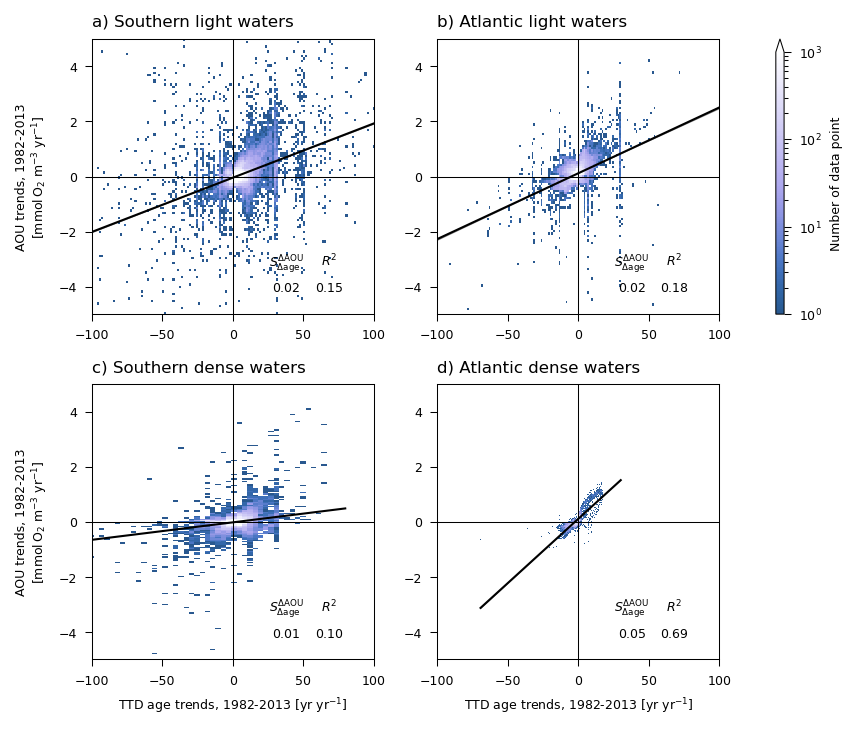

In [108]:
%%time
# %%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in TS space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Plot: scatter plot for TTD age')
print('################################')

#____________________
# Load data2plot

simu = 'historical'
tperiod = '1982-2013'
savefile = dirout + 'data2plot_aou_trend_vs_ttdage_trend_in_geo_space_'+simu+'_'+tperiod+'.pckl'
# Open the pickle file in binary read mode
with open(savefile, 'rb') as file:
    # Load the dictionary from the pickle file
    data2plot = pickle.load(file)
#

#--------------------
# Figure parameters
#--------------------

#____________________
# figname
figname = savefile.replace('data2plot', 'scatter_plot').replace('.pckl', '.png')

#____________________
# list
wm_list = ['southern_light', 'atlantic_light', 'southern_dense', 'atlantic_dense']

#____________________
# Figure
fwidth_cm, fheight_cm = 12, 12
nrow, ncol = 2, 2
fsize = (fwidth_cm*cm2in, fheight_cm*cm2in) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, squeeze=False)

#____________________
# labels
region_label_dict = {
    'southern_dense': 'Southern dense waters', 
    'southern_light': 'Southern light waters', 
    'atlantic_dense': 'Atlantic dense waters', 
    'atlantic_light': 'Atlantic light waters', 
}
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]


#______________
# cmap
a = cmcrameri.cm.devon
colors = a(np.linspace(0,1,200))
newcmap = ListedColormap(colors[50:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[49])
newcmap.set_bad("none")

# a = cm.Wistia
# colors = a(np.linspace(0,1,300))
# newcmap = ListedColormap(colors[30:-1])
# newcmap.set_over(colors[-1])
# newcmap.set_under(colors[29])
# newcmap.set_bad("none")

#____________________
# keywords args
kwpcm = {
    'southern_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern and atlantic': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'total': dict(cmap=ListedColormap(['#D3D3D3']), norm=mpl.colors.LogNorm(vmin=1, vmax=1000))
}


xlim = (-100, 100)
ylim = (-5,  5)

#--------------------
# Plot
#--------------------

pcm = np.zeros_like(ax)
for iwm, vwm in enumerate(wm_list): 
    
    zax = ax.flat[iwm]
    zax.axhline(0, lw=.5, c='k')
    zax.axvline(0, lw=.5, c='k')
    ttl = alphabet_reverse.pop()+') '+region_label_dict[vwm]
    zax.set_title(ttl, loc='left')
    zax.set_xlim(xlim)
    zax.set_ylim(ylim)

    #____________________
    # Selected scatter plot

    xxx = data2plot[vwm]['histogram2d']['xxx']
    yyy = data2plot[vwm]['histogram2d']['yyy']
    ccc = data2plot[vwm]['histogram2d']['ccc']
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm[vwm])
    pcm.flat[iwm] = zwpcm

    #____________________
    # Add regression line
    lines = []
    tab_col1 = []
    tab_col2 = []

    xxx = data2plot[vwm]['linregress']['sampled_X']
    yyy = data2plot[vwm]['linregress']['sampled_Y_predicted']
    yyymin = data2plot[vwm]['linregress']['lower_band']
    yyymax = data2plot[vwm]['linregress']['upper_band']

    zax.fill_between(xxx, yyymin, yyymax, color='k', alpha=0.5, lw=0)
    ll, = zax.plot(xxx, yyy, color='k', lw=1)
    lines.append(ll)
                
    #____________________
    # Save some notes for table
    slope = data2plot[vwm]['linregress']['slope']
    rvalue = data2plot[vwm]['linregress']['rvalue']
    pvalue = data2plot[vwm]['linregress']['pvalue']
    tab_col2.append(f'{np.floor(rvalue**2*100)/100:.2f}')
    tab_col1.append(f'{slope:.2f}')
    print(f">>> {vesm}, {vwm}: {data2plot[vwm]['linregress']['pvalue']:.3f}")
        
    #____________________
    # add notes
    kwtext = dict(ha='center', va='center_baseline', fontsize=6)
    ytxt = .2 #.97
    xtxt1 = .6+.09
    xtxt2 = xtxt1+.15
    # xtxt3 = xtxt2+.15
    zax.text(xtxt1, ytxt, r'$S_{\mathrm{\Delta age}}^{\mathrm{\Delta AOU}}$', transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, '$R^2$'    , transform=zax.transAxes, color='k', **kwtext)
    ytxt-=.1
    zax.text(xtxt1, ytxt, tab_col1[0], transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, tab_col2[0], transform=zax.transAxes, color='k', **kwtext)
    
#

fig.tight_layout()
        
#--------------------
# Decorate
#--------------------

#____________________
# axis labels
xlab = f'TTD age trends, {tperiod} '+r'[yr yr$^{-1}$]'
ylab = f'AOU trends, {tperiod}\n'+r'[mmol$\,$O$_2$ m$^{-3}$ yr$^{-1}$]'
for zax in ax[-1, :]: zax.set_xlabel(xlab)
for zax in ax[:, 0]: zax.set_ylabel(ylab)

#---------------------
# Colorbar
#---------------------

zw1 = ax[0, -1].get_position()
nx0 = zw1.x1 + .2*zw1.width
ny0 = zw1.y0
nh  = zw1.height
nw  = 0.03*nh
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='vertical', \
                    ticklocation='right', extend='max')
cbar.set_label(r'Number of data point')

#--------------------
# Save figure
#--------------------

print('Save figure...')
fig.savefig(figname, bbox_inches='tight')
print('Figure saved: '+figname)


print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

### Prepare data2plot for ideal age

In [109]:
%%time
%%memit -c
# ca. 40sec
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in geographical space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Prepare data2plot for ideal age')
print('################################')

vesm = 'NorESM2-LM'
simu = 'historical'
tperiod = '1982-2013'

zfact_esm_aou = 1000. # mol.m-3 to mmol.m-3 = umol.l-1

number_of_years_in_picontrol = 2099-1850

data2plot = {}
    
#----------------
# Get data
#----------------

#_________________
# Get aou data
print('Get aou data...')    
fname = netcdfdir+vesm+'_'+simu+'_'+'aou_linregress_on_'+tperiod+'_drift_removed_fitting_ttdage_finite_values.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_aou = zwds['slope']*zfact_esm_aou 
zwda_aou_pval = zwds['pvalue']

#_________________
# Get age data
print('Get age data...')    
fname = netcdfdir+vesm+'_'+simu+'_'+'agessc_linregress_on_'+tperiod+'_drift_removed_fitting_ttdage_finite_values.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_age = zwds['slope'] # yr.yr-1
zwda_age_pval = zwds['pvalue']

#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#----------------
# Compute volume
#----------------
print('Compute volume and omask...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello']
# FOR MPI model, invert latitude dimension
if vesm == 'MPI-ESM1-2-LR' : 
    zarea = zarea.isel(j=slice(None, None, -1))
#

depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)

omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

del depbounds, depthickness
   
#----------------
# Get PO-tracer threshold for water mass definition
#----------------

print('Get PO-tracer threshold for water mass definition...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#----------------
# Define water mass
#----------------

print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

# COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 80) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])

COND_watermass_dict = {
    'total'         : COND_total,
    'deep'          : COND_deep, 
    'southern_dense': COND_southern_dense,
    'southern_light': COND_southern_light,
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
}


#----------------
# Loop on water masses
#----------------

for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
        
    #_________________
    # Entire water mass
    data2plot[watermass_name+'_all'] = prep_data2plot_geospace(zwda_aou, zwda_age, watermass_cond, volume, omask)
    
    #_________________
    # Get only significant trends
    COND_signif = watermass_cond & (zwda_aou_pval<=.05) & (zwda_age_pval<=.05)
    data2plot[watermass_name] = prep_data2plot_geospace(zwda_aou, zwda_age, COND_signif, volume, omask)
    
#

#_________________
# Save
print('Save file...')
savefile = dirout + 'data2plot_aou_trend_vs_idealage_trend_in_geo_space_'+simu+'_'+tperiod+'.pckl'
with open(savefile, "wb") as file:
    pickle.dump(data2plot, file)
#
print('File saved: '+savefile)

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')


################################
################################
2025-12-10 14:47:22.641907
# Analysis in geographical space
## Scatter plot ∆AOU vs ∆age and linear regression
### Prepare data2plot for ideal age
################################
Get aou data...
Get age data...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Compute volume and omask...
Get PO-tracer threshold for water mass definition...
Define water mass...
For watermass: total...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute volume and number of cell
>> Compute histogram 2D
>> Compute linear regression...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute volume and number of cell
>> Compute histogram 2D
>> Compute linear regression...
For watermass: deep...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute volume and number of cell
>> Compute histogram 2D
>> Compute linear regression...
> prep_data2plot_geospace...
>> Select water mass...
>> Compute vo

### Plot: scatter plot for ideal age

################################
################################
2025-12-10 19:17:52.019387
# Analysis in TS space
## Scatter plot ∆AOU vs ∆age and linear regression
### Plot: scatter plot for ideal age
################################
>>> NorESM2-LM, southern_light: 0.000
>>> NorESM2-LM, atlantic_light: 0.000
>>> NorESM2-LM, southern_dense: 0.000
>>> NorESM2-LM, atlantic_dense: 0.000
Save figure...
Figure saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/scatter_plot_aou_trend_vs_idealage_trend_in_geo_space_historical_1982-2013.png
################################
Done:  2025-12-10 19:17:52.698466
################################
################################
CPU times: user 757 ms, sys: 808 ms, total: 1.57 s
Wall time: 679 ms


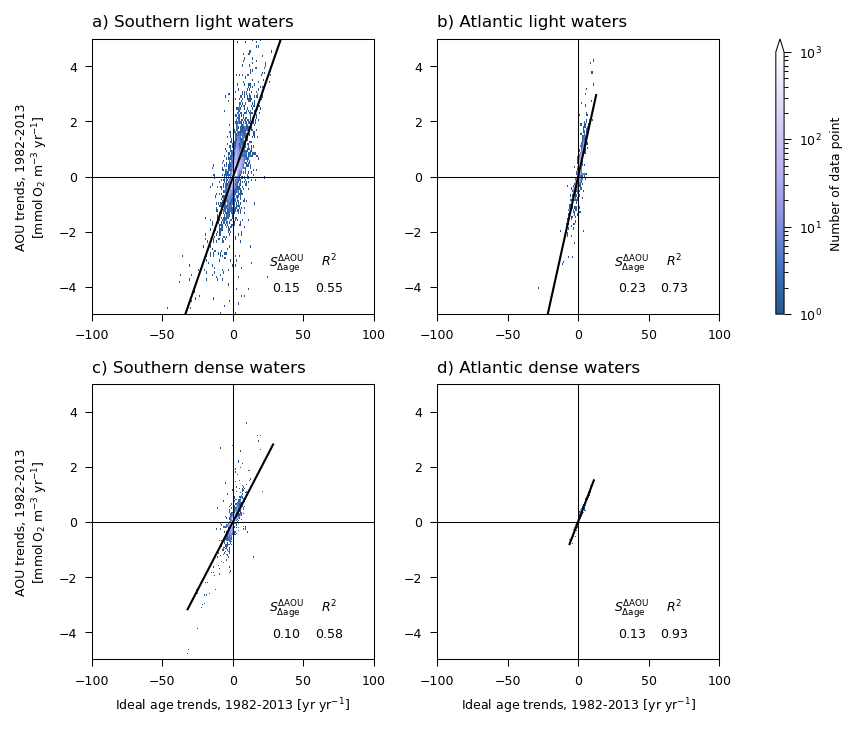

In [111]:
%%time
# %%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in TS space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Plot: scatter plot for ideal age')
print('################################')

#____________________
# Load data2plot

simu = 'historical'
tperiod = '1982-2013'
savefile = dirout + 'data2plot_aou_trend_vs_idealage_trend_in_geo_space_'+simu+'_'+tperiod+'.pckl'
# Open the pickle file in binary read mode
with open(savefile, 'rb') as file:
    # Load the dictionary from the pickle file
    data2plot = pickle.load(file)
#

#--------------------
# Figure parameters
#--------------------

#____________________
# figname
figname = savefile.replace('data2plot', 'scatter_plot').replace('.pckl', '.png')

#____________________
# list
wm_list = ['southern_light', 'atlantic_light', 'southern_dense', 'atlantic_dense']

#____________________
# Figure
fwidth_cm, fheight_cm = 12, 12
nrow, ncol = 2, 2
fsize = (fwidth_cm*cm2in, fheight_cm*cm2in) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, squeeze=False)

#____________________
# labels
region_label_dict = {
    'southern_dense': 'Southern dense waters', 
    'southern_light': 'Southern light waters', 
    'atlantic_dense': 'Atlantic dense waters', 
    'atlantic_light': 'Atlantic light waters', 
}
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]


#______________
# cmap
a = cmcrameri.cm.devon
colors = a(np.linspace(0,1,200))
newcmap = ListedColormap(colors[50:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[49])
newcmap.set_bad("none")

# a = cm.Wistia
# colors = a(np.linspace(0,1,300))
# newcmap = ListedColormap(colors[30:-1])
# newcmap.set_over(colors[-1])
# newcmap.set_under(colors[29])
# newcmap.set_bad("none")

#____________________
# keywords args
kwpcm = {
    'southern_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern and atlantic': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'total': dict(cmap=ListedColormap(['#D3D3D3']), norm=mpl.colors.LogNorm(vmin=1, vmax=1000))
}


xlim = (-100, 100)
ylim = (-5,  5)

#--------------------
# Plot
#--------------------

pcm = np.zeros_like(ax)
for iwm, vwm in enumerate(wm_list): 
    
    zax = ax.flat[iwm]
    zax.axhline(0, lw=.5, c='k')
    zax.axvline(0, lw=.5, c='k')
    ttl = alphabet_reverse.pop()+') '+region_label_dict[vwm]
    zax.set_title(ttl, loc='left')
    zax.set_xlim(xlim)
    zax.set_ylim(ylim)

    #____________________
    # Selected scatter plot

    xxx = data2plot[vwm]['histogram2d']['xxx']
    yyy = data2plot[vwm]['histogram2d']['yyy']
    ccc = data2plot[vwm]['histogram2d']['ccc']
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm[vwm])
    pcm.flat[iwm] = zwpcm

    #____________________
    # Add regression line
    lines = []
    tab_col1 = []
    tab_col2 = []

    xxx = data2plot[vwm]['linregress']['sampled_X']
    yyy = data2plot[vwm]['linregress']['sampled_Y_predicted']
    yyymin = data2plot[vwm]['linregress']['lower_band']
    yyymax = data2plot[vwm]['linregress']['upper_band']

    zax.fill_between(xxx, yyymin, yyymax, color='k', alpha=0.5, lw=0)
    ll, = zax.plot(xxx, yyy, color='k', lw=1)
    lines.append(ll)
                
    #____________________
    # Save some notes for table
    slope = data2plot[vwm]['linregress']['slope']
    rvalue = data2plot[vwm]['linregress']['rvalue']
    tab_col2.append(f'{np.floor(rvalue**2*100)/100:.2f}')
    tab_col1.append(f'{slope:.2f}')
    print(f">>> {vesm}, {vwm}: {data2plot[vwm]['linregress']['pvalue']:.3f}")
        
    #____________________
    # add notes
    kwtext = dict(ha='center', va='center_baseline', fontsize=6)
    ytxt = .2 #.97
    xtxt1 = .6+.09
    xtxt2 = xtxt1+.15
    zax.text(xtxt1, ytxt, r'$S_{\mathrm{\Delta age}}^{\mathrm{\Delta AOU}}$', transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, '$R^2$'    , transform=zax.transAxes, color='k', **kwtext)
    ytxt-=.1
    zax.text(xtxt1, ytxt, tab_col1[0], transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, tab_col2[0], transform=zax.transAxes, color='k', **kwtext)
    
#

fig.tight_layout()
        
#--------------------
# Decorate
#--------------------

#____________________
# axis labels
xlab = f'Ideal age trends, {tperiod} '+r'[yr yr$^{-1}$]'
ylab = f'AOU trends, {tperiod}\n'+r'[mmol$\,$O$_2$ m$^{-3}$ yr$^{-1}$]'
for zax in ax[-1, :]: zax.set_xlabel(xlab)
for zax in ax[:, 0]: zax.set_ylabel(ylab)

#---------------------
# Colorbar
#---------------------

zw1 = ax[0, -1].get_position()
nx0 = zw1.x1 + .2*zw1.width
ny0 = zw1.y0
nh  = zw1.height
nw  = 0.03*nh
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='vertical', \
                    ticklocation='right', extend='max')
cbar.set_label(r'Number of data point')

#--------------------
# Save figure
#--------------------

print('Save figure...')
fig.savefig(figname, bbox_inches='tight')
print('Figure saved: '+figname)


print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

# Analysis in TS space

## Compute trends in ttd-age in TS space    
    - Load temperature, salinity, ttd-age
    - Load average PO-tracer and density
    - Define water-mass
    - Extract temperature, salinity, ttd-age in water-mass
    - Transform in pandas and drop nans
    - Define temperature and salinity bins
    - In each bins compute the regression year vs and ttd-age to get the trends.
    
    

In [13]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Analysis in TS space')
print('## Compute trends in ttd-age in TS space')


vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2013)
# tslice = slice('1972', '1975')

MAIN_VAR = 'mageF12'

picontrol_refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600, 
    'CNRM-ESM2-1'  : 1850, 
    'GFDL-CM4'     :  101,
    'GFDL-ESM4'    :  101,
    'UKESM1-0-LL'  : 2250
}

number_of_years = 2099-1850

print(f'>>> FOR {MAIN_VAR} <<<')

#----------------
# Prepare data to process within watermass
#----------------

#________________
# Get temperature, salinity, age, aou datas
print('Get temperature, salinity, age datas...')    

var = 'thetao'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_temp = zwds[var]

var = 'so'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_sali = zwds[var]

fname = netcdfdir + f'{vesm}_{simu}_{MAIN_VAR}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
zwds = xr.open_dataset(fname, **kwopends).sel(year=tslice)
zwda_XXX = zwds[MAIN_VAR]
zwda_XXX = zwda_XXX.where(np.isfinite(zwda_XXX))

#________________
# Save for later
ymin_XXX = int(np.min(zwda_XXX['year']))
ymax_XXX = int(np.max(zwda_XXX['year']))


#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#_________________
# Get area
print('Get area...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello'].load()

#_________________
# Get thresholds for water mass
print('Get thresholds...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#_________________
# Define water mass
print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

COND_atlantic0 = COND_deep & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])


#----------------
# Loop on watermass
#----------------

COND_watermass_dict = {
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
    # 'southern_dense': COND_southern_dense,
    # 'southern_light': COND_southern_light,
}

for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
    
    #_________________
    # Extract temperature and salinity in water mass
    print('    Extract temperature and salinity water mass...')

    zwda_temp_in_wm = zwda_temp.where(watermass_cond, np.nan)
    zwda_sali_in_wm = zwda_sali.where(watermass_cond, np.nan)

    zwda_XXX_in_wm  = zwda_XXX.where(watermass_cond, np.nan)

    #_________________
    # Transform in pandas and drop nans
    print('    Transform in pandas and drop nans...')

    zwdf_temp = zwda_temp_in_wm.to_dataframe().reset_index().dropna()
    zwdf_sali = zwda_sali_in_wm.to_dataframe().reset_index().dropna()

    zwdf_XXX  = zwda_XXX_in_wm.to_dataframe().reset_index().dropna()
    # Merge DataFrames
    zwdf = zwdf_temp.merge(zwdf_sali, on=['year', 'depth', 'latitude', 'longitude']).merge(zwdf_XXX, on=['year', 'depth', 'latitude', 'longitude'])

    zwdf = zwdf[['year', 'depth', 'latitude', 'longitude', 'thetao', 'so', MAIN_VAR]]

    #_________________
    # Define temperature and salinity bins
    print('    Define temperature and salinity bins...')

    T_binsize = .027
    S_binsize = .0023
    T_bins = np.arange(-2, 33, T_binsize)
    S_bins = np.arange(32, 42, S_binsize)
    lab_T_bins = .5*(T_bins[:-1]+T_bins[1:])
    lab_S_bins = .5*(S_bins[:-1]+S_bins[1:])
    # lab_temperature_bins = [f'{vvv:.0f}' for vvv in temperature_bins[:-1]]
    # lab_salinity_bins = [f'{vvv:.1f}' for vvv in salinity_bins[:-1]]

    # Use pd.cut to create the bins
    # zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins, labels=lab_T_bins)
    # zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins, labels=lab_S_bins)
    zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins)
    zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins)

    #_________________
    # In each TS-bins compute stuff
    print('    In each TS-bins compute stuff...')

    def TS_bin_func(group): 

        # number of point in each bin
        zwndata = group['year'].shape[0]

        # longest distance
        latmax = group['latitude'].max()
        latmin = group['latitude'].min()
        lonmax = group['longitude'].max()
        lonmin = group['longitude'].min()
        zwdistancemax = haversine(latmin, lonmin, latmax, lonmax)

        # distance to median position
        latmed = group['latitude'].median()
        lonmed = group['longitude'].median()
        zwdist = []
        for index, row in group.iterrows(): 
            zwdist.append(haversine(latmed, lonmed, row['latitude'], row['longitude']))
        #
        zwq9 = np.quantile(zwdist, .9)

        # linear_regression
        from scipy.stats import linregress
        xxx = np.array(group['year'])

        yyy1 = np.array(group[MAIN_VAR])

        if len(xxx)>1: 
            if np.all(xxx == xxx[0]):
                slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
            else:
                slope, intercept, r_value, p_value, std_err = linregress(xxx, yyy1)
            #
        else:
            slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
        #

        df_output = pd.Series({
            'ndata'        : zwndata, 
            'distance_max' : zwdistancemax,
            'q9_distance'  : zwq9,
            'slope'    : slope,
            'intercept': intercept,
            'r_value'  : r_value,
            'p_value'  : p_value,
            'std_err'  : std_err
        })

        return df_output
    #

    TS_bin_output = zwdf.groupby(['T_bins', 'S_bins']).apply(TS_bin_func).reset_index()

    #_________________
    # Reorganize into dataarray
    print('    Reorganize into dataarray...')

    def reorganize_in_dataarray(df, index='T_bins', columns='S_bins', values='ndata'): 
        # Create a pivot table to get a 2D grid for S_bins and T_bins
        pivot_table = df.pivot(index=index, columns=columns, values=values)

        # extract data from table
        columns_centers = pivot_table.columns.categories.mid
        index_centers = pivot_table.index.categories.mid
        datavalues = pivot_table.values

        # Create a DataArray
        data_array = xr.DataArray(
            data=datavalues,
            coords=[index_centers, columns_centers],
            dims=[index, columns]
        )
        return data_array
    #

    values_list = ['ndata', 'distance_max', 'q9_distance', 
                   'slope', 'intercept', 'r_value', 'p_value', 'std_err'
                  ]
    zwda_dict = {}
    for values in values_list: 
        zwda_dict[values] = reorganize_in_dataarray(TS_bin_output, values=values)
    #

    #_________________
    # Combine into Datasets
    zwtxt = f'Results from scipy.stats.linregress calculating a linear \
    least-squares regression of {var} against time. The dataset contains the following variables: \
    1) slope : Slope of the regression line. \
    2) intercept : Intercept of the regression line. \
    3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
        is equal to the coefficient of determination. \
    4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
        that the slope is zero, using Wald Test with t-distribution of \
        the test statistic. See `alternative` above for alternative \
        hypotheses. \
    5) stderr : Standard error of the estimated slope (gradient), under the \
        assumption of residual normality. \
    To compute the trend over years: trd = slope * years + intercept'

    dataset_XXX = xr.Dataset({
        'slope': zwda_dict['slope'],
        'intercept': zwda_dict['intercept'],
        'rvalue': zwda_dict['r_value'],
        'pvalue': zwda_dict['p_value'],
        'stderr': zwda_dict['std_err']
    })
    dataset_XXX.attrs['description'] = ' '.join(zwtxt.split())

    dataset_extra = xr.Dataset({
        'ndata': zwda_dict['ndata'], 
        'dmax': zwda_dict['distance_max'], 
        'q9': zwda_dict['q9_distance']
    })

    #_________________
    # Save in netcdf
    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_linregress_on_{int(ymin_XXX):04d}-{int(ymax_XXX):04d}_in_ts_space_{watermass_name}.nc'
    dataset_XXX.to_netcdf(ncname)
    print('    File saved: %s'%ncname)

    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_output_distribution_in_ts_space_{watermass_name}.nc'
    dataset_extra.to_netcdf(ncname)
    print('    File saved: %s'%ncname)
    
    del dataset_XXX, dataset_extra, zwda_dict, TS_bin_output, zwdf, 
    del zwdf_temp, zwdf_sali, zwdf_XXX, 
    del zwda_temp_in_wm, zwda_sali_in_wm, zwda_XXX_in_wm
    gc.collect()
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-12-04 09:38:56.543518
################################
# Analysis in TS space
## Compute trends in ttd-age in TS space
>>> FOR mageF12 <<<
Get temperature, salinity, age datas...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Get area...
Get thresholds...
Define water mass...
For watermass: atlantic_dense...
    Extract temperature and salinity water mass...
    Transform in pandas and drop nans...
    Define temperature and salinity bins...
    In each TS-bins compute stuff...
    Reorganize into dataarray...
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_mageF12_linregress_on_1982-2013_in_ts_space_atlantic_dense.nc
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_mageF12_output_distribution_in_ts_space_atlantic_dense.nc
For watermass: atlantic_light

## Compute trends in AOU in TS space fitting ttd-age finite values
    - Load temperature, salinity, ttd-age
    - Load average PO-tracer and density
    - Define water-mass
    - Extract temperature, salinity, ttd-age in water-mass
    - Transform in pandas and drop nans
    - Define temperature and salinity bins
    - In each bins compute the regression year vs and ttd-age to get the trends.
    
    

In [11]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Analysis in TS space')
print('## Compute trends in AOU in TS space fitting ttd-age finite values')


vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2013)
# tslice = slice('1972', '1975')

MAIN_VAR = 'aou'

picontrol_refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600, 
    'CNRM-ESM2-1'  : 1850, 
    'GFDL-CM4'     :  101,
    'GFDL-ESM4'    :  101,
    'UKESM1-0-LL'  : 2250
}

number_of_years = 2099-1850

print(f'>>> FOR {MAIN_VAR} <<<')

#----------------
# Prepare data to process within watermass
#----------------

#________________
# Get temperature, salinity, age, aou datas
print('Get temperature, salinity, age datas...')    

var = 'thetao'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_temp = zwds[var]

var = 'so'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_sali = zwds[var]

fname_list = [f"{dirshared}{vesm}_{simu}_{MAIN_VAR}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_XXX = zwds[MAIN_VAR]

#________________
# Get age and aou drifts and remove it
print('Get drift and remove it...')

tperiod_drift = f'{picontrol_refyear_dict[vesm]:04d}-{picontrol_refyear_dict[vesm]+number_of_years:04d}'
fname = dirshared+vesm+'_piControl_'+MAIN_VAR+'_linregress_on_'+tperiod_drift+'.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_XXX_drift_slope = zwds['slope']

year = zwda_XXX.year
zwda_XXX_drift = (year - year[0])*zwda_XXX_drift_slope
for zwcoords in zwda_XXX.coords : 
    if zwcoords in zwda_XXX_drift.coords: zwda_XXX_drift[zwcoords] = zwda_XXX[zwcoords]
#
zwda_XXX = (zwda_XXX - zwda_XXX_drift).rename(zwda_XXX.name)

#________________
# Get finite values ttd-age and select aou
print('Get finite values ttd-age and select aou...')

var = 'mageF12'
fname = netcdfdir + f'{vesm}_{simu}_{var}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
zwds = xr.open_dataset(fname, **kwopends).sel(year=tslice)
zwda_ttdage = zwds[var]

zwda_XXX = zwda_XXX.where(np.isfinite(zwda_ttdage))

#________________
# Save for later
ymin_XXX = int(np.min(zwda_XXX['year']))
ymax_XXX = int(np.max(zwda_XXX['year']))


#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#_________________
# Get area
print('Get area...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello'].load()

#_________________
# Get thresholds for water mass
print('Get thresholds...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#_________________
# Define water mass
print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

COND_atlantic0 = COND_deep & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])


#----------------
# Loop on watermass
#----------------

COND_watermass_dict = {
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
    'southern_dense': COND_southern_dense,
    'southern_light': COND_southern_light,
}

for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
    
    #_________________
    # Extract temperature and salinity in water mass
    print('    Extract temperature and salinity water mass...')

    zwda_temp_in_wm = zwda_temp.where(watermass_cond, np.nan)
    zwda_sali_in_wm = zwda_sali.where(watermass_cond, np.nan)

    zwda_XXX_in_wm  = zwda_XXX.where(watermass_cond, np.nan)

    #_________________
    # Transform in pandas and drop nans
    print('    Transform in pandas and drop nans...')

    zwdf_temp = zwda_temp_in_wm.to_dataframe().reset_index().dropna()
    zwdf_sali = zwda_sali_in_wm.to_dataframe().reset_index().dropna()

    zwdf_XXX  = zwda_XXX_in_wm.to_dataframe().reset_index().dropna()
    # Merge DataFrames
    zwdf = zwdf_temp.merge(zwdf_sali, on=['year', 'depth', 'latitude', 'longitude']).merge(zwdf_XXX, on=['year', 'depth', 'latitude', 'longitude'])

    zwdf = zwdf[['year', 'depth', 'latitude', 'longitude', 'thetao', 'so', MAIN_VAR]]

    #_________________
    # Define temperature and salinity bins
    print('    Define temperature and salinity bins...')

    T_binsize = .027
    S_binsize = .0023
    T_bins = np.arange(-2, 33, T_binsize)
    S_bins = np.arange(32, 42, S_binsize)
    lab_T_bins = .5*(T_bins[:-1]+T_bins[1:])
    lab_S_bins = .5*(S_bins[:-1]+S_bins[1:])
    # lab_temperature_bins = [f'{vvv:.0f}' for vvv in temperature_bins[:-1]]
    # lab_salinity_bins = [f'{vvv:.1f}' for vvv in salinity_bins[:-1]]

    # Use pd.cut to create the bins
    # zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins, labels=lab_T_bins)
    # zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins, labels=lab_S_bins)
    zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins)
    zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins)

    #_________________
    # In each TS-bins compute stuff
    print('    In each TS-bins compute stuff...')

    def TS_bin_func(group): 

        # number of point in each bin
        zwndata = group['year'].shape[0]

        # longest distance
        latmax = group['latitude'].max()
        latmin = group['latitude'].min()
        lonmax = group['longitude'].max()
        lonmin = group['longitude'].min()
        zwdistancemax = haversine(latmin, lonmin, latmax, lonmax)

        # distance to median position
        latmed = group['latitude'].median()
        lonmed = group['longitude'].median()
        zwdist = []
        for index, row in group.iterrows(): 
            zwdist.append(haversine(latmed, lonmed, row['latitude'], row['longitude']))
        #
        zwq9 = np.quantile(zwdist, .9)

        # linear_regression
        from scipy.stats import linregress
        xxx = np.array(group['year'])

        yyy1 = np.array(group[MAIN_VAR])

        if len(xxx)>1: 
            if np.all(xxx == xxx[0]):
                slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
            else:
                slope, intercept, r_value, p_value, std_err = linregress(xxx, yyy1)
            #
        else:
            slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
        #

        df_output = pd.Series({
            'ndata'        : zwndata, 
            'distance_max' : zwdistancemax,
            'q9_distance'  : zwq9,
            'slope'    : slope,
            'intercept': intercept,
            'r_value'  : r_value,
            'p_value'  : p_value,
            'std_err'  : std_err
        })

        return df_output
    #

    TS_bin_output = zwdf.groupby(['T_bins', 'S_bins']).apply(TS_bin_func).reset_index()

    #_________________
    # Reorganize into dataarray
    print('    Reorganize into dataarray...')

    def reorganize_in_dataarray(df, index='T_bins', columns='S_bins', values='ndata'): 
        # Create a pivot table to get a 2D grid for S_bins and T_bins
        pivot_table = df.pivot(index=index, columns=columns, values=values)

        # extract data from table
        columns_centers = pivot_table.columns.categories.mid
        index_centers = pivot_table.index.categories.mid
        datavalues = pivot_table.values

        # Create a DataArray
        data_array = xr.DataArray(
            data=datavalues,
            coords=[index_centers, columns_centers],
            dims=[index, columns]
        )
        return data_array
    #

    values_list = ['ndata', 'distance_max', 'q9_distance', 
                   'slope', 'intercept', 'r_value', 'p_value', 'std_err'
                  ]
    zwda_dict = {}
    for values in values_list: 
        zwda_dict[values] = reorganize_in_dataarray(TS_bin_output, values=values)
    #

    #_________________
    # Combine into Datasets
    zwtxt = f'Results from scipy.stats.linregress calculating a linear \
    least-squares regression of {var} against time. The dataset contains the following variables: \
    1) slope : Slope of the regression line. \
    2) intercept : Intercept of the regression line. \
    3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
        is equal to the coefficient of determination. \
    4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
        that the slope is zero, using Wald Test with t-distribution of \
        the test statistic. See `alternative` above for alternative \
        hypotheses. \
    5) stderr : Standard error of the estimated slope (gradient), under the \
        assumption of residual normality. \
    To compute the trend over years: trd = slope * years + intercept'

    dataset_XXX = xr.Dataset({
        'slope': zwda_dict['slope'],
        'intercept': zwda_dict['intercept'],
        'rvalue': zwda_dict['r_value'],
        'pvalue': zwda_dict['p_value'],
        'stderr': zwda_dict['std_err']
    })
    dataset_XXX.attrs['description'] = ' '.join(zwtxt.split())

    dataset_extra = xr.Dataset({
        'ndata': zwda_dict['ndata'], 
        'dmax': zwda_dict['distance_max'], 
        'q9': zwda_dict['q9_distance']
    })

    #_________________
    # Save in netcdf
    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_linregress_on_{int(ymin_XXX):04d}-{int(ymax_XXX):04d}_drift_removed_in_ts_space_{watermass_name}_fitting_ttdage_finite_values.nc'
    dataset_XXX.to_netcdf(ncname)
    print('    File saved: %s'%ncname)

    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_output_distribution_in_ts_space_{watermass_name}_fitting_ttdage_finite_values.nc'
    dataset_extra.to_netcdf(ncname)
    print('    File saved: %s'%ncname)
    
    del dataset_XXX, dataset_extra, zwda_dict, TS_bin_output, zwdf, 
    del zwdf_temp, zwdf_sali, zwdf_XXX, 
    del zwda_temp_in_wm, zwda_sali_in_wm, zwda_XXX_in_wm
    gc.collect()
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-12-03 21:04:14.796766
################################
# Compute trends in AOU in TS space fitting ttd-age finite values
>>> FOR aou <<<
Get temperature, salinity, age datas...
Get drift and remove it...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Get area...
Get thresholds...
Define water mass...
For watermass: atlantic_dense...
    Extract temperature and salinity water mass...
    Transform in pandas and drop nans...
    Define temperature and salinity bins...
    In each TS-bins compute stuff...
    Reorganize into dataarray...
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_aou_linregress_on_1982-2013_drift_removed_in_ts_space_atlantic_dense_fitting_ttdage_finite_values.nc
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_aou_output_distribution

## Compute trends in ideal-age in TS space fitting ttd-age finite values
    - Load temperature, salinity, ttd-age
    - Load average PO-tracer and density
    - Define water-mass
    - Extract temperature, salinity, ttd-age in water-mass
    - Transform in pandas and drop nans
    - Define temperature and salinity bins
    - In each bins compute the regression year vs and ttd-age to get the trends.
    
    

In [11]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Analysis in TS space')
print('## Compute trends in ttd-age in TS space fitting ttd-age finite  values')


vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2013)
# tslice = slice('1972', '1975')

MAIN_VAR = 'agessc'

picontrol_refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600, 
    'CNRM-ESM2-1'  : 1850, 
    'GFDL-CM4'     :  101,
    'GFDL-ESM4'    :  101,
    'UKESM1-0-LL'  : 2250
}

number_of_years = 2099-1850

print(f'>>> FOR {MAIN_VAR} <<<')

#----------------
# Prepare data to process within watermass
#----------------

#________________
# Get temperature, salinity, age, aou datas
print('Get temperature, salinity, age datas...')    

var = 'thetao'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_temp = zwds[var]

var = 'so'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_sali = zwds[var]

fname_list = [f"{dirshared}{vesm}_{simu}_{MAIN_VAR}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_XXX = zwds[MAIN_VAR]

#________________
# Get age and aou drifts and remove it
print('Get drift and remove it...')

tperiod_drift = f'{picontrol_refyear_dict[vesm]:04d}-{picontrol_refyear_dict[vesm]+number_of_years:04d}'
fname = dirshared+vesm+'_piControl_'+MAIN_VAR+'_linregress_on_'+tperiod_drift+'.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_XXX_drift_slope = zwds['slope']

year = zwda_XXX.year
zwda_XXX_drift = (year - year[0])*zwda_XXX_drift_slope
for zwcoords in zwda_XXX.coords : 
    if zwcoords in zwda_XXX_drift.coords: zwda_XXX_drift[zwcoords] = zwda_XXX[zwcoords]
#
zwda_XXX = (zwda_XXX - zwda_XXX_drift).rename(zwda_XXX.name)

#________________
# Get finite values ttd-age and select aou
print('Get finite values ttd-age and select aou...')

var = 'mageF12'
fname = netcdfdir + f'{vesm}_{simu}_{var}_{int(tslice.start):04}-{int(tslice.stop):04}.nc'
zwds = xr.open_dataset(fname, **kwopends).sel(year=tslice)
zwda_ttdage = zwds[var]

zwda_XXX = zwda_XXX.where(np.isfinite(zwda_ttdage))


#________________
# Save for later
ymin_XXX = int(np.min(zwda_XXX['year']))
ymax_XXX = int(np.max(zwda_XXX['year']))


#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#_________________
# Get area
print('Get area...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello'].load()

#_________________
# Get thresholds for water mass
print('Get thresholds...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#_________________
# Define water mass
print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

COND_atlantic0 = COND_deep & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])


#----------------
# Loop on watermass
#----------------

COND_watermass_dict = {
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
    'southern_dense': COND_southern_dense,
    'southern_light': COND_southern_light,
}

for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
    
    #_________________
    # Extract temperature and salinity in water mass
    print('    Extract temperature and salinity water mass...')

    zwda_temp_in_wm = zwda_temp.where(watermass_cond, np.nan)
    zwda_sali_in_wm = zwda_sali.where(watermass_cond, np.nan)

    zwda_XXX_in_wm  = zwda_XXX.where(watermass_cond, np.nan)

    #_________________
    # Transform in pandas and drop nans
    print('    Transform in pandas and drop nans...')

    zwdf_temp = zwda_temp_in_wm.to_dataframe().reset_index().dropna()
    zwdf_sali = zwda_sali_in_wm.to_dataframe().reset_index().dropna()

    zwdf_XXX  = zwda_XXX_in_wm.to_dataframe().reset_index().dropna()
    # Merge DataFrames
    zwdf = zwdf_temp.merge(zwdf_sali, on=['year', 'depth', 'latitude', 'longitude']).merge(zwdf_XXX, on=['year', 'depth', 'latitude', 'longitude'])

    zwdf = zwdf[['year', 'depth', 'latitude', 'longitude', 'thetao', 'so', MAIN_VAR]]

    #_________________
    # Define temperature and salinity bins
    print('    Define temperature and salinity bins...')

    T_binsize = .027
    S_binsize = .0023
    T_bins = np.arange(-2, 33, T_binsize)
    S_bins = np.arange(32, 42, S_binsize)
    lab_T_bins = .5*(T_bins[:-1]+T_bins[1:])
    lab_S_bins = .5*(S_bins[:-1]+S_bins[1:])
    # lab_temperature_bins = [f'{vvv:.0f}' for vvv in temperature_bins[:-1]]
    # lab_salinity_bins = [f'{vvv:.1f}' for vvv in salinity_bins[:-1]]

    # Use pd.cut to create the bins
    # zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins, labels=lab_T_bins)
    # zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins, labels=lab_S_bins)
    zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins)
    zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins)

    #_________________
    # In each TS-bins compute stuff
    print('    In each TS-bins compute stuff...')

    def TS_bin_func(group): 

        # number of point in each bin
        zwndata = group['year'].shape[0]

        # longest distance
        latmax = group['latitude'].max()
        latmin = group['latitude'].min()
        lonmax = group['longitude'].max()
        lonmin = group['longitude'].min()
        zwdistancemax = haversine(latmin, lonmin, latmax, lonmax)

        # distance to median position
        latmed = group['latitude'].median()
        lonmed = group['longitude'].median()
        zwdist = []
        for index, row in group.iterrows(): 
            zwdist.append(haversine(latmed, lonmed, row['latitude'], row['longitude']))
        #
        zwq9 = np.quantile(zwdist, .9)

        # linear_regression
        from scipy.stats import linregress
        xxx = np.array(group['year'])

        yyy1 = np.array(group[MAIN_VAR])

        if len(xxx)>1: 
            if np.all(xxx == xxx[0]):
                slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
            else:
                slope, intercept, r_value, p_value, std_err = linregress(xxx, yyy1)
            #
        else:
            slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
        #

        df_output = pd.Series({
            'ndata'        : zwndata, 
            'distance_max' : zwdistancemax,
            'q9_distance'  : zwq9,
            'slope'    : slope,
            'intercept': intercept,
            'r_value'  : r_value,
            'p_value'  : p_value,
            'std_err'  : std_err
        })

        return df_output
    #

    TS_bin_output = zwdf.groupby(['T_bins', 'S_bins']).apply(TS_bin_func).reset_index()

    #_________________
    # Reorganize into dataarray
    print('    Reorganize into dataarray...')

    def reorganize_in_dataarray(df, index='T_bins', columns='S_bins', values='ndata'): 
        # Create a pivot table to get a 2D grid for S_bins and T_bins
        pivot_table = df.pivot(index=index, columns=columns, values=values)

        # extract data from table
        columns_centers = pivot_table.columns.categories.mid
        index_centers = pivot_table.index.categories.mid
        datavalues = pivot_table.values

        # Create a DataArray
        data_array = xr.DataArray(
            data=datavalues,
            coords=[index_centers, columns_centers],
            dims=[index, columns]
        )
        return data_array
    #

    values_list = ['ndata', 'distance_max', 'q9_distance', 
                   'slope', 'intercept', 'r_value', 'p_value', 'std_err'
                  ]
    zwda_dict = {}
    for values in values_list: 
        zwda_dict[values] = reorganize_in_dataarray(TS_bin_output, values=values)
    #

    #_________________
    # Combine into Datasets
    zwtxt = f'Results from scipy.stats.linregress calculating a linear \
    least-squares regression of {var} against time. The dataset contains the following variables: \
    1) slope : Slope of the regression line. \
    2) intercept : Intercept of the regression line. \
    3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
        is equal to the coefficient of determination. \
    4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
        that the slope is zero, using Wald Test with t-distribution of \
        the test statistic. See `alternative` above for alternative \
        hypotheses. \
    5) stderr : Standard error of the estimated slope (gradient), under the \
        assumption of residual normality. \
    To compute the trend over years: trd = slope * years + intercept'

    dataset_XXX = xr.Dataset({
        'slope': zwda_dict['slope'],
        'intercept': zwda_dict['intercept'],
        'rvalue': zwda_dict['r_value'],
        'pvalue': zwda_dict['p_value'],
        'stderr': zwda_dict['std_err']
    })
    dataset_XXX.attrs['description'] = ' '.join(zwtxt.split())

    dataset_extra = xr.Dataset({
        'ndata': zwda_dict['ndata'], 
        'dmax': zwda_dict['distance_max'], 
        'q9': zwda_dict['q9_distance']
    })

    #_________________
    # Save in netcdf
    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_linregress_on_{int(ymin_XXX):04d}-{int(ymax_XXX):04d}_drift_removed_in_ts_space_{watermass_name}_fitting_ttdage_finite_values.nc'
    dataset_XXX.to_netcdf(ncname)
    print('    File saved: %s'%ncname)

    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_output_distribution_in_ts_space_{watermass_name}_fitting_ttdage_finite_values.nc'
    dataset_extra.to_netcdf(ncname)
    print('    File saved: %s'%ncname)
    
    del dataset_XXX, dataset_extra, zwda_dict, TS_bin_output, zwdf, 
    del zwdf_temp, zwdf_sali, zwdf_XXX, 
    del zwda_temp_in_wm, zwda_sali_in_wm, zwda_XXX_in_wm
    gc.collect()
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-11-25 16:17:33.186199
################################
# Compute trends in ttd-age in TS space
>>> FOR agessc <<<
Get temperature, salinity, age datas...
Get drift and remove it...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Get area...
Get thresholds...
Define water mass...
For watermass: atlantic_dense...
    Extract temperature and salinity water mass...
    Transform in pandas and drop nans...
    Define temperature and salinity bins...
    In each TS-bins compute stuff...
    Reorganize into dataarray...
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_agessc_linregress_on_1982-2013_in_ts_space_atlantic_dense.nc
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_agessc_output_distribution_in_ts_space_atlantic_dense.nc
For watermass: atlantic_light

## Compute trends in ideal-age in TS space
    - Load temperature, salinity, ttd-age
    - Load average PO-tracer and density
    - Define water-mass
    - Extract temperature, salinity, ttd-age in water-mass
    - Transform in pandas and drop nans
    - Define temperature and salinity bins
    - In each bins compute the regression year vs and ttd-age to get the trends.
    
    

In [11]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Analysis in TS space')
print('## Compute trends in ttd-age in TS space')


vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2013)
# tslice = slice('1972', '1975')

MAIN_VAR = 'agessc'

picontrol_refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600, 
    'CNRM-ESM2-1'  : 1850, 
    'GFDL-CM4'     :  101,
    'GFDL-ESM4'    :  101,
    'UKESM1-0-LL'  : 2250
}

number_of_years = 2099-1850

print(f'>>> FOR {MAIN_VAR} <<<')

#----------------
# Prepare data to process within watermass
#----------------

#________________
# Get temperature, salinity, age, aou datas
print('Get temperature, salinity, age datas...')    

var = 'thetao'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_temp = zwds[var]

var = 'so'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_sali = zwds[var]

fname_list = [f"{dirshared}{vesm}_{simu}_{MAIN_VAR}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_XXX = zwds[MAIN_VAR]

#________________
# Get age and aou drifts and remove it
print('Get drift and remove it...')

tperiod_drift = f'{picontrol_refyear_dict[vesm]:04d}-{picontrol_refyear_dict[vesm]+number_of_years:04d}'
fname = dirshared+vesm+'_piControl_'+MAIN_VAR+'_linregress_on_'+tperiod_drift+'.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_XXX_drift_slope = zwds['slope']

year = zwda_XXX.year
zwda_XXX_drift = (year - year[0])*zwda_XXX_drift_slope
for zwcoords in zwda_XXX.coords : 
    if zwcoords in zwda_XXX_drift.coords: zwda_XXX_drift[zwcoords] = zwda_XXX[zwcoords]
#
zwda_XXX = (zwda_XXX - zwda_XXX_drift).rename(zwda_XXX.name)

#________________
# Save for later
ymin_XXX = int(np.min(zwda_XXX['year']))
ymax_XXX = int(np.max(zwda_XXX['year']))


#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#_________________
# Get area
print('Get area...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello'].load()

#_________________
# Get thresholds for water mass
print('Get thresholds...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#_________________
# Define water mass
print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

COND_atlantic0 = COND_deep & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])


#----------------
# Loop on watermass
#----------------

COND_watermass_dict = {
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
    'southern_dense': COND_southern_dense,
    'southern_light': COND_southern_light,
}

for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
    
    #_________________
    # Extract temperature and salinity in water mass
    print('    Extract temperature and salinity water mass...')

    zwda_temp_in_wm = zwda_temp.where(watermass_cond, np.nan)
    zwda_sali_in_wm = zwda_sali.where(watermass_cond, np.nan)

    zwda_XXX_in_wm  = zwda_XXX.where(watermass_cond, np.nan)

    #_________________
    # Transform in pandas and drop nans
    print('    Transform in pandas and drop nans...')

    zwdf_temp = zwda_temp_in_wm.to_dataframe().reset_index().dropna()
    zwdf_sali = zwda_sali_in_wm.to_dataframe().reset_index().dropna()

    zwdf_XXX  = zwda_XXX_in_wm.to_dataframe().reset_index().dropna()
    # Merge DataFrames
    zwdf = zwdf_temp.merge(zwdf_sali, on=['year', 'depth', 'latitude', 'longitude']).merge(zwdf_XXX, on=['year', 'depth', 'latitude', 'longitude'])

    zwdf = zwdf[['year', 'depth', 'latitude', 'longitude', 'thetao', 'so', MAIN_VAR]]

    #_________________
    # Define temperature and salinity bins
    print('    Define temperature and salinity bins...')

    T_binsize = .027
    S_binsize = .0023
    T_bins = np.arange(-2, 33, T_binsize)
    S_bins = np.arange(32, 42, S_binsize)
    lab_T_bins = .5*(T_bins[:-1]+T_bins[1:])
    lab_S_bins = .5*(S_bins[:-1]+S_bins[1:])
    # lab_temperature_bins = [f'{vvv:.0f}' for vvv in temperature_bins[:-1]]
    # lab_salinity_bins = [f'{vvv:.1f}' for vvv in salinity_bins[:-1]]

    # Use pd.cut to create the bins
    # zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins, labels=lab_T_bins)
    # zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins, labels=lab_S_bins)
    zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins)
    zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins)

    #_________________
    # In each TS-bins compute stuff
    print('    In each TS-bins compute stuff...')

    def TS_bin_func(group): 

        # number of point in each bin
        zwndata = group['year'].shape[0]

        # longest distance
        latmax = group['latitude'].max()
        latmin = group['latitude'].min()
        lonmax = group['longitude'].max()
        lonmin = group['longitude'].min()
        zwdistancemax = haversine(latmin, lonmin, latmax, lonmax)

        # distance to median position
        latmed = group['latitude'].median()
        lonmed = group['longitude'].median()
        zwdist = []
        for index, row in group.iterrows(): 
            zwdist.append(haversine(latmed, lonmed, row['latitude'], row['longitude']))
        #
        zwq9 = np.quantile(zwdist, .9)

        # linear_regression
        from scipy.stats import linregress
        xxx = np.array(group['year'])

        yyy1 = np.array(group[MAIN_VAR])

        if len(xxx)>1: 
            if np.all(xxx == xxx[0]):
                slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
            else:
                slope, intercept, r_value, p_value, std_err = linregress(xxx, yyy1)
            #
        else:
            slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
        #

        df_output = pd.Series({
            'ndata'        : zwndata, 
            'distance_max' : zwdistancemax,
            'q9_distance'  : zwq9,
            'slope'    : slope,
            'intercept': intercept,
            'r_value'  : r_value,
            'p_value'  : p_value,
            'std_err'  : std_err
        })

        return df_output
    #

    TS_bin_output = zwdf.groupby(['T_bins', 'S_bins']).apply(TS_bin_func).reset_index()

    #_________________
    # Reorganize into dataarray
    print('    Reorganize into dataarray...')

    def reorganize_in_dataarray(df, index='T_bins', columns='S_bins', values='ndata'): 
        # Create a pivot table to get a 2D grid for S_bins and T_bins
        pivot_table = df.pivot(index=index, columns=columns, values=values)

        # extract data from table
        columns_centers = pivot_table.columns.categories.mid
        index_centers = pivot_table.index.categories.mid
        datavalues = pivot_table.values

        # Create a DataArray
        data_array = xr.DataArray(
            data=datavalues,
            coords=[index_centers, columns_centers],
            dims=[index, columns]
        )
        return data_array
    #

    values_list = ['ndata', 'distance_max', 'q9_distance', 
                   'slope', 'intercept', 'r_value', 'p_value', 'std_err'
                  ]
    zwda_dict = {}
    for values in values_list: 
        zwda_dict[values] = reorganize_in_dataarray(TS_bin_output, values=values)
    #

    #_________________
    # Combine into Datasets
    zwtxt = f'Results from scipy.stats.linregress calculating a linear \
    least-squares regression of {var} against time. The dataset contains the following variables: \
    1) slope : Slope of the regression line. \
    2) intercept : Intercept of the regression line. \
    3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
        is equal to the coefficient of determination. \
    4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
        that the slope is zero, using Wald Test with t-distribution of \
        the test statistic. See `alternative` above for alternative \
        hypotheses. \
    5) stderr : Standard error of the estimated slope (gradient), under the \
        assumption of residual normality. \
    To compute the trend over years: trd = slope * years + intercept'

    dataset_XXX = xr.Dataset({
        'slope': zwda_dict['slope'],
        'intercept': zwda_dict['intercept'],
        'rvalue': zwda_dict['r_value'],
        'pvalue': zwda_dict['p_value'],
        'stderr': zwda_dict['std_err']
    })
    dataset_XXX.attrs['description'] = ' '.join(zwtxt.split())

    dataset_extra = xr.Dataset({
        'ndata': zwda_dict['ndata'], 
        'dmax': zwda_dict['distance_max'], 
        'q9': zwda_dict['q9_distance']
    })

    #_________________
    # Save in netcdf
    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_linregress_on_{int(ymin_XXX):04d}-{int(ymax_XXX):04d}_drift_removed_in_ts_space_{watermass_name}.nc'
    dataset_XXX.to_netcdf(ncname)
    print('    File saved: %s'%ncname)

    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_output_distribution_in_ts_space_{watermass_name}.nc'
    dataset_extra.to_netcdf(ncname)
    print('    File saved: %s'%ncname)
    
    del dataset_XXX, dataset_extra, zwda_dict, TS_bin_output, zwdf, 
    del zwdf_temp, zwdf_sali, zwdf_XXX, 
    del zwda_temp_in_wm, zwda_sali_in_wm, zwda_XXX_in_wm
    gc.collect()
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-11-25 16:17:33.186199
################################
# Compute trends in ttd-age in TS space
>>> FOR agessc <<<
Get temperature, salinity, age datas...
Get drift and remove it...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Get area...
Get thresholds...
Define water mass...
For watermass: atlantic_dense...
    Extract temperature and salinity water mass...
    Transform in pandas and drop nans...
    Define temperature and salinity bins...
    In each TS-bins compute stuff...
    Reorganize into dataarray...
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_agessc_linregress_on_1982-2013_in_ts_space_atlantic_dense.nc
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_agessc_output_distribution_in_ts_space_atlantic_dense.nc
For watermass: atlantic_light

## Compute trends in AOU in TS space    
    - Load temperature, salinity, ttd-age
    - Load average PO-tracer and density
    - Define water-mass
    - Extract temperature, salinity, ttd-age in water-mass
    - Transform in pandas and drop nans
    - Define temperature and salinity bins
    - In each bins compute the regression year vs and ttd-age to get the trends.
    
    

In [ ]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Analysis in TS space')
print('## Compute trends in AOU in TS space')


vesm = 'NorESM2-LM'
simu = 'historical'
tslice = slice(1982, 2013)
# tslice = slice('1972', '1975')

MAIN_VAR = 'aou'

picontrol_refyear_dict = {
    'MPI-ESM1-2-LR': 1850,
    'ACCESS-ESM1-5':  161,
    'IPSL-CM6A-LR' : 1910,
    'CanESM5'      : 5201,
    'MIROC-ES2L'   : 1850,
    'NorESM2-LM'   : 1600, 
    'CNRM-ESM2-1'  : 1850, 
    'GFDL-CM4'     :  101,
    'GFDL-ESM4'    :  101,
    'UKESM1-0-LL'  : 2250
}

number_of_years = 2099-1850

print(f'>>> FOR {MAIN_VAR} <<<')

#----------------
# Prepare data to process within watermass
#----------------

#________________
# Get temperature, salinity, age, aou datas
print('Get temperature, salinity, age datas...')    

var = 'thetao'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
# fname = dirshared+vesm+"_"+simu+"_"+var+"_[0-9][0-9][0-9][0-9].nc"
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_temp = zwds[var]

var = 'so'
fname_list = [f"{dirshared}{vesm}_{simu}_{var}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_sali = zwds[var]

fname_list = [f"{dirshared}{vesm}_{simu}_{MAIN_VAR}_{int(year):04}.nc" for year in np.arange(int(tslice.start), int(tslice.stop)+.5)]
zwds = xr.open_mfdataset(fname_list, **kwopenmfds).sel(year=tslice)
zwda_XXX = zwds[MAIN_VAR]

#________________
# Get age and aou drifts and remove it
print('Get drift and remove it...')

tperiod_drift = f'{picontrol_refyear_dict[vesm]:04d}-{picontrol_refyear_dict[vesm]+number_of_years:04d}'
fname = dirshared+vesm+'_piControl_'+MAIN_VAR+'_linregress_on_'+tperiod_drift+'.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds)
zwda_XXX_drift_slope = zwds['slope']

year = zwda_XXX.year
zwda_XXX_drift = (year - year[0])*zwda_XXX_drift_slope
for zwcoords in zwda_XXX.coords : 
    if zwcoords in zwda_XXX_drift.coords: zwda_XXX_drift[zwcoords] = zwda_XXX[zwcoords]
#
zwda_XXX = (zwda_XXX - zwda_XXX_drift).rename(zwda_XXX.name)

#________________
# Save for later
ymin_XXX = int(np.min(zwda_XXX['year']))
ymax_XXX = int(np.max(zwda_XXX['year']))


#_________________
# Get po-tracer data
print('Get po-tracer data...')
fname = netcdfdir+vesm+'_historical_po_tracer_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in mol.m-3
zwda_pot = zwds['po-tracer']

#_________________
# Get density data
print('Get density data...')
fname = netcdfdir+vesm+'_historical_sigma0_average_on_1982-2013.nc'
zwds = xr.open_mfdataset(fname, **kwopenmfds) # in kg.m-3
zwda_sigma0 = zwds['sigma0'] + 1000.

#_________________
# Convert po-tracer units
print('Convert po-tracer units...')
zwda_pot = zwda_pot/zwda_sigma0.values*1e6 - 1.95 # umol kg-1
zwda_pot.attrs['units'] = 'umol kg-1'

#_________________
# Get area
print('Get area...')
if vesm == 'NorESM2-LM': fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', diresgf='/mnt/reef-ns1002k-ns9034k/', variant='r1i1p1f1')
else: fname_list = get_esgf_dataset_filepaths('areacello', vesm, 'historical', variant=variant_dict[vesm], 
                                              version=version_dict['historical']['areacello'][vesm], grid=grid_dict['areacello'][vesm])
zwds = xr.open_mfdataset(fname_list, **kwopenmfds)
zwds2 = zwds['areacello'].to_dataset()
zwds2 = rename_vars_dims_coords(zwds2, rename_dict)
zwds2 = split_coords_dimensions(zwds2)
zwds2 = shift_180_lon(zwds2)
zarea = zwds2['areacello'].load()

#_________________
# Get thresholds for water mass
print('Get thresholds...')

zwda_pot_deep = zwda_pot.where(zwda_pot.depth>=1000)

# Select Atlantic waters
COND = (zwda_pot.latitude<=60) & (zwda_pot.latitude>=40) & (zwda_pot.longitude>=-70) &  (zwda_pot.longitude<=0)
values1 = zwda_pot_deep.where(COND).values.flatten()
values1 = values1[~np.isnan(values1)]

# Select Southern waters
COND = (zwda_pot.latitude<-55) 
values2 = zwda_pot_deep.where(COND).values.flatten()
values2 = values2[~np.isnan(values2)]

nnn = 0.05
lll1=np.quantile(values1, 1-nnn)
lll2=np.quantile(values2, nnn)
PO_threshold = (lll1+lll2)/2 # Southern: PO-tracer > threshold, Atlantic: PO-tracer <= threshold

#_________________
# Define water mass
print('Define water mass...')

dep3D = expand_coords(zwda_sigma0, 'depth')
lat3D = expand_coords(zwda_sigma0, 'latitude')
lon3D = expand_coords(zwda_sigma0, 'longitude')
depbounds, depthickness = compute_vertical_bounds_thickness(zwda_sigma0.depth)
omask = ~(zwda_sigma0.isnull()).rename('mask')
volume = (omask * depthickness * zarea).compute()

COND_total = omask
COND_deep = COND_total & (dep3D > 1000)

COND_southern = COND_deep & (lat3D < 60) & (zwda_pot > PO_threshold)
quantiles_southern = weighted_quantile(values=zwda_sigma0.where(COND_southern, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_southern, np.nan).values.flatten())
COND_southern_dense = COND_southern & (zwda_sigma0 >= quantiles_southern[5])
COND_southern_light = COND_southern & (zwda_sigma0 < quantiles_southern[5])

COND_atlantic0 = COND_deep & (zwda_pot <= PO_threshold)
COND_atlantic = COND_deep & (lat3D < 60) & (lon3D>=-90) & (lon3D<=30) & (zwda_pot <= PO_threshold)

quantiles_atlantic = weighted_quantile(values=zwda_sigma0.where(COND_atlantic, np.nan).values.flatten(), quantiles=np.linspace(0, 1, 11), \
                                       sample_weight=volume.where(COND_atlantic, np.nan).values.flatten())
COND_atlantic_dense = COND_atlantic & (zwda_sigma0 >= quantiles_atlantic[5])
COND_atlantic_light = COND_atlantic & (zwda_sigma0 < quantiles_atlantic[5])


#----------------
# Loop on watermass
#----------------

COND_watermass_dict = {
    'atlantic_dense': COND_atlantic_dense,
    'atlantic_light': COND_atlantic_light,
    'southern_dense': COND_southern_dense,
    'southern_light': COND_southern_light,
}

for watermass_name, watermass_cond in COND_watermass_dict.items(): 
    
    print(f'For watermass: {watermass_name}...')
    
    #_________________
    # Extract temperature and salinity in water mass
    print('    Extract temperature and salinity water mass...')

    zwda_temp_in_wm = zwda_temp.where(watermass_cond, np.nan)
    zwda_sali_in_wm = zwda_sali.where(watermass_cond, np.nan)

    zwda_XXX_in_wm  = zwda_XXX.where(watermass_cond, np.nan)

    #_________________
    # Transform in pandas and drop nans
    print('    Transform in pandas and drop nans...')

    zwdf_temp = zwda_temp_in_wm.to_dataframe().reset_index().dropna()
    zwdf_sali = zwda_sali_in_wm.to_dataframe().reset_index().dropna()

    zwdf_XXX  = zwda_XXX_in_wm.to_dataframe().reset_index().dropna()
    # Merge DataFrames
    zwdf = zwdf_temp.merge(zwdf_sali, on=['year', 'depth', 'latitude', 'longitude']).merge(zwdf_XXX, on=['year', 'depth', 'latitude', 'longitude'])

    zwdf = zwdf[['year', 'depth', 'latitude', 'longitude', 'thetao', 'so', MAIN_VAR]]

    #_________________
    # Define temperature and salinity bins
    print('    Define temperature and salinity bins...')

    T_binsize = .027
    S_binsize = .0023
    T_bins = np.arange(-2, 33, T_binsize)
    S_bins = np.arange(32, 42, S_binsize)
    lab_T_bins = .5*(T_bins[:-1]+T_bins[1:])
    lab_S_bins = .5*(S_bins[:-1]+S_bins[1:])
    # lab_temperature_bins = [f'{vvv:.0f}' for vvv in temperature_bins[:-1]]
    # lab_salinity_bins = [f'{vvv:.1f}' for vvv in salinity_bins[:-1]]

    # Use pd.cut to create the bins
    # zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins, labels=lab_T_bins)
    # zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins, labels=lab_S_bins)
    zwdf['T_bins'] = pd.cut(zwdf['thetao'], bins=T_bins)
    zwdf['S_bins'] = pd.cut(zwdf['so'], bins=S_bins)

    #_________________
    # In each TS-bins compute stuff
    print('    In each TS-bins compute stuff...')

    def TS_bin_func(group): 

        # number of point in each bin
        zwndata = group['year'].shape[0]

        # longest distance
        latmax = group['latitude'].max()
        latmin = group['latitude'].min()
        lonmax = group['longitude'].max()
        lonmin = group['longitude'].min()
        zwdistancemax = haversine(latmin, lonmin, latmax, lonmax)

        # distance to median position
        latmed = group['latitude'].median()
        lonmed = group['longitude'].median()
        zwdist = []
        for index, row in group.iterrows(): 
            zwdist.append(haversine(latmed, lonmed, row['latitude'], row['longitude']))
        #
        zwq9 = np.quantile(zwdist, .9)

        # linear_regression
        from scipy.stats import linregress
        xxx = np.array(group['year'])

        yyy1 = np.array(group[MAIN_VAR])

        if len(xxx)>1: 
            if np.all(xxx == xxx[0]):
                slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
            else:
                slope, intercept, r_value, p_value, std_err = linregress(xxx, yyy1)
            #
        else:
            slope, intercept, r_value, p_value, std_err = np.nan, np.nan, np.nan, np.nan, np.nan
        #

        df_output = pd.Series({
            'ndata'        : zwndata, 
            'distance_max' : zwdistancemax,
            'q9_distance'  : zwq9,
            'slope'    : slope,
            'intercept': intercept,
            'r_value'  : r_value,
            'p_value'  : p_value,
            'std_err'  : std_err
        })

        return df_output
    #

    TS_bin_output = zwdf.groupby(['T_bins', 'S_bins']).apply(TS_bin_func).reset_index()

    #_________________
    # Reorganize into dataarray
    print('    Reorganize into dataarray...')

    def reorganize_in_dataarray(df, index='T_bins', columns='S_bins', values='ndata'): 
        # Create a pivot table to get a 2D grid for S_bins and T_bins
        pivot_table = df.pivot(index=index, columns=columns, values=values)

        # extract data from table
        columns_centers = pivot_table.columns.categories.mid
        index_centers = pivot_table.index.categories.mid
        datavalues = pivot_table.values

        # Create a DataArray
        data_array = xr.DataArray(
            data=datavalues,
            coords=[index_centers, columns_centers],
            dims=[index, columns]
        )
        return data_array
    #

    values_list = ['ndata', 'distance_max', 'q9_distance', 
                   'slope', 'intercept', 'r_value', 'p_value', 'std_err'
                  ]
    zwda_dict = {}
    for values in values_list: 
        zwda_dict[values] = reorganize_in_dataarray(TS_bin_output, values=values)
    #

    #_________________
    # Combine into Datasets
    zwtxt = f'Results from scipy.stats.linregress calculating a linear \
    least-squares regression of {var} against time. The dataset contains the following variables: \
    1) slope : Slope of the regression line. \
    2) intercept : Intercept of the regression line. \
    3) rvalue : The Pearson correlation coefficient. The square of ``rvalue`` \
        is equal to the coefficient of determination. \
    4) pvalue : The p-value for a hypothesis test whose null hypothesis is \
        that the slope is zero, using Wald Test with t-distribution of \
        the test statistic. See `alternative` above for alternative \
        hypotheses. \
    5) stderr : Standard error of the estimated slope (gradient), under the \
        assumption of residual normality. \
    To compute the trend over years: trd = slope * years + intercept'

    dataset_XXX = xr.Dataset({
        'slope': zwda_dict['slope'],
        'intercept': zwda_dict['intercept'],
        'rvalue': zwda_dict['r_value'],
        'pvalue': zwda_dict['p_value'],
        'stderr': zwda_dict['std_err']
    })
    dataset_XXX.attrs['description'] = ' '.join(zwtxt.split())

    dataset_extra = xr.Dataset({
        'ndata': zwda_dict['ndata'], 
        'dmax': zwda_dict['distance_max'], 
        'q9': zwda_dict['q9_distance']
    })

    #_________________
    # Save in netcdf
    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_linregress_on_{int(ymin_XXX):04d}-{int(ymax_XXX):04d}_drift_removed_in_ts_space_{watermass_name}.nc'
    dataset_XXX.to_netcdf(ncname)
    print('    File saved: %s'%ncname)

    print('    Save in netcdf...')
    ncname = netcdfdir+vesm+'_'+simu+f'_{MAIN_VAR}_output_distribution_in_ts_space_{watermass_name}.nc'
    dataset_extra.to_netcdf(ncname)
    print('    File saved: %s'%ncname)
    
    del dataset_XXX, dataset_extra, zwda_dict, TS_bin_output, zwdf, 
    del zwdf_temp, zwdf_sali, zwdf_XXX, 
    del zwda_temp_in_wm, zwda_sali_in_wm, zwda_XXX_in_wm
    gc.collect()
#

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-11-25 18:45:21.740133
################################
# Compute trends in ttd-age in TS space
>>> FOR aou <<<
Get temperature, salinity, age datas...
Get drift and remove it...
Get po-tracer data...
Get density data...
Convert po-tracer units...
Get area...
Get thresholds...
Define water mass...
For watermass: atlantic_dense...
    Extract temperature and salinity water mass...
    Transform in pandas and drop nans...
    Define temperature and salinity bins...
    In each TS-bins compute stuff...
    Reorganize into dataarray...
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_aou_linregress_on_1982-2013_in_ts_space_atlantic_dense.nc
    Save in netcdf...
    File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/netcdf_files/NorESM2-LM_historical_aou_output_distribution_in_ts_space_atlantic_dense.nc
For watermass: atlantic_light...
    E

## Compare ttd-age trends and ideal age trends when computed in TS space

################################
################################
2025-12-04 10:50:21.788027
################################
# Analysis in TS space
## Compare ttd-age trends and ideal age trends when computed in TS space
>>> NorESM2-LM, atlantic_light: 0.000
>>> NorESM2-LM, atlantic_dense: 0.000
>>> NorESM2-LM, southern_light: 0.000
>>> NorESM2-LM, southern_dense: 0.000
Save figure...
Figure saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/compare_trends_ttd-age_and_ideal-age_in_ts_space.png
peak memory: 14929.85 MiB, increment: 7409.99 MiB
CPU times: user 1.58 s, sys: 1.89 s, total: 3.47 s
Wall time: 1.82 s


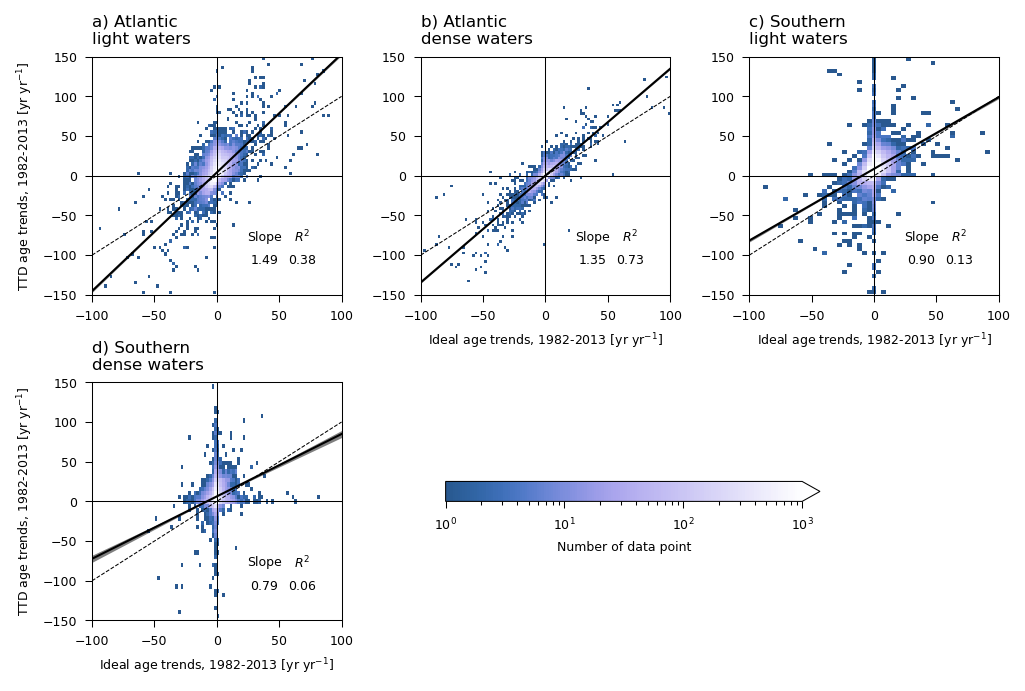

In [61]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('################################')
print('# Analysis in TS space')
print('## Compare ttd-age trends and ideal age trends when computed in TS space')

from fast_histogram import histogram2d

vesm = 'NorESM2-LM'
simu = 'historical'
tperiod = '1982-2013'
wm_list = ['atlantic_light', 'atlantic_dense', 'southern_light', 'southern_dense']

#----------------
# Figure param
#----------------

#____________________
# figname
figname = dirout + f'compare_trends_ttd-age_and_ideal-age_in_ts_space.png'

#______________
# Figure 
fwidth_cm, fheight_cm = 17, 11.3333
nrow, ncol = 2, 3
fsize = (fwidth_cm*cm2in, fheight_cm*cm2in) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, squeeze=False)

#____________________
# labels
region_label_dict = {
    'southern_dense': 'Southern\ndense waters', 
    'southern_light': 'Southern\nlight waters', 
    'atlantic_dense': 'Atlantic\ndense waters', 
    'atlantic_light': 'Atlantic\nlight waters', 
}
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]

#____________________
# Colors and maps
# a = cmcrameri.cm.lajolla
# colors = a(np.linspace(0,1,250))
# region_color_dict = {
#     'southern_dense': colors[50],
#     'southern_light': colors[50*2],
#     'atlantic_dense': colors[50*3],
#     'atlantic_light': colors[50*4]
# } 
region_color_dict = {
    'southern_dense': 'k',
    'southern_light': 'k',
    'atlantic_dense': 'k',
    'atlantic_light': 'k',
} 

#______________
# cmap
a = cmcrameri.cm.devon
colors = a(np.linspace(0,1,200))
newcmap = ListedColormap(colors[50:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[49])
newcmap.set_bad("none")

# a = cm.Wistia
# colors = a(np.linspace(0,1,300))
# newcmap = ListedColormap(colors[30:-1])
# newcmap.set_over(colors[-1])
# newcmap.set_under(colors[29])
# newcmap.set_bad("none")

#____________________
# keywords args
kwpcm = {
    'southern_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern and atlantic': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'total': dict(cmap=ListedColormap(['#D3D3D3']), norm=mpl.colors.LogNorm(vmin=1, vmax=1000))
}


xlim = (-100, 100)
ylim = (-150, 150)


#------------------
# Plot: loop on water masses
#------------------

pcm = np.zeros_like(ax)
for iwm, vwm in enumerate(wm_list): 

    #_________________
    # Load data

    fname = netcdfdir + f'{vesm}_{simu}_mageF12_linregress_on_1982-2013_in_ts_space_{vwm}.nc'
    zwds = xr.open_dataset(fname, **kwopends)
    zwda_slope_mageF12 = zwds['slope']

    fname =  netcdfdir + f'{vesm}_{simu}_agessc_linregress_on_1982-2013_drift_removed_in_ts_space_{vwm}.nc'
    zwds = xr.open_dataset(fname, **kwopends)
    zwda_slope_agessc = zwds['slope']

    #_______________
    # some decoration

    zax = ax.flat[iwm]
    zax.axhline(0, lw=.5, c='k')
    zax.axvline(0, lw=.5, c='k')
    zax.plot(xlim, xlim, ls='--', lw=.5, c='k')
    ttl = alphabet_reverse.pop()+') '+region_label_dict[vwm]
    zax.set_title(ttl, loc='left')
    zax.set_xlim(xlim)
    zax.set_ylim(ylim)

    #_________________
    # Plot histograms 2D

    XXXflat = zwda_slope_agessc.values.flatten()
    YYYflat = zwda_slope_mageF12.values.flatten()
    nbins1 = 200
    bounds = [[np.nanmin(XXXflat),
               np.nanmax(XXXflat)], 
              [np.nanmin(YYYflat), 
               np.nanmax(YYYflat)]]
    ccc = histogram2d(XXXflat, YYYflat, \
                      range=bounds, bins=nbins1).T # need to transpose for visualisation purpose
    xxx = np.linspace(bounds[0][0], bounds[0][1], nbins1)
    yyy = np.linspace(bounds[1][0], bounds[1][1], nbins1)
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm[vwm])
    pcm.flat[iwm] = zwpcm

    #_______________
    # Compute linear regression

    index = ~(np.isnan(XXXflat) | np.isnan(YYYflat))
    XXXflat = XXXflat[index]
    YYYflat = YYYflat[index]
    results = scipy.stats.linregress(XXXflat, YYYflat)

    YYY_predicted = results.intercept + results.slope * XXXflat
    nnn = len(XXXflat)  # Number of observations
    t_value = scipy.stats.t.ppf(1 - 0.025, nnn - 2)  # t-value for 95% confidence interval with n-2 degrees of freedom
    # Standard error of the predicted y-values 
    s_err = np.sqrt(np.sum((YYYflat - YYY_predicted) ** 2) / (nnn - 2))    
    # nb: results.stderr is s_err/np.rmse(X)

    #_______________
    # Compute 95% confidence band

    # Subsampled X and Y predicted to compute 95% confidence band
    combined = list(zip(XXXflat, YYY_predicted))
    if nnn>100: sample_size=100
    else: sample_size=nnn
    # Find the minimum and maximum elements based on the `y` values
    min_combined = min(combined, key=lambda pair: pair[0])
    max_combined = max(combined, key=lambda pair: pair[0])
    # Remove these elements from the combined list to sample the rest
    remaining_combined = [pair for pair in combined if pair != min_combined and pair != max_combined]
    # Sample the remaining elements
    remaining_sample_size = sample_size - 2
    import random
    sampled_remaining = random.sample(remaining_combined, remaining_sample_size)
    # Include the min and max elements in the final sample
    sampled_combined = [min_combined] + sampled_remaining + [max_combined]
    sampled_X, sampled_Y_predicted = zip(*sampled_combined)
    # Convert the sampled tuples back to lists (if needed)
    sampled_X = list(sampled_X)
    sampled_Y_predicted = list(sampled_Y_predicted)
    # Combine `xxx` and `yyy` and sort based on `xxx`
    xxx_yyy = sorted(zip(sampled_X, sampled_Y_predicted))
    # Unzip the sorted pairs
    sorted_xxx, sorted_yyy = zip(*xxx_yyy)
    sampled_X = np.array(sorted_xxx)
    sampled_Y_predicted = np.array(sorted_yyy)

    conf_interval = t_value * s_err * np.sqrt(1 / nnn + (sampled_X - np.mean(XXXflat))**2 / np.sum((XXXflat - np.mean(XXXflat))**2))
    lower_band = sampled_Y_predicted - conf_interval
    upper_band = sampled_Y_predicted + conf_interval

    # pred_interval = t_value * s_err * np.sqrt(1 + 1 / nnn + (sampled_X - np.mean(X))**2 / np.sum((X - np.mean(X))**2))
    # lower_pred_band = sampled_Y_predicted - pred_interval
    # upper_pred_band = sampled_Y_predicted + pred_interval

    #____________________
    # Plot regression line
    lines = []
    tab_col1 = []
    tab_col2 = []

    zax.fill_between(sampled_X, lower_band, upper_band, color=region_color_dict[vwm], alpha=0.5, lw=0)
    ll, = zax.plot(sampled_X, sampled_Y_predicted, label=region_label_dict[vwm], color=region_color_dict[vwm], lw=1)
    lines.append(ll)

    #____________________
    # add notes
    kwtext = dict(ha='center', va='center_baseline', fontsize=6)
    ytxt = .25 #.97
    xtxt1 = .6+.09
    xtxt2 = xtxt1+.15
    # xtxt3 = xtxt2+.15
    zax.text(xtxt1, ytxt, r'Slope', transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, '$R^2$'    , transform=zax.transAxes, color='k', **kwtext)
    ytxt-=.1
    zax.text(xtxt1, ytxt, f'{results.slope:.2f}', transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    zax.text(xtxt2, ytxt, f'{np.floor(results.rvalue**2*100)/100:.2f}', transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    print(f">>> {vesm}, {vwm}: {results.pvalue:.3f}")

#

fig.tight_layout()
        
#--------------------
# Decorate
#--------------------

ax.flat[-2].axis('off')
ax.flat[-1].axis('off')

#____________________
# axis labels
for zax in ax[:, 0]: zax.set_ylabel(f'TTD age trends, {tperiod} '+r'[yr yr$^{-1}$]')
ax[1, 0].set_xlabel(f'Ideal age trends, {tperiod} '+r'[yr yr$^{-1}$]')
ax[0, -1].set_xlabel(f'Ideal age trends, {tperiod} '+r'[yr yr$^{-1}$]')
ax[0, -2].set_xlabel(f'Ideal age trends, {tperiod} '+r'[yr yr$^{-1}$]')

#---------------------
# Colorbar
#---------------------

zw1 = ax.flat[-2].get_position()
nx0 = zw1.x0 + .1*zw1.width
ny0 = zw1.y0 + 0.5*zw1.height
nw  = 1.5*zw1.width
nh  = 0.08*nw
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='horizontal', \
                    ticklocation='bottom', extend='max')
cbar.set_label(r'Number of data point')

#--------------------
# Save figure
#--------------------

print('Save figure...')
fig.savefig(figname, bbox_inches='tight')
print('Figure saved: '+figname)



## Scatter plot ∆AOU vs ∆age and linear regression

### Define function prep_data2plot

In [12]:
%%time
%%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in TS space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Define function prep_data2plot')
print('################################')

from fast_histogram import histogram2d

def prep_data2plot(zaou, zage): 

    print('> prep_data2plot...')
    zdata2plot = {}


    #_________________
    # Compute histograms 2D for entire selected water mass
    print('>> Compute histogram 2D')
    nbins1 = 200
    bounds = [[np.nanmin(zage.values.flatten()),
               np.nanmax(zage.values.flatten())], 
              [np.nanmin(zaou.values.flatten()), 
               np.nanmax(zaou.values.flatten())]]
    hhh = histogram2d(zage.values.flatten(), zaou.values.flatten(), \
                      range=bounds, bins=nbins1).T # need to transpose for visualisation purpose
    xxx = np.linspace(bounds[0][0], bounds[0][1], nbins1)
    yyy = np.linspace(bounds[1][0], bounds[1][1], nbins1)
    zdata2plot['histogram2d'] = {'xxx':xxx, 'yyy':yyy, 'ccc':hhh}

    #_______________
    # compute linear regression
    print('>> Compute linear regression...')
    X = zage.values.flatten()
    Y = zaou.values.flatten()
    index = ~(np.isnan(X) | np.isnan(Y))
    X = X[index]
    Y = Y[index]
    results = scipy.stats.linregress(X, Y)
    
    Y_predicted = results.intercept + results.slope * X
    nnn = len(X)  # Number of observations
    t_value = scipy.stats.t.ppf(1 - 0.025, nnn - 2)  # t-value for 95% confidence interval with n-2 degrees of freedom
    # Standard error of the predicted y-values 
    s_err = np.sqrt(np.sum((Y - Y_predicted) ** 2) / (nnn - 2))    
    # nb: results.stderr is s_err/np.rmse(X)
    
    #_______________
    # Compute 95% confidence band
    
    # Subsampled X and Y predicted to compute 95% confidence band
    combined = list(zip(X, Y_predicted))
    if nnn>100: sample_size=100
    else: sample_size=nnn
    # Find the minimum and maximum elements based on the `y` values
    min_combined = min(combined, key=lambda pair: pair[0])
    max_combined = max(combined, key=lambda pair: pair[0])
    # Remove these elements from the combined list to sample the rest
    remaining_combined = [pair for pair in combined if pair != min_combined and pair != max_combined]
    # Sample the remaining elements
    remaining_sample_size = sample_size - 2
    import random
    sampled_remaining = random.sample(remaining_combined, remaining_sample_size)
    # Include the min and max elements in the final sample
    sampled_combined = [min_combined] + sampled_remaining + [max_combined]
    sampled_X, sampled_Y_predicted = zip(*sampled_combined)
    # Convert the sampled tuples back to lists (if needed)
    sampled_X = list(sampled_X)
    sampled_Y_predicted = list(sampled_Y_predicted)
    # Combine `xxx` and `yyy` and sort based on `xxx`
    xxx_yyy = sorted(zip(sampled_X, sampled_Y_predicted))
    # Unzip the sorted pairs
    sorted_xxx, sorted_yyy = zip(*xxx_yyy)
    sampled_X = np.array(sorted_xxx)
    sampled_Y_predicted = np.array(sorted_yyy)

    conf_interval = t_value * s_err * np.sqrt(1 / nnn + (sampled_X - np.mean(X))**2 / np.sum((X - np.mean(X))**2))
    lower_band = sampled_Y_predicted - conf_interval
    upper_band = sampled_Y_predicted + conf_interval

    pred_interval = t_value * s_err * np.sqrt(1 + 1 / nnn + (sampled_X - np.mean(X))**2 / np.sum((X - np.mean(X))**2))
    lower_pred_band = sampled_Y_predicted - pred_interval
    upper_pred_band = sampled_Y_predicted + pred_interval
    
    del X, Y
    gc.collect()
    
    #_______________
    # Save linregress analysis
    zdata2plot['linregress'] = {}
    zdata2plot['linregress']['slope'] = results.slope
    zdata2plot['linregress']['intercept'] = results.intercept
    zdata2plot['linregress']['rvalue'] = results.rvalue
    zdata2plot['linregress']['pvalue'] = results.pvalue
    zdata2plot['linregress']['stderr'] = results.stderr 
    zdata2plot['linregress']['intercept_stderr'] = results.intercept_stderr
    zdata2plot['linregress']['number of observation'] = nnn
    zdata2plot['linregress']['tvalue'] = t_value
    zdata2plot['linregress']['sampled_X'] = sampled_X
    zdata2plot['linregress']['sampled_Y_predicted'] = sampled_Y_predicted
    zdata2plot['linregress']['lower_band'] = lower_band
    zdata2plot['linregress']['upper_band'] = upper_band
    zdata2plot['linregress']['conf_interval'] = conf_interval
    zdata2plot['linregress']['stderr_pred'] = s_err
    zdata2plot['linregress']['lower_pred_band'] = lower_pred_band
    zdata2plot['linregress']['upper_pred_band'] = upper_pred_band
    zdata2plot['linregress']['conf_interval'] = pred_interval
    
    return zdata2plot
#
#----------------
# End define prep_data2plot
#----------------

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

2025-11-27 16:11:21.720573
# Scatter plot ∆AOU vs ∆age and linear regression
## Define function prep_data2plot
peak memory: 13194.75 MiB, increment: 6544.51 MiB
CPU times: user 93.6 ms, sys: 28.8 ms, total: 122 ms
Wall time: 268 ms


### Prepare data2plot for ttdage

In [13]:
%%time
%%memit -c
# ca. 17min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in TS space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Prepare data2plot for ttdage')
print('################################')

vesm = 'NorESM2-LM'
simu = 'historical'
tperiod = '1982-2013'
wm_list = ['atlantic_light', 'atlantic_dense', 'southern_light', 'southern_dense']

zfact_esm_aou = 1000. # mol.m-3 to mmol.m-3 = umol.l-1

data2plot = {}

#----------------
# Loop on water masses
#----------------

for iwm, vwm in enumerate(wm_list): 
    
    print(f'For {vwm}...')

    #_________________
    # Get data
    
    print('    Get aou data...')    
    vvar = 'aou'
    fname = netcdfdir+f'{vesm}_{simu}_{vvar}_linregress_on_{tperiod}_drift_removed_in_ts_space_{vwm}_fitting_ttdage_finite_values.nc'
    zwds = xr.open_dataset(fname, **kwopends)
    zwda_aou = zwds['slope']*zfact_esm_aou 
    zwda_aou_pval = zwds['pvalue']

    print('    Get age data...')    
    vvar = 'mageF12'
    fname = netcdfdir+f'{vesm}_{simu}_{vvar}_linregress_on_{tperiod}_in_ts_space_{vwm}.nc'
    zwds = xr.open_dataset(fname, **kwopends)
    zwda_age = zwds['slope']
    zwda_age_pval = zwds['pvalue']

    #_________________
    # Get only significant trends
    COND_signif = (zwda_aou_pval<=.05) & (zwda_age_pval<=.05)
    
    zwda_aou = zwda_aou.where(COND_signif, np.nan)
    zwda_age = zwda_age.where(COND_signif, np.nan)

    data2plot[vwm] = prep_data2plot(zwda_aou, zwda_age) 

#

#_________________
# Save
print('Save file...')
savefile = dirout + 'data2plot_aou_trend_vs_ttdage_trend_in_ts_space_'+simu+'_'+tperiod+'.pckl'
with open(savefile, "wb") as file:
    pickle.dump(data2plot, file)
#
print('File saved: '+savefile)

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-11-27 16:11:22.728194
# Scatter plot ∆AOU vs ∆age and linear regression
## Prepare data2plot for ttdage
################################
For atlantic_light...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
For atlantic_dense...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
For southern_light...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
For southern_dense...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
Save file...
File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/data2plot_aou_trend_vs_ttdage_trend_in_ts_space_historical_1982-2013.pckl
################################
Done:  2025-11-27 16:11:24.000980
##########################

### Plot: scatter plot for ttdage

2025-11-27 16:11:34.896671
# Scatter plot ∆AOU vs ∆age and linear regression
## Plot: scatter plot for ideal age
>>> NorESM2-LM, atlantic_light: 0.000
>>> NorESM2-LM, atlantic_dense: 0.000
>>> NorESM2-LM, southern_light: 0.000
>>> NorESM2-LM, southern_dense: 0.000
Save figure...
Figure saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/scatter_plot_aou_trend_vs_ttdage_trend_in_ts_space_historical_1982-2013.png
CPU times: user 1.14 s, sys: 1.38 s, total: 2.52 s
Wall time: 1.05 s


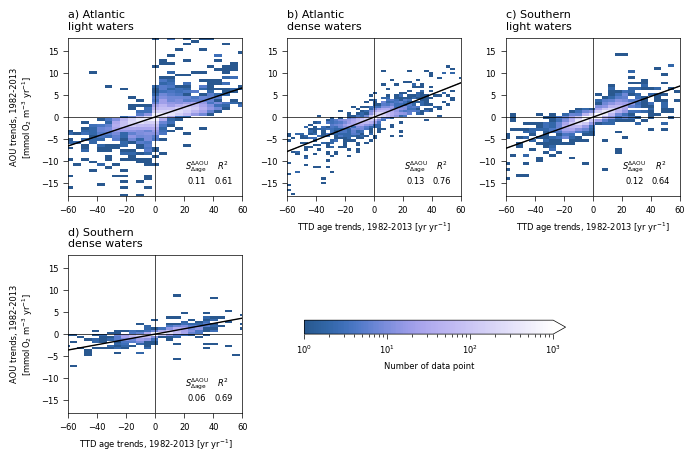

In [14]:
%%time
# %%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in TS space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Plot: scatter plot for ideal age')
print('################################')

#____________________
# Load data2plot

simu = 'historical'
tperiod = '1982-2013'
savefile = dirout + 'data2plot_aou_trend_vs_ttdage_trend_in_ts_space_'+simu+'_'+tperiod+'.pckl'
# Open the pickle file in binary read mode
with open(savefile, 'rb') as file:
    # Load the dictionary from the pickle file
    data2plot = pickle.load(file)
#

#--------------------
# Figure parameters
#--------------------

#____________________
# figname
figname = savefile.replace('data2plot', 'scatter_plot').replace('.pckl', '.png')

#____________________
# list
wm_list = ['atlantic_light', 'atlantic_dense', 'southern_light', 'southern_dense']

#____________________
# Figure
fwidth_cm, fheight_cm = 17, 11.3333
nrow, ncol = 2, 3
fsize = (fwidth_cm*cm2in, fheight_cm*cm2in) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, squeeze=False)

#____________________
# labels
region_label_dict = {
    'southern_dense': 'Southern\ndense waters', 
    'southern_light': 'Southern\nlight waters', 
    'atlantic_dense': 'Atlantic\ndense waters', 
    'atlantic_light': 'Atlantic\nlight waters', 
}
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]


#____________________
# Colors and maps
# a = cmcrameri.cm.lajolla
# colors = a(np.linspace(0,1,250))
# region_color_dict = {
#     'southern_dense': colors[50],
#     'southern_light': colors[50*2],
#     'atlantic_dense': colors[50*3],
#     'atlantic_light': colors[50*4]
# } 

region_color_dict = {
    'southern_dense': 'k',
    'southern_light': 'k',
    'atlantic_dense': 'k',
    'atlantic_light': 'k',
} 


#______________
# cmap
a = cmcrameri.cm.devon
colors = a(np.linspace(0,1,200))
newcmap = ListedColormap(colors[50:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[49])
newcmap.set_bad("none")

# a = cm.Wistia
# colors = a(np.linspace(0,1,300))
# newcmap = ListedColormap(colors[30:-1])
# newcmap.set_over(colors[-1])
# newcmap.set_under(colors[29])
# newcmap.set_bad("none")

#____________________
# keywords args
kwpcm = {
    'southern_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern and atlantic': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'total': dict(cmap=ListedColormap(['#D3D3D3']), norm=mpl.colors.LogNorm(vmin=1, vmax=1000))
}


xlim = (-60, 60)
ylim = ( -18,  18)

#--------------------
# Plot
#--------------------

pcm = np.zeros_like(ax)
for iwm, vwm in enumerate(wm_list): 
    
    zax = ax.flat[iwm]
    zax.axhline(0, lw=.5, c='k')
    zax.axvline(0, lw=.5, c='k')
    ttl = alphabet_reverse.pop()+') '+region_label_dict[vwm]
    zax.set_title(ttl, loc='left')
    zax.set_xlim(xlim)
    zax.set_ylim(ylim)

    #____________________
    # Selected scatter plot

    xxx = data2plot[vwm]['histogram2d']['xxx']
    yyy = data2plot[vwm]['histogram2d']['yyy']
    ccc = data2plot[vwm]['histogram2d']['ccc']
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm[vwm])
    pcm.flat[iwm] = zwpcm

    #____________________
    # Add regression line
    lines = []
    tab_col1 = []
    tab_col2 = []

    xxx = data2plot[vwm]['linregress']['sampled_X']
    yyy = data2plot[vwm]['linregress']['sampled_Y_predicted']
    yyymin = data2plot[vwm]['linregress']['lower_band']
    yyymax = data2plot[vwm]['linregress']['upper_band']

    zax.fill_between(xxx, yyymin, yyymax, color=region_color_dict[vwm], alpha=0.5, lw=0)
    ll, = zax.plot(xxx, yyy, label=region_label_dict[vwm], color=region_color_dict[vwm], lw=1)
    lines.append(ll)
                
    #____________________
    # Save some notes for table
    slope = data2plot[vwm]['linregress']['slope']
    rvalue = data2plot[vwm]['linregress']['rvalue']
    tab_col2.append(f'{np.floor(rvalue**2*100)/100:.2f}')
    tab_col1.append(f'{slope:.2f}')
    print(f">>> {vesm}, {vwm}: {data2plot[vwm]['linregress']['pvalue']:.3f}")
        
    #____________________
    # add notes
    kwtext = dict(ha='center', va='center_baseline', fontsize=6)
    ytxt = .2 #.97
    xtxt1 = .65+.09
    xtxt2 = xtxt1+.15
    # xtxt3 = xtxt2+.15
    zax.text(xtxt1, ytxt, r'$S_{\mathrm{\Delta age}}^{\mathrm{\Delta AOU}}$', transform=zax.transAxes, color='k', **kwtext)
    # zax.text(xtxt1, ytxt, r'Slope', transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, '$R^2$'    , transform=zax.transAxes, color='k', **kwtext)
    # zax.text(xtxt3, ytxt, 'Ocean\nfraction', transform=zax.transAxes, color='k', **kwtext)
    ytxt-=.1
    zax.text(xtxt1, ytxt, tab_col1[0], transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    zax.text(xtxt2, ytxt, tab_col2[0], transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    # zax.text(xtxt1, ytxt, tab_row3[0], transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    
#

fig.tight_layout()
        
#--------------------
# Decorate
#--------------------

ax.flat[-2].axis('off')
ax.flat[-1].axis('off')

#____________________
# legend
# handles = [plt.Line2D([0], [0], marker='None', linestyle='-', label=region_label_dict[region], color=region_color_dict[region], lw=2) for region in wm_list]
# zax = ax.flat[-1]
# zax.legend(handles=handles, handlelength=0.5, frameon=False, handletextpad=1, loc='upper right', bbox_to_anchor=(1, 1))

#____________________
# axis labels
xlab = f'TTD age trends, {tperiod} '+r'[yr yr$^{-1}$]'
ylab = f'AOU trends, {tperiod}\n'+r'[mmol$\,$O$_2$ m$^{-3}$ yr$^{-1}$]'
for zax in ax[: , 0]: zax.set_ylabel(ylab)
ax[1,  0].set_xlabel(xlab)
ax[0, -1].set_xlabel(xlab)
ax[0, -2].set_xlabel(xlab)


#---------------------
# Colorbar
#---------------------

# zw1 = ax.flat[-2].get_position()
# nx0 = zw1.x1 + .2*zw1.width
# ny0 = zw1.y0
# nh  = zw1.height
# nw  = 0.03*nh
# cax = fig.add_axes([nx0, ny0, nw, nh])
# cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='vertical', \
#                     ticklocation='right', extend='max')
# cbar.set_label(r'Number of data point')

zw1 = ax.flat[-2].get_position()
nx0 = zw1.x0 + .1*zw1.width
ny0 = zw1.y0 + 0.5*zw1.height
nw  = 1.5*zw1.width
nh  = 0.08*nw
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='horizontal', \
                    ticklocation='bottom', extend='max')
cbar.set_label(r'Number of data point')

#--------------------
# Save figure
#--------------------

print('Save figure...')
fig.savefig(figname, bbox_inches='tight')
print('Figure saved: '+figname)


print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

### Prepare data2plot for ideal age

In [19]:
%%time
%%memit -c
# ca. 17min
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in TS space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Prepare data2plot for ideal age')
print('################################')

vesm = 'NorESM2-LM'
simu = 'historical'
tperiod = '1982-2013'
wm_list = ['atlantic_light', 'atlantic_dense', 'southern_light', 'southern_dense']

zfact_esm_aou = 1000. # mol.m-3 to mmol.m-3 = umol.l-1

data2plot = {}

#----------------
# Loop on water masses
#----------------

for iwm, vwm in enumerate(wm_list): 
    
    print(f'For {vwm}...')

    #_________________
    # Get data
    
    print('    Get aou data...')    
    vvar = 'aou'
    fname = netcdfdir+f'{vesm}_{simu}_{vvar}_linregress_on_{tperiod}_drift_removed_in_ts_space_{vwm}.nc'
    zwds = xr.open_dataset(fname, **kwopends)
    zwda_aou = zwds['slope']*zfact_esm_aou 
    zwda_aou_pval = zwds['pvalue']

    print('    Get age data...')    
    vvar = 'agessc'
    fname = netcdfdir+f'{vesm}_{simu}_{vvar}_linregress_on_{tperiod}_drift_removed_in_ts_space_{vwm}.nc'
    zwds = xr.open_dataset(fname, **kwopends)
    zwda_age = zwds['slope']
    zwda_age_pval = zwds['pvalue']

    #_________________
    # Get only significant trends
    COND_signif = (zwda_aou_pval<=.05) & (zwda_age_pval<=.05)
    
    zwda_aou = zwda_aou.where(COND_signif, np.nan)
    zwda_age = zwda_age.where(COND_signif, np.nan)

    data2plot[vwm] = prep_data2plot(zwda_aou, zwda_age) 

#

#_________________
# Save
print('Save file...')
savefile = dirout + 'data2plot_aou_trend_vs_idealage_trend_in_ts_space_'+simu+'_'+tperiod+'.pckl'
with open(savefile, "wb") as file:
    pickle.dump(data2plot, file)
#
print('File saved: '+savefile)

print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')

################################
################################
2025-11-26 11:16:35.363484
# Scatter plot ∆AOU vs ∆age and linear regression
## Prepare data2plot for ideal age
################################
For atlantic_light...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
For atlantic_dense...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
For southern_light...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
For southern_dense...
    Get aou data...
    Get age data...
> prep_data2plot...
>> Compute histogram 2D
>> Compute linear regression...
Save file...
File saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/data2plot_aou_trend_vs_idealage_trend_in_ts_space_historical_1982-2013.pckl
################################
Done:  2025-11-26 11:16:36.578142
#####################

### Plot: scatter plot for ideal age

2025-11-26 11:20:39.019923
# Scatter plot ∆AOU vs ∆age and linear regression
## Plot: scatter plot for ideal age
>>> NorESM2-LM, atlantic_light: 0.000
>>> NorESM2-LM, atlantic_dense: 0.000
>>> NorESM2-LM, southern_light: 0.000
>>> NorESM2-LM, southern_dense: 0.000
Save figure...
Figure saved: 25-11-12-compute-trends-with-TTD-age-noresm2-lm/scatter_plot_aou_trend_vs_idealage_trend_in_ts_space_historical_1982-2013.png
CPU times: user 849 ms, sys: 503 ms, total: 1.35 s
Wall time: 784 ms


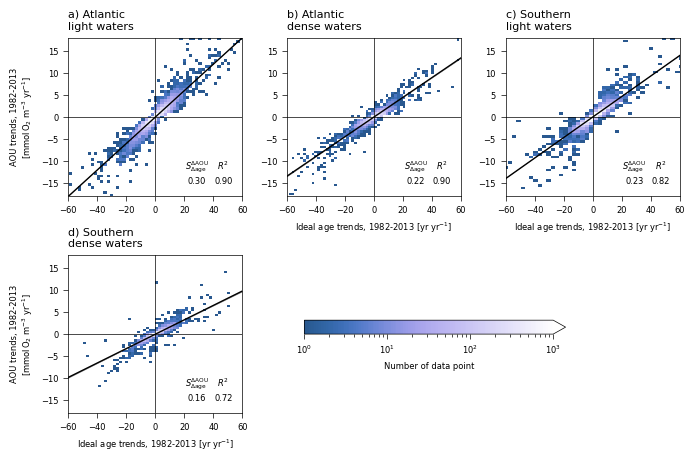

In [25]:
%%time
# %%memit -c
print('################################')
print('################################')
print(datetime.datetime.now())
print('# Analysis in TS space')
print('## Scatter plot ∆AOU vs ∆age and linear regression')
print('### Plot: scatter plot for ideal age')
print('################################')

#____________________
# Load data2plot

simu = 'historical'
tperiod = '1982-2013'
savefile = dirout + 'data2plot_aou_trend_vs_idealage_trend_in_ts_space_'+simu+'_'+tperiod+'.pckl'
# Open the pickle file in binary read mode
with open(savefile, 'rb') as file:
    # Load the dictionary from the pickle file
    data2plot = pickle.load(file)
#

#--------------------
# Figure parameters
#--------------------

#____________________
# figname
figname = savefile.replace('data2plot', 'scatter_plot').replace('.pckl', '.png')

#____________________
# list
wm_list = ['atlantic_light', 'atlantic_dense', 'southern_light', 'southern_dense']

#____________________
# Figure
fwidth_cm, fheight_cm = 17, 11.3333
nrow, ncol = 2, 3
fsize = (fwidth_cm*cm2in, fheight_cm*cm2in) # width, height
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=fsize, squeeze=False)

#____________________
# labels
region_label_dict = {
    'southern_dense': 'Southern\ndense waters', 
    'southern_light': 'Southern\nlight waters', 
    'atlantic_dense': 'Atlantic\ndense waters', 
    'atlantic_light': 'Atlantic\nlight waters', 
}
import string
alphabet = list(string.ascii_lowercase)
alphabet_reverse = alphabet[::-1]


#____________________
# Colors and maps
# a = cmcrameri.cm.lajolla
# colors = a(np.linspace(0,1,250))
# region_color_dict = {
#     'southern_dense': colors[50],
#     'southern_light': colors[50*2],
#     'atlantic_dense': colors[50*3],
#     'atlantic_light': colors[50*4]
# } 

region_color_dict = {
    'southern_dense': 'k',
    'southern_light': 'k',
    'atlantic_dense': 'k',
    'atlantic_light': 'k',
} 


#______________
# cmap
a = cmcrameri.cm.devon
colors = a(np.linspace(0,1,200))
newcmap = ListedColormap(colors[50:-1])
newcmap.set_over(colors[-1])
newcmap.set_under(colors[49])
newcmap.set_bad("none")

# a = cm.Wistia
# colors = a(np.linspace(0,1,300))
# newcmap = ListedColormap(colors[30:-1])
# newcmap.set_over(colors[-1])
# newcmap.set_under(colors[29])
# newcmap.set_bad("none")

#____________________
# keywords args
kwpcm = {
    'southern_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_dense': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'atlantic_light': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'southern and atlantic': dict(cmap = newcmap, norm=mpl.colors.LogNorm(vmin=1, vmax=1000)), 
    'total': dict(cmap=ListedColormap(['#D3D3D3']), norm=mpl.colors.LogNorm(vmin=1, vmax=1000))
}


xlim = (-60, 60)
ylim = ( -18,  18)

#--------------------
# Plot
#--------------------

pcm = np.zeros_like(ax)
for iwm, vwm in enumerate(wm_list): 
    
    zax = ax.flat[iwm]
    zax.axhline(0, lw=.5, c='k')
    zax.axvline(0, lw=.5, c='k')
    ttl = alphabet_reverse.pop()+') '+region_label_dict[vwm]
    zax.set_title(ttl, loc='left')
    zax.set_xlim(xlim)
    zax.set_ylim(ylim)

    #____________________
    # Selected scatter plot

    xxx = data2plot[vwm]['histogram2d']['xxx']
    yyy = data2plot[vwm]['histogram2d']['yyy']
    ccc = data2plot[vwm]['histogram2d']['ccc']
    zwpcm = zax.pcolormesh(xxx, yyy, ccc, **kwpcm[vwm])
    pcm.flat[iwm] = zwpcm

    #____________________
    # Add regression line
    lines = []
    tab_col1 = []
    tab_col2 = []

    xxx = data2plot[vwm]['linregress']['sampled_X']
    yyy = data2plot[vwm]['linregress']['sampled_Y_predicted']
    yyymin = data2plot[vwm]['linregress']['lower_band']
    yyymax = data2plot[vwm]['linregress']['upper_band']

    zax.fill_between(xxx, yyymin, yyymax, color=region_color_dict[vwm], alpha=0.5, lw=0)
    ll, = zax.plot(xxx, yyy, label=region_label_dict[vwm], color=region_color_dict[vwm], lw=1)
    lines.append(ll)
                
    #____________________
    # Save some notes for table
    slope = data2plot[vwm]['linregress']['slope']
    rvalue = data2plot[vwm]['linregress']['rvalue']
    tab_col2.append(f'{np.floor(rvalue**2*100)/100:.2f}')
    tab_col1.append(f'{slope:.2f}')
    print(f">>> {vesm}, {vwm}: {data2plot[vwm]['linregress']['pvalue']:.3f}")
        
    #____________________
    # add notes
    kwtext = dict(ha='center', va='center_baseline', fontsize=6)
    ytxt = .2 #.97
    xtxt1 = .65+.09
    xtxt2 = xtxt1+.15
    # xtxt3 = xtxt2+.15
    zax.text(xtxt1, ytxt, r'$S_{\mathrm{\Delta age}}^{\mathrm{\Delta AOU}}$', transform=zax.transAxes, color='k', **kwtext)
    # zax.text(xtxt1, ytxt, r'Slope', transform=zax.transAxes, color='k', **kwtext)
    zax.text(xtxt2, ytxt, '$R^2$'    , transform=zax.transAxes, color='k', **kwtext)
    # zax.text(xtxt3, ytxt, 'Ocean\nfraction', transform=zax.transAxes, color='k', **kwtext)
    ytxt-=.1
    zax.text(xtxt1, ytxt, tab_col1[0], transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    zax.text(xtxt2, ytxt, tab_col2[0], transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    # zax.text(xtxt1, ytxt, tab_row3[0], transform=zax.transAxes, color=region_color_dict[vwm], **kwtext)
    
#

fig.tight_layout()
        
#--------------------
# Decorate
#--------------------

ax.flat[-2].axis('off')
ax.flat[-1].axis('off')

#____________________
# legend
# handles = [plt.Line2D([0], [0], marker='None', linestyle='-', label=region_label_dict[region], color=region_color_dict[region], lw=2) for region in wm_list]
# zax = ax.flat[-1]
# zax.legend(handles=handles, handlelength=0.5, frameon=False, handletextpad=1, loc='upper right', bbox_to_anchor=(1, 1))

#____________________
# axis labels
xlab = f'Ideal age trends, {tperiod} '+r'[yr yr$^{-1}$]'
ylab = f'AOU trends, {tperiod}\n'+r'[mmol$\,$O$_2$ m$^{-3}$ yr$^{-1}$]'
for zax in ax[: , 0]: zax.set_ylabel(ylab)
ax[1,  0].set_xlabel(xlab)
ax[0, -1].set_xlabel(xlab)
ax[0, -2].set_xlabel(xlab)


#---------------------
# Colorbar
#---------------------

# zw1 = ax.flat[-2].get_position()
# nx0 = zw1.x1 + .2*zw1.width
# ny0 = zw1.y0
# nh  = zw1.height
# nw  = 0.03*nh
# cax = fig.add_axes([nx0, ny0, nw, nh])
# cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='vertical', \
#                     ticklocation='right', extend='max')
# cbar.set_label(r'Number of data point')

zw1 = ax.flat[-2].get_position()
nx0 = zw1.x0 + .1*zw1.width
ny0 = zw1.y0 + 0.5*zw1.height
nw  = 1.5*zw1.width
nh  = 0.08*nw
cax = fig.add_axes([nx0, ny0, nw, nh])
cbar = fig.colorbar(pcm.flat[0], cax=cax, orientation='horizontal', \
                    ticklocation='bottom', extend='max')
cbar.set_label(r'Number of data point')

#--------------------
# Save figure
#--------------------

print('Save figure...')
fig.savefig(figname, bbox_inches='tight')
print('Figure saved: '+figname)


print('################################')
print('Done: ', datetime.datetime.now())
print('################################')
print('################################')